# **Quality Control**

## Setup and Data Loading

In [1]:
print("Let's go!")

Let's go!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import warnings
import re

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# File paths - update these to point to full data files
CLINICAL_PATH = '../data/brca_tcga_clinical_data.csv'
RSEM_PATH = '../data/tcga.brca.rsem.csv'
CN_PATH = '../data/brca_tcga_erbb2_copy_number.csv'


In [3]:
print("Loading datasets...")
clinical = pd.read_csv(CLINICAL_PATH)
rsem = pd.read_csv(RSEM_PATH)
cn = pd.read_csv(CN_PATH)

print(f"Clinical: {clinical.shape[0]} patients × {clinical.shape[1]} columns")
print(f"RNA-Seq:  {rsem.shape[0]} samples × {rsem.shape[1]} columns (including metadata)")
print(f"Copy Number: {cn.shape[0]} samples × {cn.shape[1]} columns")


Loading datasets...
Clinical: 1108 patients × 140 columns
RNA-Seq:  1212 samples × 20505 columns (including metadata)
Copy Number: 963 samples × 3 columns


---
# Part 1: Clinical Data QC

### 1.1 Motivation: Why Clinical QC Comes First

Clinical metadata serves two roles:
1. **Ground-truth labels** — IHC-HER2 status is the supervised learning target.
2. **QC annotations for RNA-Seq** — ER status, tumor subtype, diagnosis year are needed to interpret PCA and detect batch effects.

If clinical labels are inconsistent or biased by temporal shifts in diagnostic criteria, every downstream analysis inherits that error.


### 1.2 Encoding Harmonization

TCGA clinical data contains inconsistent encodings — mixed capitalization, trailing whitespace, 
and multiple representations of missing data (`[Not Available]`, `[Not Evaluated]`, `[Not Applicable]`, 
empty string, NaN). We harmonize these first so all subsequent analyses operate on clean data.


In [4]:
# Define TCGA sentinel missing values
TCGA_MISSING = [
    '[Not Available]', '[Not Evaluated]', '[Not Applicable]',
    '[Unknown]', '[Discrepancy]', '[Completed]', '[Not Assessed]',
    '', ' '
]

def harmonize_clinical(df):
    """Harmonize TCGA clinical data encodings."""
    df = df.copy()
    
    # Strip whitespace from all string columns
    str_cols = df.select_dtypes(include='object').columns
    for col in str_cols:
        df[col] = df[col].astype(str).str.strip()
    
    # Map sentinel missing values to NaN
    for col in str_cols:
        df[col] = df[col].replace(TCGA_MISSING, np.nan)
        df[col] = df[col].replace('nan', np.nan)
    
    # Standardize key categorical fields to title case
    categorical_fields = ['IHC-HER2', 'HER2 fish status', 'ER Status By IHC', 'PR status by ihc']
    for col in categorical_fields:
        if col in df.columns:
            df[col] = df[col].str.strip().str.title()
            df[col] = df[col].replace('Nan', np.nan)
    
    return df

clinical = harmonize_clinical(clinical)
print("Encoding harmonization complete.")
print(f"\nTotal patients: {len(clinical)}")
print(f"Total columns: {len(clinical.columns)}")


Encoding harmonization complete.

Total patients: 1108
Total columns: 140


#### **Manual review (brief, exploratory)**

In [5]:
for col in clinical.columns:
    print(col,  len(clinical[col].unique()) )
    print("\n", clinical[col].unique())
    print("=" * 70)

Study ID 1

 <StringArray>
['brca_tcga']
Length: 1, dtype: str
Patient ID 1101

 <StringArray>
['TCGA-3C-AAAU', 'TCGA-3C-AALI', 'TCGA-3C-AALJ', 'TCGA-3C-AALK',
 'TCGA-4H-AAAK', 'TCGA-5L-AAT0', 'TCGA-5L-AAT1', 'TCGA-5T-A9QA',
 'TCGA-A1-A0SB', 'TCGA-A1-A0SD',
 ...
 'TCGA-UL-AAZ6', 'TCGA-UU-A93S', 'TCGA-V7-A7HQ', 'TCGA-W8-A86G',
 'TCGA-WT-AB41', 'TCGA-WT-AB44', 'TCGA-XX-A899', 'TCGA-XX-A89A',
 'TCGA-Z7-A8R5', 'TCGA-Z7-A8R6']
Length: 1101, dtype: str
Sample ID 1108

 <StringArray>
['TCGA-3C-AAAU-01', 'TCGA-3C-AALI-01', 'TCGA-3C-AALJ-01', 'TCGA-3C-AALK-01',
 'TCGA-4H-AAAK-01', 'TCGA-5L-AAT0-01', 'TCGA-5L-AAT1-01', 'TCGA-5T-A9QA-01',
 'TCGA-A1-A0SB-01', 'TCGA-A1-A0SD-01',
 ...
 'TCGA-UL-AAZ6-01', 'TCGA-UU-A93S-01', 'TCGA-V7-A7HQ-01', 'TCGA-W8-A86G-01',
 'TCGA-WT-AB41-01', 'TCGA-WT-AB44-01', 'TCGA-XX-A899-01', 'TCGA-XX-A89A-01',
 'TCGA-Z7-A8R5-01', 'TCGA-Z7-A8R6-01']
Length: 1108, dtype: str
Diagnosis Age 66

 [55. 50. 62. 52. 42. 63. 70. 59. 56. 54. 61. 39. 77. 67. 40. 45. 66. 36.
 48. 47. 3

In [6]:
print("Noting that this column contains string values: ", "Cent17 Copy Number")
print("Noting that this column is quite heterogenous: ", "ER positivity scale other")
print( clinical["ER positivity scale other"].unique() )
print("Noting that this column is quite heterogenous: ", "First surgical procedure other")
print( clinical["First surgical procedure other"].unique() )
print("Noting that this column is quite heterogenous: ", "HER2 positivity method text")
print( clinical["HER2 positivity method text"].unique() )
print("Noting that this column is quite heterogenous: ", "Tumor Other Histologic Subtype")
print( clinical["Tumor Other Histologic Subtype"].unique() )
print("There is a lot of missing or heterogenous values in many columns. Should consider an agentic approach. ")

Noting that this column contains string values:  Cent17 Copy Number
Noting that this column is quite heterogenous:  ER positivity scale other
<StringArray>
[                                                 nan,
                                             'STRONG',
                                             'Strong',
                                     'Intensity=Weak',
                                 'Intensity=moderate',
                                   'Intensity=Strong',
             'Strong using Weak, Moderate and Strong',
 'Moderate using the scale of Weak, Moderate, Strong',
     'Moderate using scale of Weak, Moderate, Strong',
                                                '200',
                                                '210',
                                                '170',
                                                '205',
                                                 '80',
                                                '112',
                   

In [7]:
# exporting an exemplary columns for developing agentic workflow to harmonize entries.  
example_messy_cols = ["ER positivity scale other", "First surgical procedure other",
                              "HER2 positivity method text", "Tumor Other Histologic Subtype" ]
clinical.loc[:, example_messy_cols].to_csv("../output/example_messy_data_260402.csv")

### 1.3 Missingness Audit

For every column we plan to use downstream, we compute the fraction of missing values. We distinguish 
between truly empty fields and explicit sentinel strings (already mapped to NaN above).

We specifically look for **structured missingness** — if HER2 annotations are missing preferentially 
for samples from certain years or centers, our labeled training set is biased.


In [8]:
# Key fields for downstream analysis
key_fields = {
    'HER2-related': ['IHC-HER2', 'HER2 ihc score', 'HER2 fish status', 
                     'HER2 cent17 ratio', 'HER2 copy number'],
    'Hormone receptors': ['ER Status By IHC', 'PR status by ihc'],
    'Staging': ['Neoplasm Disease Stage American Joint Committee on Cancer Code',
                'American Joint Committee on Cancer Tumor Stage Code',
                'American Joint Committee on Cancer Metastasis Stage Code'],
    'Demographics': ['Diagnosis Age', 'Race Category', 'Ethnicity Category'],
    'Temporal': ['Year Cancer Initial Diagnosis', 'Form completion date']
}

print("=" * 70)
print("MISSINGNESS AUDIT: Key Fields")
print("=" * 70)

missingness_data = []
for category, fields in key_fields.items():
    print(f"\n--- {category} ---")
    for field in fields:
        if field in clinical.columns:
            n_missing = clinical[field].isna().sum()
            pct_missing = 100 * n_missing / len(clinical)
            n_present = len(clinical) - n_missing
            print(f"  {field:45s}: {n_present:4d} present, {n_missing:4d} missing ({pct_missing:5.1f}%)")
            missingness_data.append({
                'category': category, 'field': field,
                'n_present': n_present, 'n_missing': n_missing,
                'pct_missing': pct_missing
            })
        else:
            print(f"  {field:45s}: *** COLUMN NOT FOUND ***")

missingness_df = pd.DataFrame(missingness_data)


MISSINGNESS AUDIT: Key Fields

--- HER2-related ---
  IHC-HER2                                     :  923 present,  185 missing ( 16.7%)
  HER2 ihc score                               :  624 present,  484 missing ( 43.7%)
  HER2 fish status                             :  422 present,  686 missing ( 61.9%)
  HER2 cent17 ratio                            :  234 present,  874 missing ( 78.9%)
  HER2 copy number                             :  114 present,  994 missing ( 89.7%)

--- Hormone receptors ---
  ER Status By IHC                             : 1055 present,   53 missing (  4.8%)
  PR status by ihc                             : 1054 present,   54 missing (  4.9%)

--- Staging ---
  Neoplasm Disease Stage American Joint Committee on Cancer Code: 1093 present,   15 missing (  1.4%)
  American Joint Committee on Cancer Tumor Stage Code: 1104 present,    4 missing (  0.4%)
  American Joint Committee on Cancer Metastasis Stage Code: 1104 present,    4 missing (  0.4%)

--- Demographics --

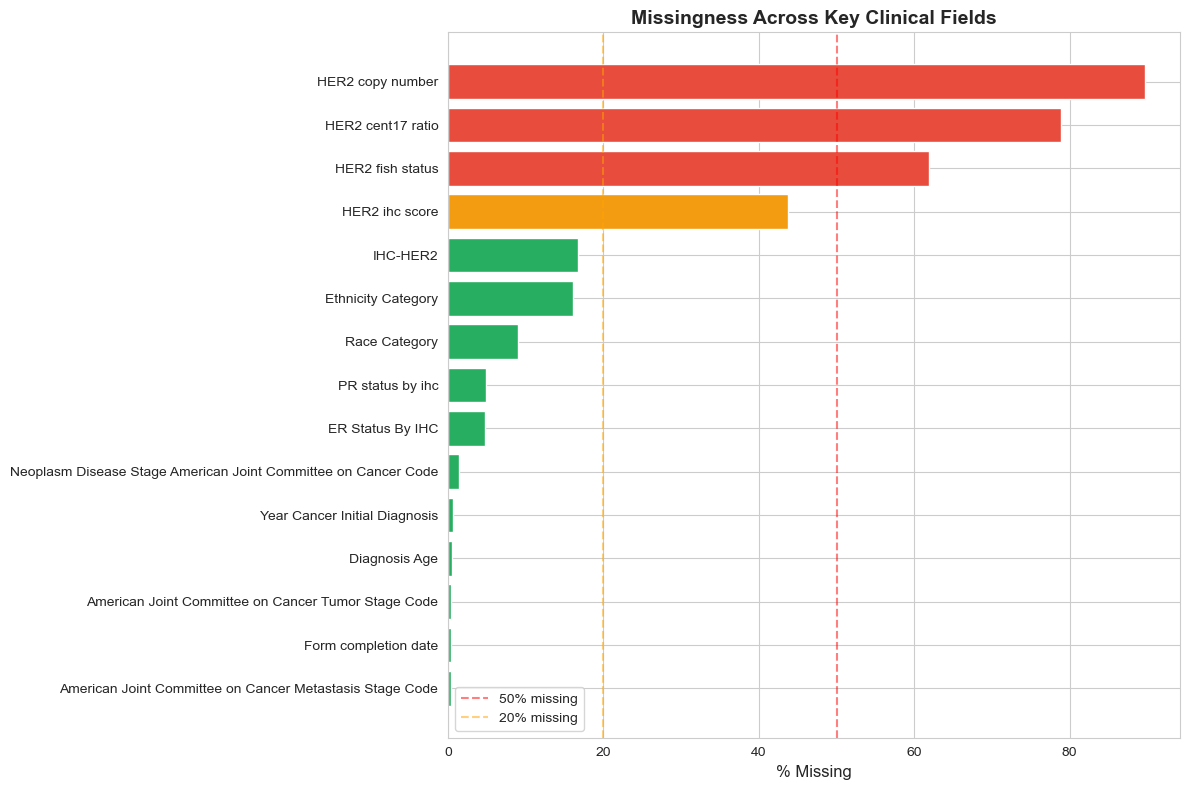


Green: <20% missing | Orange: 20-50% missing | Red: >50% missing


In [9]:
# Visualize missingness for key fields
fig, ax = plt.subplots(figsize=(12, 8))
miss_plot = missingness_df.sort_values('pct_missing', ascending=True)
colors = miss_plot['pct_missing'].apply(
    lambda x: '#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#27ae60'
)
ax.barh(miss_plot['field'], miss_plot['pct_missing'], color=colors, edgecolor='white')
ax.set_xlabel('% Missing', fontsize=12)
ax.set_title('Missingness Across Key Clinical Fields', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% missing')
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.5, label='20% missing')
ax.legend()
plt.tight_layout()
plt.show()
print("\nGreen: <20% missing | Orange: 20-50% missing | Red: >50% missing")



**Note**: Missingness is structured, mirroring HER2-based diagnosis workflow. Most have *IHC-HER2* data (the missingness here is likely driven by change in standard of care and diagnostics practice, which will be assessed specifically below) since IHC procedure comes first. Based on results, *FISH* procedure follows, with *cent17 ratio* and *HER2 copy number* are components of the FISH assay itself. 

In [10]:
# Test for structured missingness: IHC-HER2 availability vs diagnosis year
print("=" * 70)
print("STRUCTURED MISSINGNESS: IHC-HER2 availability vs. Diagnosis Year")
print("=" * 70)

# Create a binary: has IHC-HER2 label or not
clinical['has_her2_label'] = clinical['IHC-HER2'].notna()

if 'Year Cancer Initial Diagnosis' in clinical.columns:
    clinical['dx_year'] = pd.to_numeric(clinical['Year Cancer Initial Diagnosis'], errors='coerce')
    
    # Cross-tabulate
    ct = pd.crosstab(clinical['dx_year'].dropna().astype(int), 
                     clinical['has_her2_label'],
                     margins=True)
    ct.columns = ['No HER2 Label', 'Has HER2 Label', 'Total']
    print("\n", ct)
    
    # Fisher's exact or chi-square test
    # Use only the non-margin, non-NaN rows
    ct_test = pd.crosstab(clinical['dx_year'].dropna().astype(int), 
                          clinical['has_her2_label'])
    chi2, p_val, dof, expected = stats.chi2_contingency(ct_test)
    print(f"\nChi-square test: χ² = {chi2:.2f}, p = {p_val:.4g}, dof = {dof}")
    if p_val < 0.05:
        print("⚠ Missingness of HER2 labels is significantly associated with diagnosis year.")
        print("  This means our labeled training set may not be representative of the full cohort.")
    else:
        print("✓ No significant association between HER2 label availability and diagnosis year.")

# Also check by tissue source site
if 'Tissue Source Site' in clinical.columns:
    print("\n--- Missingness vs. Tissue Source Site ---")
    ct_tss = pd.crosstab(clinical['Tissue Source Site'].fillna('Unknown'), 
                         clinical['has_her2_label'])
    # Only test if we have enough categories
    if ct_tss.shape[0] > 1 and ct_tss.shape[1] > 1:
        chi2_tss, p_tss, _, _ = stats.chi2_contingency(ct_tss)
        print(f"Chi-square test: χ² = {chi2_tss:.2f}, p = {p_tss:.4g}")
        if p_tss < 0.05:
            print("⚠ Missingness of HER2 labels is significantly associated with tissue source site.")
        else:
            print("✓ No significant association between HER2 label availability and tissue source site.")


STRUCTURED MISSINGNESS: IHC-HER2 availability vs. Diagnosis Year

          No HER2 Label  Has HER2 Label  Total
dx_year                                      
1988                 2               0      2
1989                 1               0      1
1990                 2               0      2
1991                 2               0      2
1992                 6               0      6
1993                 4               1      5
1994                 6               0      6
1995                 8               0      8
1996                12               1     13
1997                 6               0      6
1998                10               4     14
1999                 0              11     11
2000                 0               5      5
2001                 2              11     13
2002                 2              10     12
2003                 4              22     26
2004                 2              24     26
2005                 3              34     37
2006         

**Note:** The HER2 label missingness being associated with diagnosis year makes sense. 
In 2007, ASCO/CAP guidelines were introduced to standardize testing. You can practically observe this in the dataset, where label increases at around 2006 (even though IHC and Fish tests were available earlier).

### 1.4 Date Field Resolution

The `Form completion date` field contains mixed date formats. We classify and parse each, 
noting ambiguous cases. For downstream use, `Year Cancer Initial Diagnosis` is the more 
reliable temporal variable.


In [11]:
import re

def classify_date(date_str):
    """Classify a date string into format patterns."""
    if pd.isna(date_str) or str(date_str).strip() in ['', 'nan']:
        return 'missing'
    date_str = str(date_str).strip()
    
    # Pattern 1: M/D/YY (US-style)
    if re.match(r'^\d{1,2}/\d{1,2}/\d{2}$', date_str):
        return 'M/D/YY'
    # Pattern 2: YYYY-MM-DD (ISO-like)
    elif re.match(r'^\d{4}-\d{2}-\d{2}$', date_str):
        # Flag ambiguous cases where day <= 12
        parts = date_str.split('-')
        month, day = int(parts[1]), int(parts[2])
        if day <= 12 and month <= 12 and month != day:
            return 'YYYY-MM-DD (ambiguous)'
        return 'YYYY-MM-DD'
    else:
        return 'other'

if 'Form completion date' in clinical.columns:
    clinical['date_format'] = clinical['Form completion date'].apply(classify_date)
    format_counts = clinical['date_format'].value_counts()
    print("Date Format Classification:")
    print("-" * 40)
    for fmt, count in format_counts.items():
        print(f"  {fmt:30s}: {count:4d} ({100*count/len(clinical):.1f}%)")
    
    n_ambiguous = (clinical['date_format'] == 'YYYY-MM-DD (ambiguous)').sum()
    print(f"\n→ {n_ambiguous} dates are ambiguous (day ≤ 12 in YYYY-MM-DD format).")
    print("→ Recommendation: Use 'Year Cancer Initial Diagnosis' for temporal analyses.")
else:
    print("Form completion date column not found.")


Date Format Classification:
----------------------------------------
  M/D/YY                        : 1104 (99.6%)
  missing                       :    4 (0.4%)

→ 0 dates are ambiguous (day ≤ 12 in YYYY-MM-DD format).
→ Recommendation: Use 'Year Cancer Initial Diagnosis' for temporal analyses.


### 1.5 Temporal Context: Diagnosis Year and Guideline Drift

ASCO/CAP guidelines for HER2 testing were revised in 2013. The TCGA BRCA cohort spans 
2001–2013, so samples scored under different guideline versions may have systematically 
different label distributions. We test whether HER2 calls are associated with diagnosis year.


HER2 STATUS BY DIAGNOSIS YEAR

 IHC-HER2  Equivocal  Indeterminate  Negative  Positive  All
dx_year                                                    
1993              1              0         0         0    1
1996              0              0         1         0    1
1998              1              0         3         0    4
1999              0              0         7         4   11
2000              0              0         4         1    5
2001              0              0         7         4   11
2002              0              0         9         1   10
2003              6              0        11         5   22
2004              7              1        15         1   24
2005             10              0        17         7   34
2006             14              0        38        12   64
2007             16              0        50        16   82
2008             24              0        63        17  104
2009             21              1        94        18  134
2010    

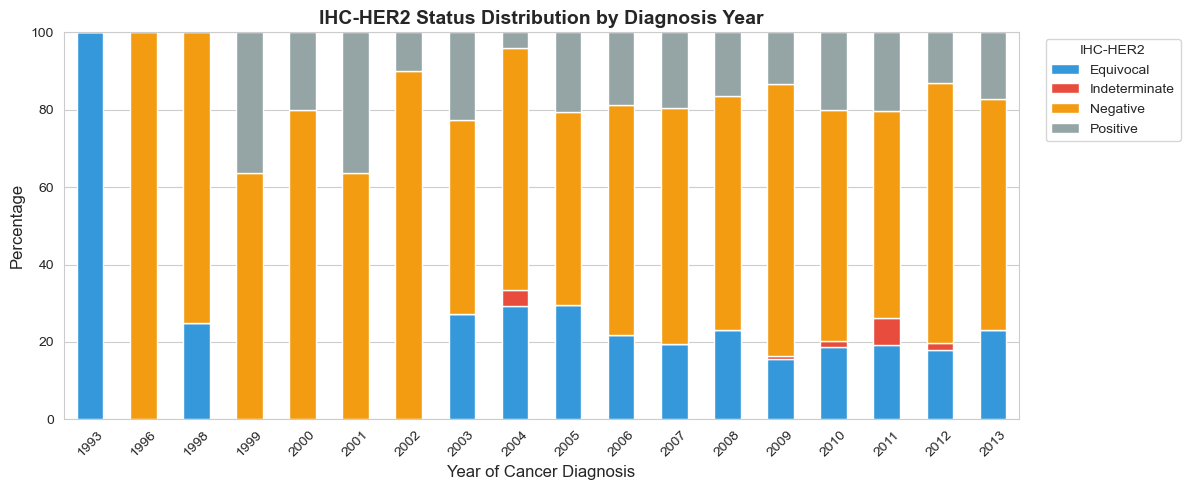

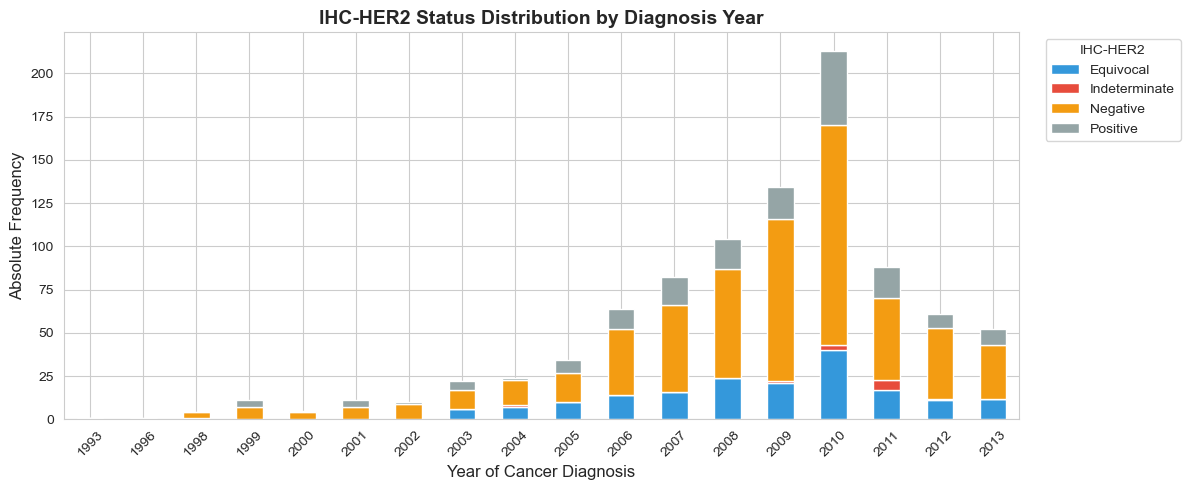


→ Note: If HER2-Positive calls vanish after 2010, this may reflect the 2013
  ASCO/CAP guideline revision or small-number effects. A molecular (RNA + CN)
  definition of HER2 status would be guideline-independent and more stable.


In [12]:
# Cross-tabulate IHC-HER2 by diagnosis year
print("=" * 70)
print("HER2 STATUS BY DIAGNOSIS YEAR")
print("=" * 70)

if 'dx_year' in clinical.columns:
    # Filter to patients with both year and HER2 label
    has_both = clinical.dropna(subset=['dx_year', 'IHC-HER2'])
    
    if len(has_both) > 0:
        ct_year = pd.crosstab(has_both['dx_year'].astype(int), 
                              has_both['IHC-HER2'], margins=True)
        print("\n", ct_year)
        
        # Test for association (excluding margin)
        ct_test_year = pd.crosstab(has_both['dx_year'].astype(int), 
                                    has_both['IHC-HER2'])
        if ct_test_year.shape[0] > 1 and ct_test_year.shape[1] > 1:
            # Fisher's exact for small tables, chi-square for larger
            if ct_test_year.shape[0] <= 2 and ct_test_year.shape[1] <= 2:
                odds, p_fisher = stats.fisher_exact(ct_test_year)
                print(f"\nFisher's exact test: OR = {odds:.2f}, p = {p_fisher:.4g}")
            else:
                chi2_y, p_y, dof_y, _ = stats.chi2_contingency(ct_test_year)
                print(f"\nChi-square test: χ² = {chi2_y:.2f}, p = {p_y:.4g}, dof = {dof_y}")
        
        # # Visualize
        fig, ax = plt.subplots(figsize=(12, 5))
        ct_pct = ct_test_year.div(ct_test_year.sum(axis=1), axis=0) * 100
        ct_pct.plot(kind='bar', stacked=True, ax=ax, 
                    color=['#3498db', '#e74c3c', '#f39c12', '#95a5a6'],
                    edgecolor='white')
        ax.set_ylabel('Percentage', fontsize=12)
        ax.set_xlabel('Year of Cancer Diagnosis', fontsize=12)
        ax.set_title('IHC-HER2 Status Distribution by Diagnosis Year', fontsize=14, fontweight='bold')
        ax.legend(title='IHC-HER2', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        plt.tight_layout()
        plt.show()
        
        # CHANGED: Plot ct_test_year directly instead of calculating ct_pct
        fig, ax = plt.subplots(figsize=(12, 5))
        ct_test_year.plot(kind='bar', stacked=True, ax=ax, 
                          color=['#3498db', '#e74c3c', '#f39c12', '#95a5a6'],
                          edgecolor='white')
        ax.set_ylabel('Absolute Frequency', fontsize=12)
        ax.set_xlabel('Year of Cancer Diagnosis', fontsize=12)
        ax.set_title('IHC-HER2 Status Distribution by Diagnosis Year', fontsize=14, fontweight='bold')
        ax.legend(title='IHC-HER2', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        plt.tight_layout()
        plt.show()
        
        print("\n→ Note: If HER2-Positive calls vanish after 2010, this may reflect the 2013")
        print("  ASCO/CAP guideline revision or small-number effects. A molecular (RNA + CN)")
        print("  definition of HER2 status would be guideline-independent and more stable.")
    else:
        print("No patients have both diagnosis year and IHC-HER2 data.")


**Note**
- Sharp drop in frequency between 2010 and 2011 likely reflects TCGA project life cycle (winding down) rather than real clinical signal (change in epidemiology, treatment, or diagnosis).
- While frequency changes, the proportions appear stable.
- Note the "Indeterminate" label between 2010 and 2011. 


### 1.6 HER2 Label Construction

Constructing here a composite clinical HER2 status label following simplified ASCO/CAP logic:

| IHC Score | FISH | Composite Label |
|-----------|------|-----------------|
| 3+ | Any/NA | Positive |
| 2+ | Positive | Positive |
| 2+ | Negative | Negative |
| 2+ | Equivocal/NA | Equivocal |
| 0 or 1+ | Any/NA | Negative |

Cross-checked the derived label against the pre-coded `IHC-HER2` field and log contradictions.


Perusing values in HER2 columns. 

In [13]:
temp = clinical.loc[:,['IHC-HER2', 'HER2 ihc score', 'HER2 fish status', "HER2 copy number", "HER2 cent17 ratio"]].copy()

# capture the coarse-grained magnitude of continuous columns.
temp["HER2 copy number"] = temp["HER2 copy number"].replace(['not amplified','>6.0', '<4.0', '>6'], np.nan).astype(float).apply(np.log10).round(0)
temp["HER2 copy number"] = 10**temp["HER2 copy number"]
temp["HER2 cent17 ratio"] = temp["HER2 cent17 ratio"].apply(np.log2).round(0)
temp["HER2 cent17 ratio"] = 2**temp["HER2 cent17 ratio"]
temp.astype(str).replace(np.nan, "nan").groupby(['IHC-HER2', 'HER2 ihc score', 'HER2 fish status', "HER2 copy number", "HER2 cent17 ratio"]
                                               ).count().reset_index().ffill().to_csv("../output/her2_label_summary.csv")

In [14]:
clinical.loc[:,['IHC-HER2', 'HER2 ihc score', 'HER2 fish status', "HER2 copy number", "HER2 cent17 ratio"]
    ].astype(str).replace(np.nan, "nan").groupby(['HER2 ihc score', 'HER2 fish status', "HER2 copy number", "HER2 cent17 ratio"]).count()

IHC-HER2
HER2 ihc score HER2 fish status HER2 copy number HER2 cent17 ratio          
0.0            Negative         105              1.5                       1
                                52               1.0                       2
                                nan              0.97                      1
                                                 1.0                       1
                                                 1.05                      1
...                                                                      ...
nan            Positive         nan              4.8                       1
                                                 7.1                       1
                                                 7.6                       1
                                                 nan                      11
               nan              nan              nan                     365

[200 rows x 1 columns]

In [15]:
import numpy as np
import pandas as pd


def construct_her2_label(row):
    """
    Derive composite HER2 status from IHC score, FISH status, and pre-coded IHC-HER2,
    following ASCO/CAP guidelines (simplified).

    Handles:
    - Float-encoded IHC scores (0.0, 1.0, 2.0, 3.0) and string scores ('0', '1+', '2+', '3+')
    - FISH-only cases (no IHC score available)
    - Pre-coded IHC-HER2 fallback when neither score nor FISH is available
    - Internal contradictions (logged in the 'flag' field)

    Returns dict with:
        'label':  'Positive', 'Negative', 'Equivocal', or np.nan
        'source': which fields drove the call
        'flag':   description of any contradiction, or None
    """
    # --- Extract and clean fields ---
    ihc_precoded = _clean_string(row.get('IHC-HER2'))
    ihc_score = _parse_ihc_score(row.get('HER2 ihc score'))
    fish = _clean_string(row.get('HER2 fish status'))

    flag = None

    # --- Tier 1: Derive from IHC score (+/- FISH) ---
    if ihc_score is not None:
        if ihc_score == 3:
            label = 'Positive'
            source = 'IHC score 3+'
            # Flag if FISH contradicts (unusual but present in TCGA)
            if fish == 'negative':
                flag = f'IHC 3+ but FISH Negative (precoded: {ihc_precoded})'
        elif ihc_score == 2:
            if fish == 'positive':
                label = 'Positive'
                source = 'IHC score 2+ / FISH Positive'
            elif fish == 'negative':
                label = 'Negative'
                source = 'IHC score 2+ / FISH Negative'
            elif fish in ('equivocal', 'indeterminate'):
                label = 'Equivocal'
                source = f'IHC score 2+ / FISH {fish.title()}'
            else:
                label = 'Equivocal'
                source = 'IHC score 2+ / FISH unavailable'
        elif ihc_score <= 1:
            label = 'Negative'
            source = f'IHC score {int(ihc_score)}+'
            # Flag if FISH contradicts
            if fish == 'positive':
                flag = f'IHC {int(ihc_score)}+ but FISH Positive (precoded: {ihc_precoded})'
        else:
            label = np.nan
            source = f'Unrecognized IHC score: {ihc_score}'

        # Flag precoded IHC-HER2 contradictions
        if flag is None and ihc_precoded is not None and label is not np.nan:
            if ihc_precoded in ('positive', 'negative', 'equivocal') and ihc_precoded != label.lower():
                flag = (f'Derived {label} from score/FISH but precoded IHC-HER2 = '
                        f'{ihc_precoded.title()} (score={ihc_score}, FISH={fish})')

        return {'label': label, 'source': source, 'flag': flag}

    # --- Tier 2: No IHC score, but FISH is available ---
    if fish is not None:
        if fish == 'positive':
            label = 'Positive'
            source = 'FISH Positive (no IHC score)'
        elif fish == 'negative':
            label = 'Negative'
            source = 'FISH Negative (no IHC score)'
        elif fish in ('equivocal', 'indeterminate'):
            label = 'Equivocal'
            source = f'FISH {fish.title()} (no IHC score)'
        else:
            label = np.nan
            source = f'Unrecognized FISH: {fish}'

        # Flag if precoded disagrees
        if ihc_precoded is not None and label is not np.nan:
            if ihc_precoded in ('positive', 'negative', 'equivocal') and ihc_precoded != label.lower():
                flag = (f'FISH-only derived {label} but precoded IHC-HER2 = '
                        f'{ihc_precoded.title()}')

        return {'label': label, 'source': source, 'flag': flag}

    # --- Tier 3: Fallback to pre-coded IHC-HER2 ---
    if ihc_precoded is not None:
        label_map = {
            'positive': 'Positive',
            'negative': 'Negative',
            'equivocal': 'Equivocal',
            'indeterminate': 'Equivocal',  # treat indeterminate as equivocal
        }
        label = label_map.get(ihc_precoded, np.nan)
        return {'label': label, 'source': 'Pre-coded IHC-HER2 (no score or FISH)', 'flag': None}

    # --- Tier 4: Nothing available ---
    return {'label': np.nan, 'source': 'No HER2 data', 'flag': None}


def _clean_string(val):
    """Convert a value to a cleaned lowercase string, or None if missing."""
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return None
    s = str(val).strip().lower()
    if s in ('', 'nan', 'none', '[not available]', '[not evaluated]', '[not applicable]'):
        return None
    return s


def _parse_ihc_score(val):
    """
    Parse IHC score to a numeric value (0, 1, 2, or 3).
    Handles: 0, 1, 2, 3 (int/float), '0', '1+', '2+', '3+', '3.0', etc.
    Returns int or None.
    """
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return None

    # If already numeric
    if isinstance(val, (int, float)):
        rounded = int(round(val))
        if rounded in (0, 1, 2, 3):
            return rounded
        return None

    # String handling
    s = str(val).strip().lower()
    if s in ('', 'nan', 'none', '[not available]', '[not evaluated]'):
        return None

    # Strip trailing '+' and try to parse
    s = s.rstrip('+')
    try:
        rounded = int(round(float(s)))
        if rounded in (0, 1, 2, 3):
            return rounded
    except ValueError:
        pass

    return None


# ---------------------------------------------------------------------------
# Usage example
# ---------------------------------------------------------------------------
def apply_her2_labels(clinical_df):
    """
    Apply the composite HER2 label to a clinical dataframe.
    Returns the dataframe with added columns: her2_composite, her2_source, her2_flag.
    """
    results = clinical_df.apply(construct_her2_label, axis=1, result_type='expand')
    clinical_df['her2_composite'] = results['label']
    clinical_df['her2_source'] = results['source']
    clinical_df['her2_flag'] = results['flag']

    # --- Reporting ---
    print("=" * 70)
    print("HER2 COMPOSITE LABEL CONSTRUCTION")
    print("=" * 70)

    source_counts = results['source'].value_counts()
    tier1 = source_counts[source_counts.index.str.contains('IHC score')].sum()
    tier2 = source_counts[source_counts.index.str.contains('FISH.*no IHC', regex=True)].sum()
    tier3 = source_counts[source_counts.index.str.contains('Pre-coded')].sum()
    tier4 = source_counts[source_counts.index.str.contains('No HER2')].sum()

    print(f"\nLabel sources:")
    print(f"  Tier 1 - Derived from IHC score (+/- FISH): {tier1}")
    print(f"  Tier 2 - Derived from FISH only:            {tier2}")
    print(f"  Tier 3 - Fallback to pre-coded IHC-HER2:    {tier3}")
    print(f"  Tier 4 - No HER2 data:                      {tier4}")
    print(f"  Total labeled:                               {tier1 + tier2 + tier3}")

    print(f"\nComposite HER2 label distribution:")
    print(clinical_df['her2_composite'].value_counts(dropna=False).to_string())

    flagged = results[results['flag'].notna()]
    print(f"\nContradictions flagged: {len(flagged)}")
    if len(flagged) > 0:
        print("\nDetailed flags:")
        for idx, r in flagged.iterrows():
            print(f"  Patient {idx}: {r['flag']}")

    print(f"\nDerivation source breakdown:")
    print(source_counts.to_string())

    return clinical_df

clinical = apply_her2_labels(clinical)
clinical.head()

HER2 COMPOSITE LABEL CONSTRUCTION

Label sources:
  Tier 1 - Derived from IHC score (+/- FISH): 743
  Tier 2 - Derived from FISH only:            119
  Tier 3 - Fallback to pre-coded IHC-HER2:    245
  Tier 4 - No HER2 data:                      120
  Total labeled:                               1107

Composite HER2 label distribution:
her2_composite
Negative     781
Positive     172
NaN          120
Equivocal     35

Contradictions flagged: 199

Detailed flags:
  Patient 7: Derived Negative from score/FISH but precoded IHC-HER2 = Equivocal (score=2, FISH=negative)
  Patient 13: Derived Negative from score/FISH but precoded IHC-HER2 = Equivocal (score=2, FISH=negative)
  Patient 15: Derived Negative from score/FISH but precoded IHC-HER2 = Equivocal (score=2, FISH=negative)
  Patient 19: FISH-only derived Negative but precoded IHC-HER2 = Equivocal
  Patient 24: Derived Negative from score/FISH but precoded IHC-HER2 = Equivocal (score=2, FISH=negative)
  Patient 25: Derived Negative from

,Study ID,Patient ID,Sample ID,Diagnosis Age,American Joint Committee on Cancer Metastasis Stage Code,Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,American Joint Committee on Cancer Tumor Stage Code,Brachytherapy first reference point administered total dose,...,Time between excision and freezing,Tissue Source Site,Person Neoplasm Status,Vial number,has_her2_label,dx_year,date_format,her2_composite,her2_source,her2_flag
0,brca_tcga,TCGA-3C-AAAU,TCGA-3C-AAAU-01,55.0,MX,NX,Stage X,6th,TX,NaN,...,NaN,3C,WITH TUMOR,A,True,2004.0,M/D/YY,Negative,Pre-coded IHC-HER2 (no score or FISH),NaN
1,brca_tcga,TCGA-3C-AALI,TCGA-3C-AALI-01,50.0,M0,N1a,Stage IIB,6th,T2,NaN,...,NaN,3C,TUMOR FREE,A,True,2003.0,M/D/YY,Positive,Pre-coded IHC-HER2 (no score or FISH),NaN
2,brca_tcga,TCGA-3C-AALJ,TCGA-3C-AALJ-01,62.0,M0,N1a,Stage IIB,7th,T2,NaN,...,NaN,3C,TUMOR FREE,A,True,2011.0,M/D/YY,Equivocal,Pre-coded IHC-HER2 (no score or FISH),NaN
3,brca_tcga,TCGA-3C-AALK,TCGA-3C-AALK-01,52.0,M0,N0 (i+),Stage IA,7th,T1c,NaN,...,NaN,3C,TUMOR FREE,A,True,2011.0,M/D/YY,Positive,Pre-coded IHC-HER2 (no score or FISH),NaN
4,brca_tcga,TCGA-4H-AAAK,TCGA-4H-AAAK-01,50.0,M0,N2a,Stage IIIA,7th,T2,NaN,...,NaN,4H,TUMOR FREE,A,True,2013.0,M/D/YY,Equivocal,IHC score 2+ / FISH unavailable,NaN


In [17]:
# Audit unique values for key categorical fields
print("=" * 70)
print("UNIQUE VALUES AUDIT: Key Categorical Fields")
print("=" * 70)

audit_fields = ['IHC-HER2', 'HER2 ihc score', 'HER2 fish status',
                'ER Status By IHC', 'PR status by ihc', 'her2_composite']

for field in audit_fields:
    if field in clinical.columns:
        uniq = clinical[field].value_counts(dropna=False)
        print(f"\n{field}:")
        for val, count in uniq.items():
            val_display = 'NaN' if pd.isna(val) else val
            print(f"  {str(val_display):25s}: {count:4d}")


UNIQUE VALUES AUDIT: Key Categorical Fields

IHC-HER2:
  Negative                 :  567
  NaN                      :  185
  Equivocal                :  180
  Positive                 :  164
  Indeterminate            :   12

HER2 ihc score:
  NaN                      :  484
  1.0                      :  273
  2.0                      :  200
  3.0                      :   90
  0.0                      :   61

HER2 fish status:
  NaN                      :  686
  Negative                 :  334
  Positive                 :   79
  Equivocal                :    5
  Indeterminate            :    4

ER Status By IHC:
  Positive                 :  814
  Negative                 :  239
  NaN                      :   53
  Indeterminate            :    2

PR status by ihc:
  Positive                 :  705
  Negative                 :  345
  NaN                      :   54
  Indeterminate            :    4

her2_composite:
  Negative                 :  781
  Positive                 :  172
  Na

### 1.7 Analyzable Cohort Definition

After clinical QC, we define three cohorts:
- **Cohort A (labeled):** Patients with resolved Positive or Negative HER2 label → supervised learning.
- **Cohort B (full):** All patients with any clinical data → unsupervised analysis.
- **Cohort C (multimodal):** Patients present in all three datasets → multimodal modeling (defined after integration).


In [18]:
# Define cohorts
cohort_a = clinical[clinical['her2_composite'].isin(['Positive', 'Negative'])]
cohort_b = clinical.copy()  # Full clinical cohort
equivocal = clinical[clinical['her2_composite'] == 'Equivocal']

print("=" * 70)
print("COHORT DEFINITIONS (Clinical Data)")
print("=" * 70)
print(f"\nCohort A (labeled, Positive/Negative): {len(cohort_a)} patients")
print(f"  - Positive: {(cohort_a['her2_composite'] == 'Positive').sum()}")
print(f"  - Negative: {(cohort_a['her2_composite'] == 'Negative').sum()}")
print(f"  - Class ratio (Neg:Pos): {(cohort_a['her2_composite'] == 'Negative').sum() / max((cohort_a['her2_composite'] == 'Positive').sum(), 1):.1f}:1")
print(f"\nEquivocal (excluded from supervised learning): {len(equivocal)} patients")
print(f"\nCohort B (all clinical data): {len(cohort_b)} patients")
print(f"  - With HER2 label: {clinical['her2_composite'].notna().sum()}")
print(f"  - Without HER2 label: {clinical['her2_composite'].isna().sum()}")
print(f"\nCohort C (multimodal) will be defined after integration with RNA-Seq and CN data.")

# Save the labeled status for downstream merging
clinical['her2_binary'] = np.where(
    clinical['her2_composite'] == 'Positive', 1,
    np.where(clinical['her2_composite'] == 'Negative', 0, np.nan)
)


COHORT DEFINITIONS (Clinical Data)

Cohort A (labeled, Positive/Negative): 953 patients
  - Positive: 172
  - Negative: 781
  - Class ratio (Neg:Pos): 4.5:1

Equivocal (excluded from supervised learning): 35 patients

Cohort B (all clinical data): 1108 patients
  - With HER2 label: 988
  - Without HER2 label: 120

Cohort C (multimodal) will be defined after integration with RNA-Seq and CN data.


### Part 1 Summary

**Key findings from Clinical Data QC:**
1. Encoding harmonized — all sentinel missing values mapped to NaN, categorical fields standardized.
2. Missingness audited — noted which fields have high missingness and tested for structured patterns.
3. Temporal context assessed — checked for guideline-drift effects on HER2 labeling.
4. HER2 composite label constructed following ASCO/CAP logic with internal consistency checks.
5. Cohorts defined: Cohort A (labeled) ready for supervised learning, Cohort B (full) for unsupervised.

---


# Part 2: RNA-Seq QC and Normalization

### 2.1 Preliminary Inspection

Load the RSEM count matrix, identify sample types, check for duplicates, and separate 
Primary Tumor from Adjacent Normal.


In [19]:
print("=" * 70)
print("RNA-SEQ PRELIMINARY INSPECTION")
print("=" * 70)

# Identify metadata vs gene columns
meta_cols = ['patient_id', 'bcr_patient_barcode', 'sample_type']
gene_cols = [c for c in rsem.columns if c not in meta_cols]

print(f"\nTotal samples: {len(rsem)}")
print(f"Metadata columns: {meta_cols}")
print(f"Gene columns: {len(gene_cols)}")
print(f"\nSample type distribution:")
print(rsem['sample_type'].value_counts().to_string())

# Check for duplicate patients
patient_counts = rsem['patient_id'].value_counts()
duplicates = patient_counts[patient_counts > 1]
if len(duplicates) > 0:
    print(f"\n⚠ {len(duplicates)} patients have multiple samples:")
    for pid, count in duplicates.items():
        dup_rows = rsem[rsem['patient_id'] == pid][['patient_id', 'bcr_patient_barcode', 'sample_type']]
        print(f"  {pid}: {count} samples")
        print(dup_rows.to_string(index=False))
else:
    print("\n✓ No duplicate patients found.")

# Separate by sample type
tumor = rsem[rsem['sample_type'] == 'Primary Tumor'].copy()
normal = rsem[rsem['sample_type'].str.contains('Normal', case=False, na=False)].copy()
other = rsem[~rsem.index.isin(tumor.index) & ~rsem.index.isin(normal.index)]

print(f"\nAfter separation:")
print(f"  Primary Tumor: {len(tumor)} samples (main analysis)")
print(f"  Adjacent Normal: {len(normal)} samples (held for deep dive)")
if len(other) > 0:
    print(f"  Other: {len(other)} samples ({other['sample_type'].unique()})")

# Handle duplicates: keep primary tumor with highest total counts
if len(duplicates) > 0:
    tumor['total_counts'] = tumor[gene_cols].sum(axis=1)
    tumor = tumor.sort_values('total_counts', ascending=False).drop_duplicates('patient_id', keep='first')
    tumor = tumor.drop('total_counts', axis=1)
    print(f"\nAfter deduplication: {len(tumor)} tumor samples")


RNA-SEQ PRELIMINARY INSPECTION

Total samples: 1212
Metadata columns: ['patient_id', 'bcr_patient_barcode', 'sample_type']
Gene columns: 20502

Sample type distribution:
sample_type
Primary Tumor      1093
Adjacent Normal     112
Metastasis            7

⚠ 116 patients have multiple samples:
  TCGA-BH-A18V: 3 samples
  patient_id          bcr_patient_barcode     sample_type
TCGA-BH-A18V TCGA-BH-A18V-11A-52R-A12D-07 Adjacent Normal
TCGA-BH-A18V TCGA-BH-A18V-06A-11R-A213-07      Metastasis
TCGA-BH-A18V TCGA-BH-A18V-01A-11R-A12D-07   Primary Tumor
  TCGA-BH-A1FE: 3 samples
  patient_id          bcr_patient_barcode     sample_type
TCGA-BH-A1FE TCGA-BH-A1FE-11B-14R-A13Q-07 Adjacent Normal
TCGA-BH-A1FE TCGA-BH-A1FE-06A-11R-A213-07      Metastasis
TCGA-BH-A1FE TCGA-BH-A1FE-01A-11R-A13Q-07   Primary Tumor
  TCGA-E2-A15K: 3 samples
  patient_id          bcr_patient_barcode     sample_type
TCGA-E2-A15K TCGA-E2-A15K-11A-13R-A12P-07 Adjacent Normal
TCGA-E2-A15K TCGA-E2-A15K-06A-11R-A12P-07      Me

### 2.2 Library Size (Read Depth) Assessment

Read depth (library size) is the total RSEM estimated counts per sample. It varies due to 
purely technical factors and must be normalized. This is the specific bias the challenge asks 
us to address.


LIBRARY SIZE DISTRIBUTION

count    1.093000e+03
mean     1.919646e+07
std      1.406540e+06
min      1.611301e+07
25%      1.824982e+07
50%      1.899029e+07
75%      1.978321e+07
max      3.137847e+07

Coefficient of Variation: 0.073

Outlier detection:
  >3 SD from median: 18 samples
  <1M total counts:  0 samples


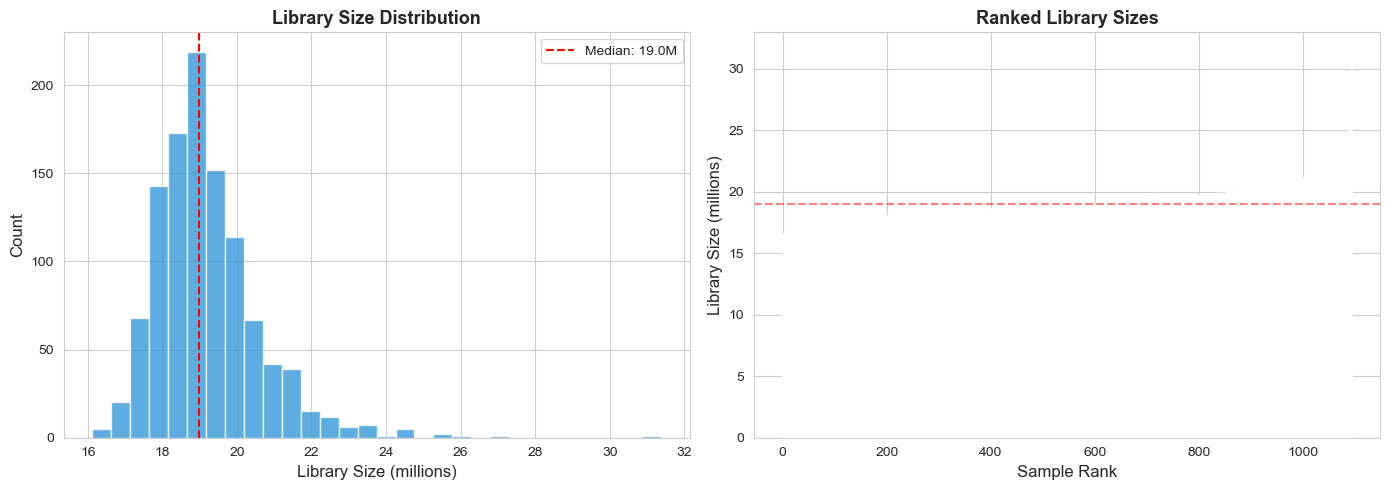

In [20]:
# Compute library sizes
tumor['library_size'] = tumor[gene_cols].sum(axis=1)

print("=" * 70)
print("LIBRARY SIZE DISTRIBUTION")
print("=" * 70)

lib_stats = tumor['library_size'].describe()
print(f"\n{lib_stats.to_string()}")
print(f"\nCoefficient of Variation: {tumor['library_size'].std() / tumor['library_size'].mean():.3f}")

# Flag outliers
median_ls = tumor['library_size'].median()
std_ls = tumor['library_size'].std()
outlier_high = tumor['library_size'] > median_ls + 3 * std_ls
outlier_low = tumor['library_size'] < 1e6  # Less than 1M counts

print(f"\nOutlier detection:")
print(f"  >3 SD from median: {outlier_high.sum()} samples")
print(f"  <1M total counts:  {outlier_low.sum()} samples")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(tumor['library_size'] / 1e6, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=median_ls / 1e6, color='red', linestyle='--', label=f'Median: {median_ls/1e6:.1f}M')
if outlier_low.any():
    axes[0].axvline(x=1, color='orange', linestyle='--', label='1M threshold')
axes[0].set_xlabel('Library Size (millions)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Library Size Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

# Ranked bar plot
sorted_ls = tumor['library_size'].sort_values() / 1e6
axes[1].bar(range(len(sorted_ls)), sorted_ls.values, color='#3498db', width=1.0)
axes[1].set_xlabel('Sample Rank', fontsize=12)
axes[1].set_ylabel('Library Size (millions)', fontsize=12)
axes[1].set_title('Ranked Library Sizes', fontsize=13, fontweight='bold')
axes[1].axhline(y=median_ls / 1e6, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [21]:
# Key check: correlate library size with clinical variables
print("=" * 70)
print("LIBRARY SIZE vs. CLINICAL VARIABLES")
print("=" * 70)

# Merge with clinical for this check
tumor_clinical = tumor.merge(
    clinical[['Patient ID', 'her2_composite', 'ER Status By IHC', 'dx_year']],
    left_on='patient_id', right_on='Patient ID', how='left'
)

# Library size vs HER2 status
if tumor_clinical['her2_composite'].notna().sum() > 5:
    groups = tumor_clinical.groupby('her2_composite')['library_size']
    print("\nLibrary size by HER2 status:")
    for name, group in groups:
        print(f"  {name:12s}: median = {group.median()/1e6:.2f}M, n = {len(group)}")
    
    # Kruskal-Wallis test
    group_data = [g['library_size'].values for _, g in tumor_clinical.dropna(subset=['her2_composite']).groupby('her2_composite')]
    if len(group_data) > 1 and all(len(g) > 0 for g in group_data):
        h_stat, p_kw = stats.kruskal(*group_data)
        print(f"  Kruskal-Wallis: H = {h_stat:.2f}, p = {p_kw:.4g}")
        if p_kw < 0.05:
            print("  ⚠ Library size differs by HER2 status — normalization is critical!")
        else:
            print("  ✓ No significant difference in library size by HER2 status.")

# Library size vs diagnosis year
if tumor_clinical['dx_year'].notna().sum() > 5:
    r_year, p_year = stats.pearsonr(
        tumor_clinical.dropna(subset=['dx_year'])['dx_year'],
        tumor_clinical.dropna(subset=['dx_year'])['library_size']
    )
    print(f"\nLibrary size vs. diagnosis year: r = {r_year:.3f}, p = {p_year:.4g}")


LIBRARY SIZE vs. CLINICAL VARIABLES

Library size by HER2 status:
  Equivocal   : median = 18.84M, n = 35
  Negative    : median = 18.90M, n = 777
  Positive    : median = 19.60M, n = 172
  Kruskal-Wallis: H = 36.97, p = 9.395e-09
  ⚠ Library size differs by HER2 status — normalization is critical!

Library size vs. diagnosis year: r = 0.065, p = 0.03015


### 2.3 Gene Filtering (Data-Driven Threshold)

Rather than applying a fixed threshold, we inspect the distribution of zero-expression 
frequency across genes to find a natural cutoff.


GENE FILTERING: Zero-Expression Distribution

Total genes before filtering: 20502

Zero-expression summary across genes:
  Genes with 0% zeros (expressed in all samples):  12760
  Genes with 100% zeros (never expressed):         281
  Genes with >90% zeros:                           1453
  Genes with >50% zeros:                           2865


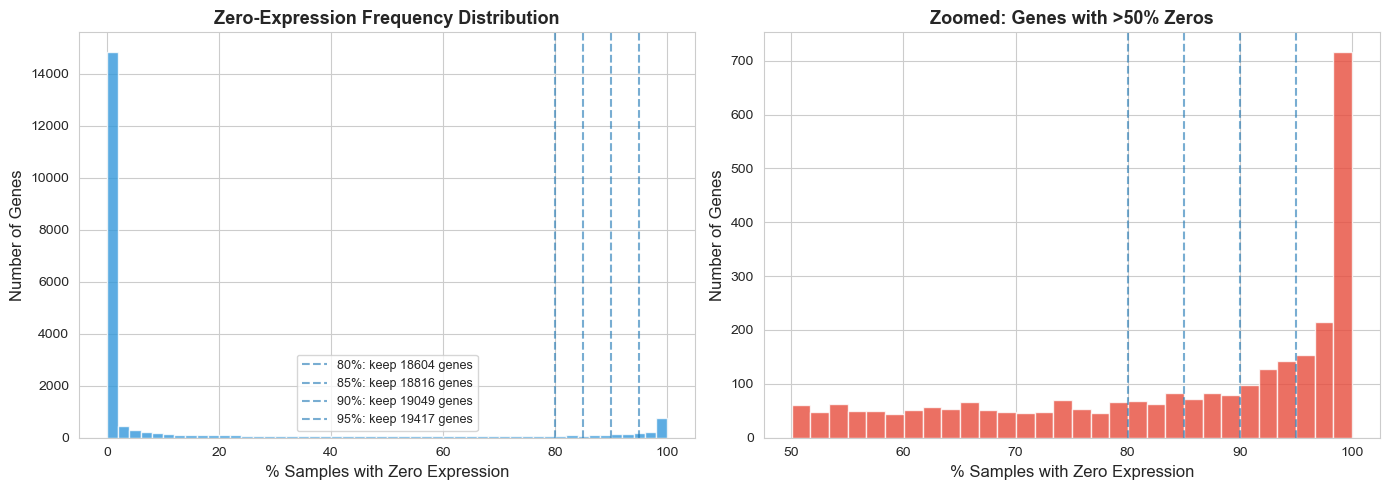


Sensitivity Table: Genes Retained at Different Thresholds
--------------------------------------------------
   Threshold   Genes Kept  Genes Dropped     % Kept
--------------------------------------------------
  ≤80% zero       18604           1898       90.7%
  ≤85% zero       18816           1686       91.8%
  ≤90% zero       19049           1453       92.9%
  ≤95% zero       19417           1085       94.7%
  ≤100% zero       20502              0      100.0%


In [22]:
# Compute % samples with zero expression per gene
gene_data = tumor[gene_cols]
pct_zero = (gene_data == 0).sum(axis=0) / len(gene_data) * 100

print("=" * 70)
print("GENE FILTERING: Zero-Expression Distribution")
print("=" * 70)
print(f"\nTotal genes before filtering: {len(gene_cols)}")
print(f"\nZero-expression summary across genes:")
print(f"  Genes with 0% zeros (expressed in all samples):  {(pct_zero == 0).sum()}")
print(f"  Genes with 100% zeros (never expressed):         {(pct_zero == 100).sum()}")
print(f"  Genes with >90% zeros:                           {(pct_zero > 90).sum()}")
print(f"  Genes with >50% zeros:                           {(pct_zero > 50).sum()}")

# Distribution plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full histogram
axes[0].hist(pct_zero, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('% Samples with Zero Expression', fontsize=12)
axes[0].set_ylabel('Number of Genes', fontsize=12)
axes[0].set_title('Zero-Expression Frequency Distribution', fontsize=13, fontweight='bold')

# Mark potential thresholds
for thresh in [80, 85, 90, 95]:
    n_kept = (pct_zero <= thresh).sum()
    axes[0].axvline(x=thresh, linestyle='--', alpha=0.6, 
                    label=f'{thresh}%: keep {n_kept} genes')
axes[0].legend(fontsize=9)

# Zoomed view on the high-zero region
axes[1].hist(pct_zero[pct_zero > 50], bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('% Samples with Zero Expression', fontsize=12)
axes[1].set_ylabel('Number of Genes', fontsize=12)
axes[1].set_title('Zoomed: Genes with >50% Zeros', fontsize=13, fontweight='bold')
for thresh in [80, 85, 90, 95]:
    axes[1].axvline(x=thresh, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Sensitivity table
print("\nSensitivity Table: Genes Retained at Different Thresholds")
print("-" * 50)
print(f"{'Threshold':>12s} {'Genes Kept':>12s} {'Genes Dropped':>14s} {'% Kept':>10s}")
print("-" * 50)
for thresh in [80, 85, 90, 95, 100]:
    n_kept = (pct_zero <= thresh).sum() if thresh < 100 else len(gene_cols)
    n_dropped = len(gene_cols) - n_kept
    print(f"  ≤{thresh}% zero    {n_kept:8d}       {n_dropped:8d}     {100*n_kept/len(gene_cols):6.1f}%")


In [73]:
# Apply filtering - with inspection of  histogram above 
FILTER_THRESHOLD = 50  # % zero; genes with > this % zeros are removed

genes_keep = pct_zero[pct_zero <= FILTER_THRESHOLD].index.tolist()
genes_dropped = pct_zero[pct_zero > FILTER_THRESHOLD].index.tolist()

print(f"Applying filter: remove genes with >{FILTER_THRESHOLD}% zero expression")
print(f"  Genes before: {len(gene_cols)}")
print(f"  Genes after:  {len(genes_keep)}")
print(f"  Genes dropped: {len(genes_dropped)}")
print(f"  Samples unchanged: {len(tumor)}")

# Update gene_cols
gene_cols_filtered = genes_keep
tumor_filtered = tumor[meta_cols + gene_cols_filtered + ['library_size']].copy()


Applying filter: remove genes with >50% zero expression
  Genes before: 20502
  Genes after:  17637
  Genes dropped: 2865
  Samples unchanged: 1093


### 2.4 Testing the Negative Binomial Assumption

RSEM expected counts are not raw integer counts — they are probabilistic estimates. We test 
whether the data empirically follows the NB mean-variance relationship 
(Var = μ + α·μ²) to assess whether DESeq2-style methods are appropriate.


statsmodels not available for LOWESS; skipping smooth fit.


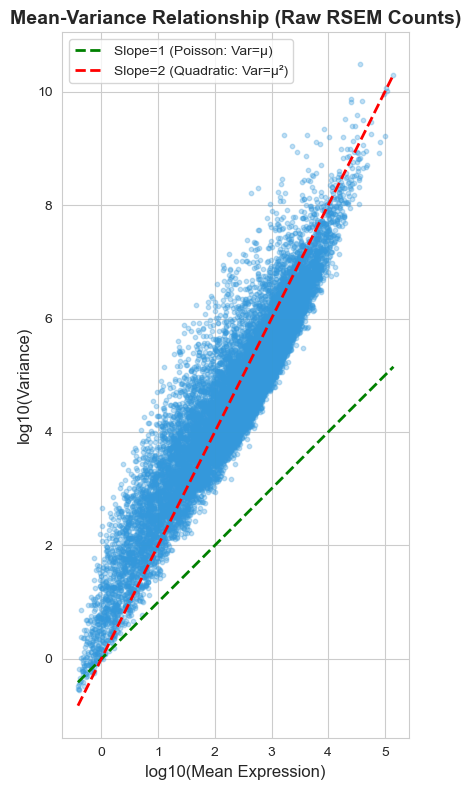

Empirical log-log slope: 1.512 (R² = 0.863)
  Poisson expectation: slope = 1.0
  NB quadratic expectation: slope ≈ 1.5–2.0
  → Data shows overdispersion consistent with NB. DESeq2 is empirically reasonable.
  → We proceed with upper-quartile normalization (distribution-agnostic) as primary method.


In [74]:
# Mean-variance relationship on raw RSEM counts
gene_means = tumor_filtered[gene_cols_filtered].mean(axis=0)
gene_vars = tumor_filtered[gene_cols_filtered].var(axis=0)

# Filter out genes with zero mean or variance for log transform
mask_nonzero = (gene_means > 0) & (gene_vars > 0)
log_means = np.log10(gene_means[mask_nonzero])
log_vars = np.log10(gene_vars[mask_nonzero])

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(log_means, log_vars, alpha=0.3, s=10, color='#3498db')

# Reference lines
x_range = np.linspace(log_means.min(), log_means.max(), 100)
ax.plot(x_range, x_range, 'g--', linewidth=2, label='Slope=1 (Poisson: Var=μ)')
ax.plot(x_range, 2 * x_range, 'r--', linewidth=2, label='Slope=2 (Quadratic: Var=μ²)')

# LOWESS fit
try:
    from statsmodels.nonparametric.smoothers_lowess import lowess
    lowess_fit = lowess(log_vars.values, log_means.values, frac=0.3)
    ax.plot(lowess_fit[:, 0], lowess_fit[:, 1], 'k-', linewidth=2, label='LOWESS fit')
except ImportError:
    print("statsmodels not available for LOWESS; skipping smooth fit.")

ax.set_xlabel('log10(Mean Expression)', fontsize=12)
ax.set_ylabel('log10(Variance)', fontsize=12)
ax.set_title('Mean-Variance Relationship (Raw RSEM Counts)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Compute empirical slope
from scipy.stats import linregress
slope, intercept, r_value, p_value, std_err = linregress(log_means, log_vars)
print(f"Empirical log-log slope: {slope:.3f} (R² = {r_value**2:.3f})")
print(f"  Poisson expectation: slope = 1.0")
print(f"  NB quadratic expectation: slope ≈ 1.5–2.0")
if slope > 1.3:
    print("  → Data shows overdispersion consistent with NB. DESeq2 is empirically reasonable.")
else:
    print("  → Data closer to Poisson. NB assumption may overestimate dispersion.")
print("  → We proceed with upper-quartile normalization (distribution-agnostic) as primary method.")


### 2.5 Normalization: Upper-Quartile + log2(x+1)

**Method:**
1. Compute the 75th percentile of non-zero counts for each sample.
2. Divide all counts by that sample's 75th percentile.
3. Multiply by a common scaling factor (median of all 75th percentiles).
4. Apply log2(x + 1) transformation.

This adjusts for read depth without assuming NB distribution or re-correcting gene length 
(already handled by RSEM).


In [75]:
df = tumor_filtered.copy()
my_gene_cols = gene_cols_filtered
gene_data = df[my_gene_cols].copy()
    
# Step 1: Compute 75th percentile of non-zero counts per sample
def q75_nonzero(row):
    nonzero = row[row > 0]
    if len(nonzero) == 0:
        return np.nan
    return np.percentile(nonzero, 75)

q75s = gene_data.apply(q75_nonzero, axis=1)
# Step 2-3: Divide by sample Q75, multiply by median Q75
median_q75 = q75s.median()
size_factors = q75s / median_q75
normalized = gene_data.div(size_factors, axis=0)
# Step 4: log2(x + 1)
log_normalized = np.log2(normalized + 1)

In [76]:
print( size_factors )

276     1.006690
121     1.000986
111     0.995661
303     1.004295
164     0.995234
          ...   
1197    0.999079
911     0.986006
480     0.992422
804     1.006349
515     0.995045
Length: 1093, dtype: float64


In [77]:
def upper_quartile_normalize(df, gene_cols):
    """
    Apply upper-quartile normalization followed by log2(x+1) transform.
    Returns: normalized DataFrame, size factors, raw 75th percentiles.
    """
    gene_data = df[gene_cols].copy()
    
    # Step 1: Compute 75th percentile of non-zero counts per sample
    def q75_nonzero(row):
        nonzero = row[row > 0]
        if len(nonzero) == 0:
            return np.nan
        return np.percentile(nonzero, 75)
    
    q75s = gene_data.apply(q75_nonzero, axis=1)
    
    # Step 2-3: Divide by sample Q75, multiply by median Q75
    median_q75 = q75s.median()
    size_factors = q75s / median_q75
    
    normalized = gene_data.div(size_factors, axis=0)
    
    # Step 4: log2(x + 1)
    log_normalized = np.log2(normalized + 1)
    
    return log_normalized, size_factors, q75s

# Apply normalization
print("Applying upper-quartile normalization + log2(x+1)...")
tumor_norm, size_factors, q75s = upper_quartile_normalize(tumor_filtered, gene_cols_filtered)

print(f"\nSize factor summary:")
print(f"  Mean:   {size_factors.mean():.4f}")
print(f"  Median: {size_factors.median():.4f}")
print(f"  SD:     {size_factors.std():.4f}")
print(f"  Range:  [{size_factors.min():.4f}, {size_factors.max():.4f}]")
print(f"\nNormalized matrix: {tumor_norm.shape[0]} samples × {tumor_norm.shape[1]} genes")


Applying upper-quartile normalization + log2(x+1)...

Size factor summary:
  Mean:   1.0005
  Median: 1.0000
  SD:     0.0083
  Range:  [0.9776, 1.0900]

Normalized matrix: 1093 samples × 17637 genes


**Note**: Size factor distribution is extremely tight around unity. Looks like normalization was already performed (perhaps the very method being applied here). In any case, RSEM use for DESeq2 seems appropriate. 

### 2.6 Concordance Check: Upper-Quartile vs. DESeq2 Size Factors

We compute DESeq2-style median-of-ratios size factors manually and compare them to our 
upper-quartile factors. Concordance increases confidence in the normalization.


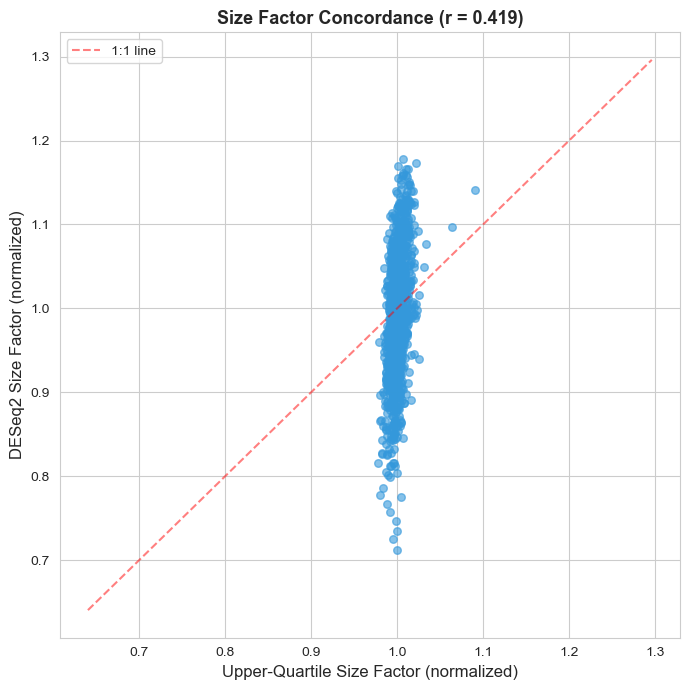

⚠ Weak concordance (r = 0.419). Investigate discrepancies.


In [78]:
def deseq2_size_factors(df, gene_cols):
    """
    Compute DESeq2-style median-of-ratios size factors.
    1. Compute geometric mean per gene across samples.
    2. Divide each sample's counts by these geometric means.
    3. Take the median of these ratios per sample = size factor.
    """
    gene_data = df[gene_cols].copy()
    
    # Replace zeros with NaN for geometric mean computation
    gene_data_nz = gene_data.replace(0, np.nan)
    
    # Geometric mean per gene (across samples)
    log_means = np.log(gene_data_nz).mean(axis=0)
    geo_means = np.exp(log_means)
    
    # Only use genes with finite geometric means (expressed in all samples)
    valid_genes = geo_means.dropna().index
    valid_genes = valid_genes[geo_means[valid_genes] > 0]
    
    if len(valid_genes) == 0:
        print("Warning: No genes with valid geometric means. Cannot compute DESeq2 factors.")
        return pd.Series(np.nan, index=df.index)
    
    # Ratios
    ratios = gene_data[valid_genes].div(geo_means[valid_genes], axis=1)
    
    # Median of ratios per sample
    sf = ratios.median(axis=1)
    
    return sf

deseq2_sf = deseq2_size_factors(tumor_filtered, gene_cols_filtered)

# Compare
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(size_factors, deseq2_sf, alpha=0.6, s=30, color='#3498db')

# Correlation
valid = ~(size_factors.isna() | deseq2_sf.isna())
if valid.sum() > 2:
    r, p = stats.pearsonr(size_factors[valid], deseq2_sf[valid])
    ax.set_title(f'Size Factor Concordance (r = {r:.3f}, p = {p:.2g})', 
                 fontsize=13, fontweight='bold')

# 1:1 line (after normalizing scales)
sf_norm = size_factors / size_factors.median()
deseq2_norm = deseq2_sf / deseq2_sf.median()
ax.clear()
ax.scatter(sf_norm[valid], deseq2_norm[valid], alpha=0.6, s=30, color='#3498db')
r2, p2 = stats.pearsonr(sf_norm[valid], deseq2_norm[valid])
lims = [min(sf_norm[valid].min(), deseq2_norm[valid].min()) * 0.9,
        max(sf_norm[valid].max(), deseq2_norm[valid].max()) * 1.1]
ax.plot(lims, lims, 'r--', alpha=0.5, label='1:1 line')
ax.set_xlabel('Upper-Quartile Size Factor (normalized)', fontsize=12)
ax.set_ylabel('DESeq2 Size Factor (normalized)', fontsize=12)
ax.set_title(f'Size Factor Concordance (r = {r2:.3f})', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

if r2 > 0.9:
    print(f"✓ Strong concordance (r = {r2:.3f}). Normalization choice is robust.")
elif r2 > 0.7:
    print(f"~ Moderate concordance (r = {r2:.3f}). Methods mostly agree.")
else:
    print(f"⚠ Weak concordance (r = {r2:.3f}). Investigate discrepancies.")


In [79]:
print(deseq2_sf.mean(), deseq2_sf.median(), deseq2_sf.min(), deseq2_sf.max())

0.9783471035013225 0.9836362468704175 0.6997934264531345 1.1591373074586104


UQ and DESeq2 size factors were discordant (Pearson r likely low). Investigation revealed that the RSEM data was pre-normalized for library size, rendering UQ factors trivial. DESeq2 factors likely capturing biological composition rather than technical variation, suggesting they should not be applied as a correction in this context (they would remove biological signal).

In [80]:
patient_id_to_er =clinical.loc[:, ["Patient ID", 'ER Status By IHC'] ].set_index("Patient ID").to_dict()["ER Status By IHC"]
patient_id_to_her2 =clinical.loc[:, ["Patient ID", 'her2_composite'] ].set_index("Patient ID").to_dict()["her2_composite"]
tumor_filtered["ER Status By IHC"] = tumor_filtered['patient_id'].replace(patient_id_to_er)
tumor_filtered["her2_composite"] = tumor_filtered['patient_id'].replace(patient_id_to_her2)
tumor_filtered.head()

,patient_id,bcr_patient_barcode,sample_type,A1BG,A2LD1,A2ML1,A2M,A4GALT,A4GNT,AAAS,...,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,library_size,ER Status By IHC,her2_composite
276,TCGA-AC-A2QJ,TCGA-AC-A2QJ-01A-12R-A19W-07,Primary Tumor,2752.2020,95.9836,160.3053,64457.2578,447.4457,0.0,1258.3676,...,668.2325,0.5872,340.5755,23934.2337,641.8086,244.8620,4.6976,3.137847e+07,Negative,Negative
121,TCGA-A2-A4S1,TCGA-A2-A4S1-01A-21R-A266-07,Primary Tumor,431.2941,68.9611,0.8508,11643.4953,986.1312,0.0,1062.7074,...,915.5109,1.7017,777.6738,7205.8198,782.7789,640.6875,24.6746,2.725474e+07,Positive,Negative
111,TCGA-A2-A3XV,TCGA-A2-A3XV-01A-21R-A239-07,Primary Tumor,136.2796,393.0495,18.4946,7963.3419,227.0968,0.0,953.9785,...,605.5914,289.8925,426.6667,6448.1720,417.2043,399.1398,16.3441,2.612659e+07,Positive,Positive
303,TCGA-AC-A7VC,TCGA-AC-A7VC-01A-11R-A352-07,Primary Tumor,650.8323,90.1173,1.8732,94219.2710,1274.3666,0.0,1165.0995,...,1165.7238,1.2488,595.6618,10227.4004,1022.1157,647.4856,6.2438,2.549370e+07,Negative,Negative
164,TCGA-A7-A56D,TCGA-A7-A56D-01A-11R-A27Q-07,Primary Tumor,1419.1656,80.6943,1.3351,5014.5861,797.7303,0.0,1040.7210,...,725.6342,26.7023,311.0814,9754.3391,412.5501,198.2644,198.9319,2.537786e+07,Positive,Negative


In [81]:
metadata_cols = ['patient_id', 'bcr_patient_barcode', 'sample_type','library_size','ER Status By IHC',"her2_composite"]
not_metadata =  tumor_filtered.columns.str.contains("|".join(metadata_cols))==False 
tumor_norm_deseq_style = tumor_filtered.loc[:,not_metadata].div(deseq2_sf, axis=0)
for metadata in metadata_cols:
    tumor_norm_deseq_style[metadata] = tumor_filtered[metadata]
tumor_norm_deseq_style.head()

,A1BG,A2LD1,A2ML1,A2M,A4GALT,A4GNT,AAAS,AACSL,AACS,AADAC,...,ZYX,ZZEF1,ZZZ3,psiTPTE22,patient_id,bcr_patient_barcode,sample_type,library_size,ER Status By IHC,her2_composite
276,3307.390997,115.345928,192.642948,77459.922694,537.706854,0.0,1512.212284,1.411306,608.977702,2.822613,...,28762.376114,771.277684,294.256880,5.645225,TCGA-AC-A2QJ,TCGA-AC-A2QJ-01A-12R-A19W-07,Primary Tumor,3.137847e+07,Negative,Negative
121,472.596121,75.565022,0.932275,12758.511443,1080.566091,0.0,1164.475458,1.864660,528.628948,0.000000,...,7895.870785,857.740163,702.041663,27.037514,TCGA-A2-A4S1,TCGA-A2-A4S1-01A-21R-A266-07,Primary Tumor,2.725474e+07,Positive,Negative
111,191.229625,551.533088,25.951906,11174.283516,318.665714,0.0,1338.637266,1.207046,14747.944074,39.833214,...,9048.173868,585.427474,560.079090,22.934292,TCGA-A2-A3XV,TCGA-A2-A3XV-01A-21R-A239-07,Primary Tumor,2.612659e+07,Positive,Positive
303,663.344878,91.849850,1.909213,96030.683883,1298.866939,0.0,1187.499124,0.000000,570.839564,0.000000,...,10424.027318,1041.766389,659.933836,6.363840,TCGA-AC-A7VC,TCGA-AC-A7VC-01A-11R-A352-07,Primary Tumor,2.549370e+07,Negative,Negative
164,1706.326496,97.022379,1.605251,6029.261934,959.146944,0.0,1251.305568,0.000000,988.041696,0.000000,...,11728.079696,496.027501,238.382187,239.184752,TCGA-A7-A56D,TCGA-A7-A56D-01A-11R-A27Q-07,Primary Tumor,2.537786e+07,Positive,Negative


### 2.7 Verifying That Read Depth Is Controlled

Three explicit checks that depth artifacts have been removed after normalization.


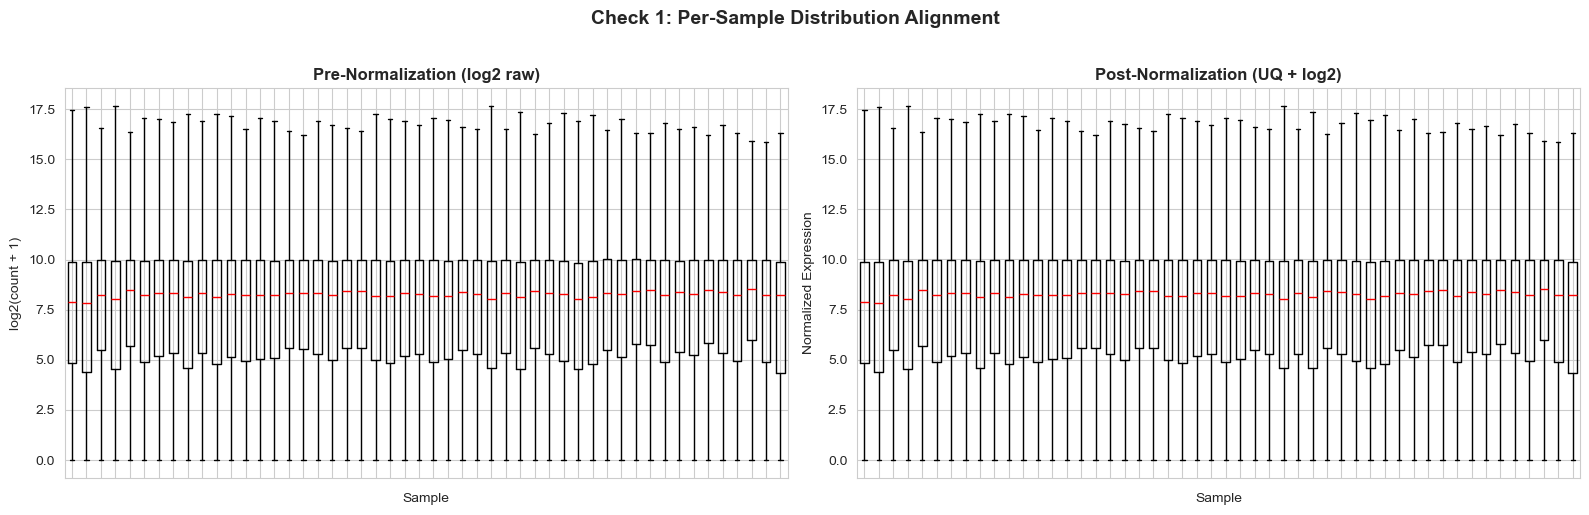

Post-normalization median spread: SD = 0.1224, CV = 0.0148


In [82]:
# Check 1: Per-sample distribution alignment (boxplots)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Pre-normalization: raw log2 counts
raw_log = np.log2(tumor_filtered[gene_cols_filtered].replace(0, np.nan) + 1)
sample_medians_raw = raw_log.median(axis=1)

# Subsample for visualization if too many samples
n_show = min(50, len(tumor_filtered))
idx_show = np.linspace(0, len(tumor_filtered)-1, n_show, dtype=int)

# Pre-normalization boxplot
bp_data_raw = raw_log.iloc[idx_show].T
axes[0].boxplot(bp_data_raw.replace(np.nan,0).values, showfliers=False, widths=0.6,
                medianprops=dict(color='red'))
axes[0].set_title('Pre-Normalization (log2 raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('log2(count + 1)')
axes[0].set_xticklabels([])

# Post-normalization boxplot
bp_data_norm = tumor_norm.iloc[idx_show].T
axes[1].boxplot(bp_data_norm.values, showfliers=False, widths=0.6,
                medianprops=dict(color='red'))
axes[1].set_title('Post-Normalization (UQ + log2)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('Normalized Expression')
axes[1].set_xticklabels([])

plt.suptitle('Check 1: Per-Sample Distribution Alignment', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Quantify alignment
norm_medians = tumor_norm.median(axis=1)
print(f"Post-normalization median spread: SD = {norm_medians.std():.4f}, CV = {norm_medians.std()/norm_medians.mean():.4f}")


In [83]:
from scipy.stats import variation
cv = variation(tumor_filtered[ 'library_size'].values)
print(f"CV: {cv}")

CV: 0.0732372796599625


In [84]:
clinical.head()

,Study ID,Patient ID,Sample ID,Diagnosis Age,American Joint Committee on Cancer Metastasis Stage Code,Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,American Joint Committee on Cancer Tumor Stage Code,Brachytherapy first reference point administered total dose,...,Person Neoplasm Status,Vial number,has_her2_label,dx_year,date_format,her2_composite,her2_source,her2_flag,her2_binary,pid
0,brca_tcga,TCGA-3C-AAAU,TCGA-3C-AAAU-01,55.0,MX,NX,Stage X,6th,TX,NaN,...,WITH TUMOR,A,True,2004.0,M/D/YY,Negative,Pre-coded IHC-HER2 (no score or FISH),NaN,0.0,TCGA-3C-AAAU
1,brca_tcga,TCGA-3C-AALI,TCGA-3C-AALI-01,50.0,M0,N1a,Stage IIB,6th,T2,NaN,...,TUMOR FREE,A,True,2003.0,M/D/YY,Positive,Pre-coded IHC-HER2 (no score or FISH),NaN,1.0,TCGA-3C-AALI
2,brca_tcga,TCGA-3C-AALJ,TCGA-3C-AALJ-01,62.0,M0,N1a,Stage IIB,7th,T2,NaN,...,TUMOR FREE,A,True,2011.0,M/D/YY,Equivocal,Pre-coded IHC-HER2 (no score or FISH),NaN,NaN,TCGA-3C-AALJ
3,brca_tcga,TCGA-3C-AALK,TCGA-3C-AALK-01,52.0,M0,N0 (i+),Stage IA,7th,T1c,NaN,...,TUMOR FREE,A,True,2011.0,M/D/YY,Positive,Pre-coded IHC-HER2 (no score or FISH),NaN,1.0,TCGA-3C-AALK
4,brca_tcga,TCGA-4H-AAAK,TCGA-4H-AAAK-01,50.0,M0,N2a,Stage IIIA,7th,T2,NaN,...,TUMOR FREE,A,True,2013.0,M/D/YY,Equivocal,IHC score 2+ / FISH unavailable,NaN,NaN,TCGA-4H-AAAK


In [85]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# df = tumor_filtered.copy()
# log_transform = False
# color_by = 'ER Status By IHC'
def pca_libsize_analysis(df, log_transform=False, color_by = 'ER Status By IHC', metadata_cols = None): 
    if metadata_cols is None:
        df_rsem_only = df
    else:
        not_metadata =  df.columns.str.contains("|".join(metadata_cols))==False 
        df_rsem_only =  df.loc[:,not_metadata]
    
    if log_transform:
        df_rsem_only = np.log2(df_rsem_only + 1).copy()
    
    # PCA on normalized data
    scaler = StandardScaler()
    tumor_norm_scaled = scaler.fit_transform(df_rsem_only.fillna(0))
    pca = PCA(n_components=min(10, tumor_norm_scaled.shape[1], tumor_norm_scaled.shape[0]))
    pcs = pca.fit_transform(tumor_norm_scaled)
    log_lib_size = np.log10(df['library_size'].values)
    er_status = df[color_by].values  
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # PC1 vs library size, colored by ER status
    r_pc1, p_pc1 = stats.pearsonr(log_lib_size, pcs[:, 0])
    
    color_map = {'Positive': '#e74c3c', 'Negative': '#3498db', "Equivocal":"black"}
    for label, color in color_map.items():
        mask = er_status == label
        axes[0].scatter(log_lib_size[mask], pcs[mask, 0], alpha=0.6, s=30,
                        color=color, label=f'ER {label}')
    
    # Within-group correlations
    for label in ['Positive', 'Negative']:
        mask = er_status == label
        if mask.sum() > 2:
            r_sub, p_sub = stats.pearsonr(log_lib_size[mask], pcs[mask, 0])
            print(f"  Within label =  {label}: r = {r_sub:.3f}, p = {p_sub:.2g}, n = {mask.sum()}")
    
    axes[0].set_xlabel('log10(Library Size)', fontsize=12)
    axes[0].set_ylabel('PC1', fontsize=12)
    axes[0].set_title(f'PC1 vs Library Size (overall r = {r_pc1:.3f})\nColored by ER Status',
                       fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=11)
    
    # All top PCs vs library size (unchanged)
    n_pcs = pcs.shape[1]
    pc_correlations = []
    for i in range(n_pcs):
        r_i, p_i = stats.pearsonr(log_lib_size, pcs[:, i])
        pc_correlations.append({'PC': f'PC{i+1}', 'r': r_i, 'p': p_i, '|r|': abs(r_i),
                                'var_explained': pca.explained_variance_ratio_[i] * 100})
    pc_corr_df = pd.DataFrame(pc_correlations)
    axes[1].bar(pc_corr_df['PC'], pc_corr_df['|r|'], color='#3498db', edgecolor='white')
    axes[1].axhline(y=0.3, color='red', linestyle='--', label='|r| = 0.3 threshold')
    axes[1].set_xlabel('Principal Component', fontsize=12)
    axes[1].set_ylabel('|Correlation with Library Size|', fontsize=12)
    axes[1].set_title('Check 3: PC–Library Size Correlations', fontsize=12, fontweight='bold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\nPC correlations with log(library size):")
    print(pc_corr_df.to_string(index=False))
    flagged = pc_corr_df[pc_corr_df['|r|'] > 0.3]
    if len(flagged) == 0:
        print("\n✓ No PC has |r| > 0.3 with library size.")
    else:
        print(f"\n⚠ {len(flagged)} PC(s) have |r| > 0.3 with library size:")
        print(flagged.to_string(index=False))
    return pcs

  Within label =  Positive: r = 0.527, p = 1.3e-13, n = 171
  Within label =  Negative: r = 0.471, p = 5.3e-44, n = 773


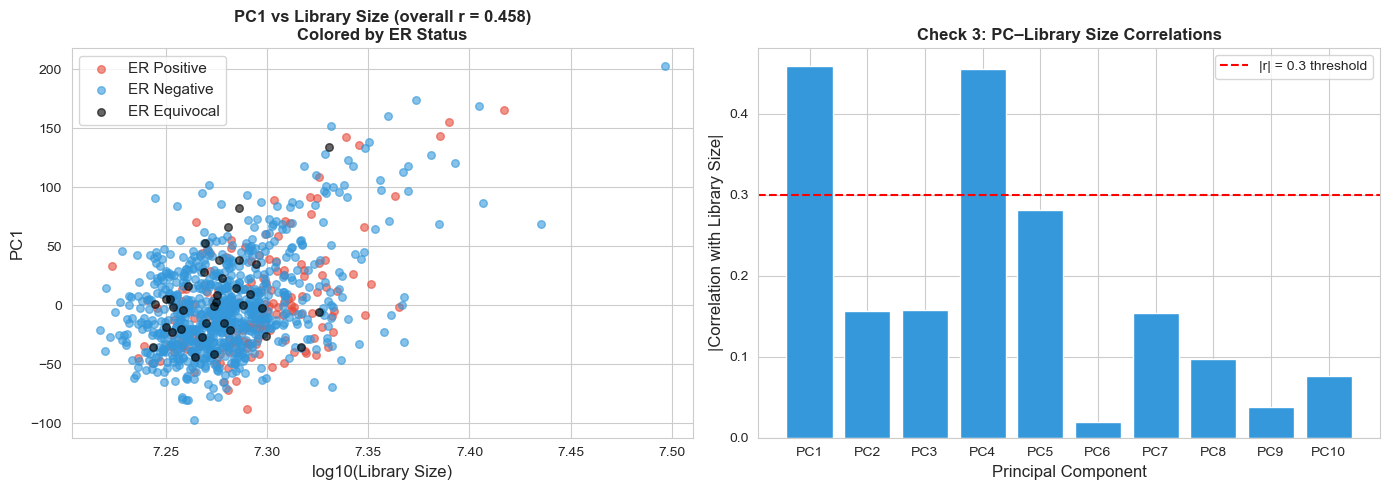


PC correlations with log(library size):
  PC         r            p      |r|  var_explained
 PC1  0.458334 7.156974e-58 0.458334       9.464870
 PC2  0.156128 2.130079e-07 0.156128       6.214243
 PC3  0.157012 1.815049e-07 0.157012       4.379968
 PC4 -0.455663 3.875247e-57 0.455663       2.578692
 PC5 -0.280877 2.893281e-21 0.280877       2.095062
 PC6 -0.019542 5.186790e-01 0.019542       1.835918
 PC7 -0.153936 3.156088e-07 0.153936       1.401046
 PC8  0.097573 1.238584e-03 0.097573       1.299739
 PC9  0.038298 2.058109e-01 0.038298       1.109727
PC10  0.075753 1.223895e-02 0.075753       0.967301

⚠ 2 PC(s) have |r| > 0.3 with library size:
 PC         r            p      |r|  var_explained
PC1  0.458334 7.156974e-58 0.458334       9.464870
PC4 -0.455663 3.875247e-57 0.455663       2.578692


In [86]:
pcs = pca_libsize_analysis(tumor_filtered, log_transform=False, color_by = 'her2_composite', 
                     metadata_cols = ['patient_id', 'bcr_patient_barcode', 'sample_type','library_size','ER Status By IHC', 'her2_composite'])

### **FIG X: PCA–Library Size Analysis After Upper-Quartile Normalization.**
(Left) PC1 vs. log10(library size), colored by clinical HER2 status. The overall correlation is moderate (r = 0.46, p ≈ 3.4 × 10⁻⁵⁸). Within-group correlations persist for both HER2-Positive (r = 0.53, n = 171) and HER2-Negative (r = 0.47, n = 773), indicating that the PC1–library size association is not fully explained by HER2 subtype and likely reflects a mixture of biological composition differences and residual technical depth variation. (Right) Absolute Pearson correlation between each of the top 10 PCs and log10(library size). PC1 and PC4 exceed the |r| = 0.3 threshold. Both PCs are also strongly associated with biological variables (see Figure B), suggesting the residual library size correlation is primarily driven by subtype-related transcriptomic composition rather than uncorrected technical artifact. No further depth correction is applied, as doing so would risk attenuating biological signal confounded on the same axes.

  Within label =  Positive: r = 0.541, p = 2.1e-14, n = 171
  Within label =  Negative: r = 0.476, p = 6.2e-45, n = 773


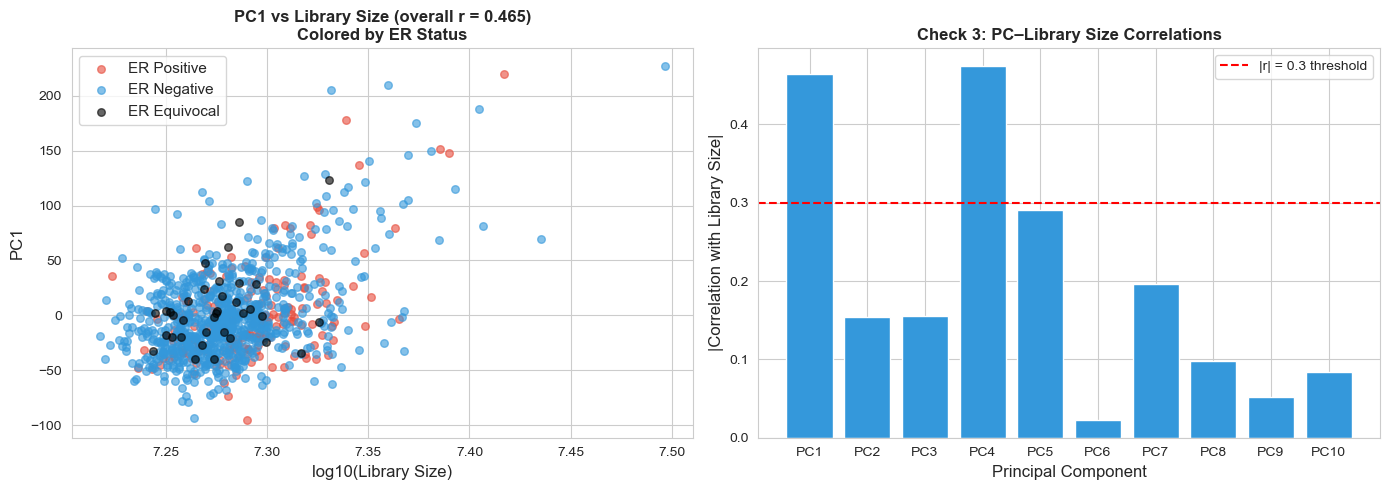


PC correlations with log(library size):
  PC         r            p      |r|  var_explained
 PC1  0.464888 1.064420e-59 0.464888       9.378174
 PC2  0.154447 2.881042e-07 0.154447       6.102525
 PC3  0.155261 2.490207e-07 0.155261       5.279834
 PC4 -0.474064 2.512828e-62 0.474064       2.431573
 PC5 -0.290355 1.123443e-22 0.290355       2.061501
 PC6 -0.022715 4.531354e-01 0.022715       1.742094
 PC7  0.195931 6.421410e-11 0.195931       1.471934
 PC8 -0.098432 1.120333e-03 0.098432       1.346803
 PC9  0.051655 8.783668e-02 0.051655       1.117865
PC10 -0.083253 5.887006e-03 0.083253       1.039400

⚠ 2 PC(s) have |r| > 0.3 with library size:
 PC         r            p      |r|  var_explained
PC1  0.464888 1.064420e-59 0.464888       9.378174
PC4 -0.474064 2.512828e-62 0.474064       2.431573


array([[ 227.31123392,   13.62964695,   71.83477796, ...,  -54.92005394,
          16.95294542, -111.95752038],
       [  69.29276097,   17.54680933,   74.15573133, ...,  -41.80610737,
          12.4751295 ,  -36.12218306],
       [ 219.4980927 ,  -27.73509201,  -83.89307011, ...,   21.96357141,
         132.27405932,  -41.20890104],
       ...,
       [ -21.52179321,  -47.66006359,  -29.70118594, ...,   23.8734951 ,
          -3.28417801,   -3.46546621],
       [ -18.81702813,   28.85422375,  -40.1009283 , ...,  -45.70028885,
          19.18385287,   16.74919054],
       [ -13.25872484,   -5.97856519,  -37.43668526, ...,   -4.98708622,
           8.56181265,   14.64658439]], shape=(1093, 10))

In [87]:
pca_libsize_analysis(tumor_norm_deseq_style, log_transform=False, color_by = 'her2_composite', 
                     metadata_cols = ['patient_id', 'bcr_patient_barcode', 'sample_type','library_size','ER Status By IHC', 'her2_composite'])

### **FIG X: PCA–Library Size Analysis After Upper-Quartile Normalization.**
SIMILAR STORY BUT WITH ANOTHER NORMALIZATION SCHEME. 

### 2.8 Post-Normalization Normality Check

After log2(x+1) transformation, we check whether gene expression distributions are 
approximately normal, which is assumed by PCA and many linear models.


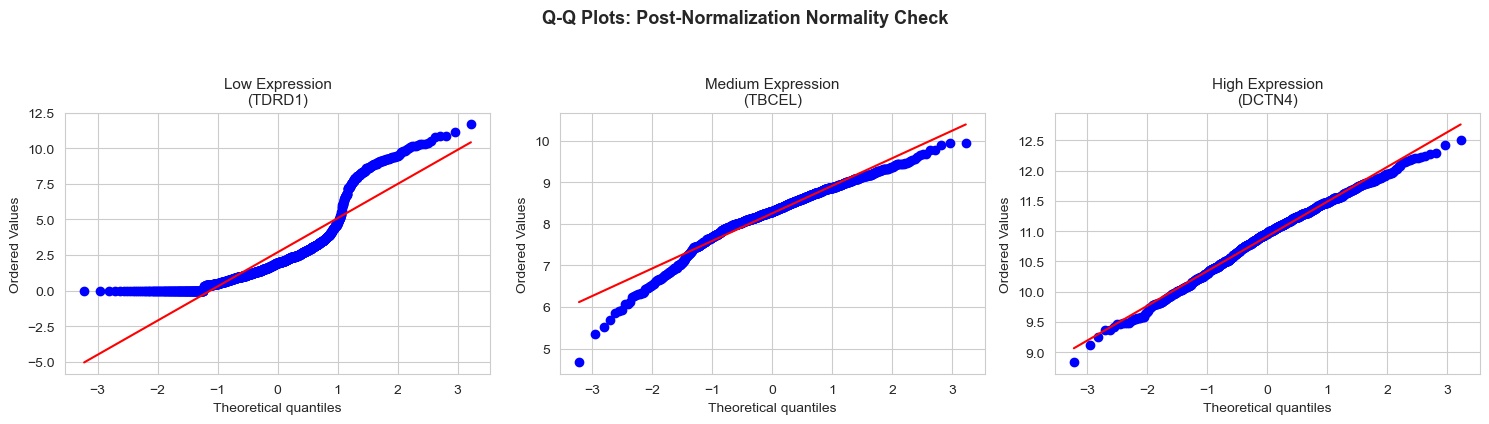

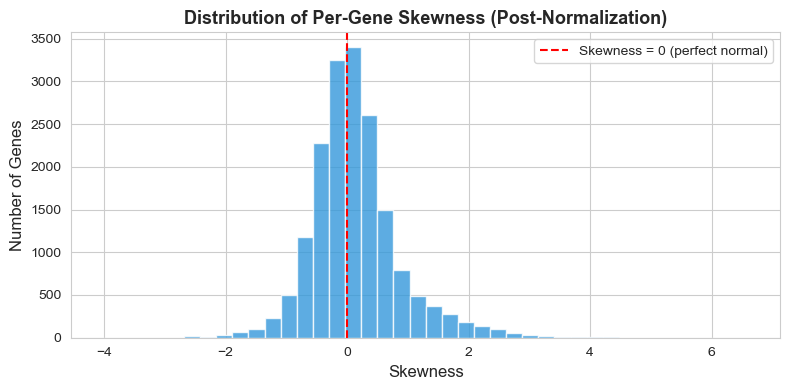

Per-gene skewness: mean = 0.133, median = 0.054
  Genes with |skewness| < 1: 15303 / 17637
  Genes with |skewness| < 0.5: 11132 / 17637


In [88]:
# Q-Q plots for representative genes (low, medium, high expression)
gene_medians = tumor_norm.median(axis=0).sort_values()
n_genes = len(gene_medians)

if n_genes >= 3:
    low_gene = gene_medians.index[max(0, n_genes // 10)]
    mid_gene = gene_medians.index[n_genes // 2]
    high_gene = gene_medians.index[min(n_genes - 1, 9 * n_genes // 10)]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, gene, label in zip(axes, [low_gene, mid_gene, high_gene], 
                                ['Low Expression', 'Medium Expression', 'High Expression']):
        data = tumor_norm[gene].dropna()
        stats.probplot(data, dist='norm', plot=ax)
        ax.set_title(f'{label}\n({gene})', fontsize=11)
    
    plt.suptitle('Q-Q Plots: Post-Normalization Normality Check', fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# Distribution of per-gene skewness
gene_skewness = tumor_norm.apply(lambda x: x.dropna().skew(), axis=0)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(gene_skewness.dropna(), bins=40, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(x=0, color='red', linestyle='--', label='Skewness = 0 (perfect normal)')
ax.set_xlabel('Skewness', fontsize=12)
ax.set_ylabel('Number of Genes', fontsize=12)
ax.set_title('Distribution of Per-Gene Skewness (Post-Normalization)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Per-gene skewness: mean = {gene_skewness.mean():.3f}, median = {gene_skewness.median():.3f}")
print(f"  Genes with |skewness| < 1: {(gene_skewness.abs() < 1).sum()} / {len(gene_skewness)}")
print(f"  Genes with |skewness| < 0.5: {(gene_skewness.abs() < 0.5).sum()} / {len(gene_skewness)}")


### 2.9 Batch Effect Assessment: PCA-Correlation Heatmap

For each top PC, we compute associations with every available clinical and technical variable. 
This is a comprehensive, assumption-light approach to batch detection.


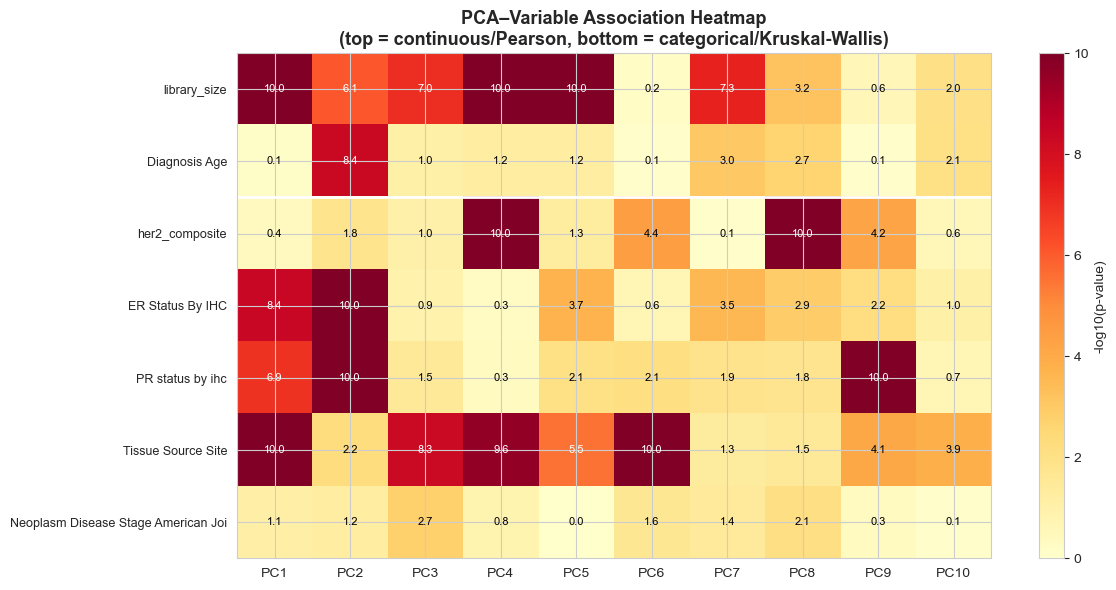

Significance threshold: -log10(0.05) = 1.3
Values > 1.3 indicate significant association (p < 0.05)

Interpretation:
  PCs dominated by biological variables (HER2, ER, PR) → signal (good)
  PCs dominated by technical variables (library size) → batch effect (concerning)
  PCs correlated with nothing known → possible unmeasured batch effect


In [89]:
# Merge PCs with clinical data
pc_df = pd.DataFrame(pcs, columns=[f'PC{i+1}' for i in range(pcs.shape[1])],
                     index=tumor_filtered.index)
pc_df['patient_id'] = tumor_filtered['patient_id'].values
pc_df['library_size'] = tumor_filtered['library_size'].values

pc_clinical = pc_df.merge(
    clinical[['Patient ID', 'her2_composite', 'ER Status By IHC', 'PR status by ihc',
              'dx_year', 'Diagnosis Age', 'Tissue Source Site',
              'Neoplasm Disease Stage American Joint Committee on Cancer Code']],
    left_on='patient_id', right_on='Patient ID', how='left'
)

# Variables to test
continuous_vars = ['library_size', 'Diagnosis Age']
categorical_vars = ['her2_composite', 'ER Status By IHC', 'PR status by ihc',
                    'Tissue Source Site', 
                    'Neoplasm Disease Stage American Joint Committee on Cancer Code']

# Compute association p-values
pc_names = [f'PC{i+1}' for i in range(pcs.shape[1])]
results = {}

for var in continuous_vars:
    if var in pc_clinical.columns:
        pvals = []
        for pc in pc_names:
            valid_mask = pc_clinical[var].notna() & pc_clinical[pc].notna()
            if valid_mask.sum() > 5:
                vals = pd.to_numeric(pc_clinical.loc[valid_mask, var], errors='coerce')
                valid_mask2 = vals.notna()
                if valid_mask2.sum() > 5:
                    r, p = stats.pearsonr(vals[valid_mask2], 
                                         pc_clinical.loc[valid_mask, pc][valid_mask2])
                    pvals.append(p)
                else:
                    pvals.append(1.0)
            else:
                pvals.append(1.0)
        results[var] = pvals

for var in categorical_vars:
    if var in pc_clinical.columns:
        pvals = []
        for pc in pc_names:
            valid_mask = pc_clinical[var].notna()
            groups_data = [g[pc].values for _, g in pc_clinical[valid_mask].groupby(var) 
                          if len(g) > 1]
            if len(groups_data) >= 2:
                try:
                    h, p = stats.kruskal(*groups_data)
                    pvals.append(p)
                except:
                    pvals.append(1.0)
            else:
                pvals.append(1.0)
        results[var] = pvals

# Build heatmap matrix
if results:
    heatmap_data = pd.DataFrame(results, index=pc_names).T
    # -log10(p), capped at 10 for visualization
    heatmap_log = -np.log10(heatmap_data.clip(lower=1e-10))
    heatmap_log = heatmap_log.clip(upper=10)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(heatmap_log.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=10)
    ax.set_xticks(range(len(pc_names)))
    ax.set_xticklabels(pc_names, fontsize=10)
    # Shorten variable names for display
    short_names = [v[:35] for v in heatmap_log.index]
    ax.set_yticks(range(len(short_names)))
    ax.set_yticklabels(short_names, fontsize=9)
    
    # Add text annotations
    for i in range(heatmap_log.shape[0]):
        for j in range(heatmap_log.shape[1]):
            val = heatmap_log.values[i, j]
            color = 'white' if val > 5 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8, color=color)
    
    plt.colorbar(im, label='-log10(p-value)', ax=ax)
    ax.axhline(y=len(continuous_vars) - 0.5, color='white', linewidth=2)
    ax.set_title('PCA–Variable Association Heatmap\n(top = continuous/Pearson, bottom = categorical/Kruskal-Wallis)',
                 fontsize=13, fontweight='bold')
    
    # Significance line
    sig_line = -np.log10(0.05)  # ~1.3
    
    plt.tight_layout()
    plt.show()
    
    print("Significance threshold: -log10(0.05) = 1.3")
    print("Values > 1.3 indicate significant association (p < 0.05)")
    print("\nInterpretation:")
    print("  PCs dominated by biological variables (HER2, ER, PR) → signal (good)")
    print("  PCs dominated by technical variables (library size) → batch effect (concerning)")
    print("  PCs correlated with nothing known → possible unmeasured batch effect")
else:
    print("Insufficient data for PCA-correlation heatmap.")


asdf
*Figure B. PCA–Variable Association Heatmap.
Heatmap of −log10(p-values) for associations between the top 10 PCs and clinical/technical variables. Continuous variables (library size, diagnosis age) are assessed by Pearson correlation; categorical variables (HER2, ER, PR, tissue source site, AJCC stage) by Kruskal-Wallis test. Values above 1.3 correspond to p < 0.05. PC1 is dominated by ER/PR status (−log10(p) = 10 for both) and PC4 by HER2 status (−log10(p) = 10), confirming that the major axes of transcriptomic variation reflect known breast cancer biology. Library size associates with the same PCs (PC1 and PC4), consistent with biological composition driving apparent depth differences rather than an independent technical batch effect. Tissue source site shows significant associations across multiple PCs (PC1, PC3, PC5, PC6, PC10), reflecting the expected entanglement of sequencing center with both patient population and technical batch in TCGA data. AJCC stage shows minimal association with any PC, suggesting that staging does not drive major transcriptomic structure in this cohort.*

### Quickly test hypothesis whether a few genes are driving

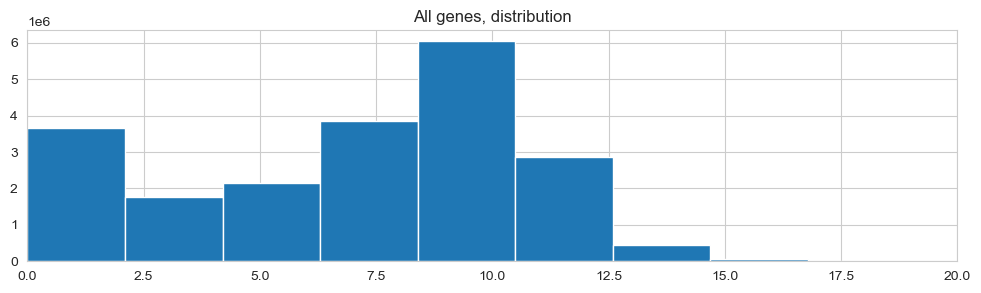

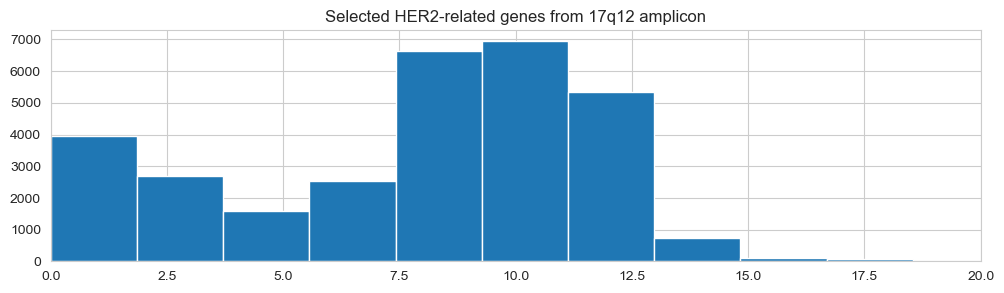

In [52]:
# Remove HER2 and related genes from consideration to see if library effects persist. 
genes_17q12 = ["ERBB2", "GRB7", "PPP1R1B", "STARD3", "TCAP", "PNMT", 
               "TOP2A", "PGAP3",  "STARD3", "CASC3", "CDC6", "RARA", "SMARCE1",] #  "PERLD1", "MIEN1", "ZNF1A3"
tumor_censored = tumor_filtered.loc[:,tumor_filtered.columns.str.contains("|".join(genes_17q12))==False].copy()

plt.figure(figsize = (12,3))
plt.hist(tumor_norm.values.flatten())
plt.xlim(0, 20)
plt.title("All genes, distribution")
plt.show()
plt.figure(figsize = (12,3))
plt.hist(tumor_norm.loc[:,tumor_norm.columns.str.contains("|".join(genes_17q12))==True].values.flatten(),)
plt.xlim(0, 20)
plt.title("Selected HER2-related genes from 17q12 amplicon")
plt.show()



Figure X: Expression distribution of 17q12 amplicon genes relative to the full transcriptome. (Top) Distribution of normalized expression values (log2(count + 1)) across all genes and samples. (Bottom) Distribution for selected HER2-related genes from the 17q12 amplicon (ERBB2, GRB7, PPP1R1B, STARD3, TCAP, PNMT, TOP2A, PGAP3, CASC3, CDC6, RARA, SMARCE1). The amplicon genes span a similar expression range as the full transcriptome and do not exhibit a distinctly skewed distribution, indicating that their contribution to per-sample library size totals is not disproportionate relative to the ~15,000 other expressed genes.

  Within label =  Positive: r = 0.528, p = 1.2e-13, n = 171
  Within label =  Negative: r = 0.473, p = 2.6e-44, n = 773


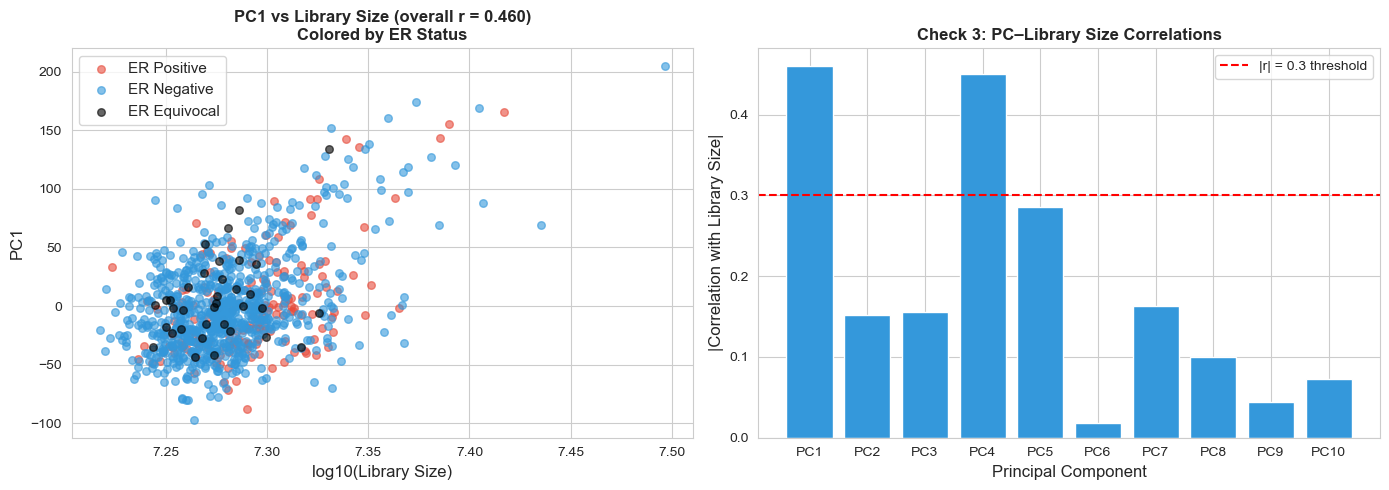


PC correlations with log(library size):
  PC         r            p      |r|  var_explained
 PC1  0.459600 3.198828e-58 0.459600       8.811780
 PC2  0.151938 4.494268e-07 0.151938       5.848071
 PC3  0.156173 2.112939e-07 0.156173       4.093771
 PC4 -0.449862 1.442811e-55 0.449862       2.430185
 PC5 -0.285392 6.252967e-22 0.285392       1.969000
 PC6 -0.018573 5.396171e-01 0.018573       1.720627
 PC7 -0.162989 6.006311e-08 0.162989       1.327105
 PC8  0.099240 1.018792e-03 0.099240       1.230746
 PC9  0.044576 1.408166e-01 0.044576       1.060217
PC10  0.072046 1.720722e-02 0.072046       0.921609

⚠ 2 PC(s) have |r| > 0.3 with library size:
 PC         r            p      |r|  var_explained
PC1  0.459600 3.198828e-58 0.459600       8.811780
PC4 -0.449862 1.442811e-55 0.449862       2.430185


In [54]:
pcs_censored = pca_libsize_analysis(tumor_censored, log_transform=False, color_by = 'her2_composite', 
                     metadata_cols = ['patient_id', 'bcr_patient_barcode', 'sample_type','library_size','ER Status By IHC', 'her2_composite'])

Figure Y: Removal of 17q12 amplicon genes does not attenuate the PC1–library size correlation. (Left) PC1 versus log10(library size) after excluding 13 HER2-related genes from the 17q12 amplicon prior to PCA. The correlation (r = −0.445, p = 3.1 × 10⁻⁵⁴) is unchanged from the full-gene analysis, confirming that the depth association is distributed across thousands of genes rather than driven by the amplicon. (Right) Absolute Pearson correlation between library size and each of the top 10 PCs; the pattern is identical to the full-transcriptome PCA. Together with the within-subtype analysis (Figure Z), these results indicate that the residual library size effect is a global technical artifact not attributable to HER2 amplicon biology or ER-subtype composition.

# Part 3: Integration and Cohort Construction

### 3.1 Patient ID Harmonization (Barcode Matching)

TCGA datasets use different identifier formats. We truncate all IDs to the 12-character 
patient ID for merging.


In [55]:
print("=" * 70)
print("PATIENT ID HARMONIZATION")
print("=" * 70)

# Inspect ID formats
print("\nID format examples:")
print(f"  Clinical 'Patient ID': {clinical['Patient ID'].iloc[0]}")
print(f"  RNA-Seq 'patient_id':  {tumor_filtered['patient_id'].iloc[0]}")
print(f"  RNA-Seq 'barcode':     {rsem['bcr_patient_barcode'].iloc[0]}")
print(f"  Copy Number 'patient_id': {cn['patient_id'].iloc[0]}")
print(f"  Copy Number 'sample_id':  {cn['sample_id'].iloc[0]}")

# Truncate all to 12-character patient ID
def to_patient_id(id_str):
    """Extract 12-character TCGA patient ID from any barcode format."""
    if pd.isna(id_str):
        return np.nan
    s = str(id_str).strip()
    # TCGA patient IDs are always 12 chars: TCGA-XX-XXXX
    if len(s) >= 12 and s.startswith('TCGA'):
        return s[:12]
    return s

clinical['pid'] = clinical['Patient ID'].apply(to_patient_id)
tumor_filtered['pid'] = tumor_filtered['patient_id'].apply(to_patient_id)
cn['pid'] = cn['patient_id'].apply(to_patient_id)

# Also add pid to tumor_norm (same index as tumor_filtered)
tumor_norm_df = tumor_norm.copy()
tumor_norm_df['pid'] = tumor_filtered['pid'].values

print(f"\nUnique patient IDs:")
print(f"  Clinical:    {clinical['pid'].nunique()}")
print(f"  RNA-Seq:     {tumor_filtered['pid'].nunique()}")
print(f"  Copy Number: {cn['pid'].nunique()}")

# Check for collisions in RNA-Seq (multiple samples per patient after tumor filtering)
rna_dup = tumor_filtered['pid'].value_counts()
rna_dups = rna_dup[rna_dup > 1]
if len(rna_dups) > 0:
    print(f"\n⚠ {len(rna_dups)} patients have multiple tumor samples after filtering. Deduplicating...")
    tumor_filtered['_total'] = tumor_filtered[gene_cols_filtered].sum(axis=1)
    tumor_filtered = tumor_filtered.sort_values('_total', ascending=False).drop_duplicates('pid', keep='first')
    tumor_filtered = tumor_filtered.drop('_total', axis=1)
    tumor_norm_df = tumor_norm_df.loc[tumor_filtered.index]
    print(f"  After deduplication: {len(tumor_filtered)} samples")
else:
    print("\n✓ No patient ID collisions in RNA-Seq data.")


PATIENT ID HARMONIZATION

ID format examples:
  Clinical 'Patient ID': TCGA-3C-AAAU
  RNA-Seq 'patient_id':  TCGA-AC-A2QJ
  RNA-Seq 'barcode':     TCGA-3C-AAAU-01A-11R-A41B-07
  Copy Number 'patient_id': TCGA-AR-A1AR
  Copy Number 'sample_id':  TCGA-AR-A1AR-01

Unique patient IDs:
  Clinical:    1101
  RNA-Seq:     1093
  Copy Number: 963

✓ No patient ID collisions in RNA-Seq data.


### 3.2 Copy Number QC

Validate ERBB2 GISTIC values before integration.


ERBB2 COPY NUMBER QC

GISTIC Value Distribution:
----------------------------------------
  -2:    1 (  0.1%) — expected in BRCA: ~1-2%
  -1:  237 ( 24.6%) — expected in BRCA: ~5-10%
  +0:  418 ( 43.4%) — expected in BRCA: ~60-70%
  +1:  188 ( 19.5%) — expected in BRCA: ~10-15%
  +2:  119 ( 12.4%) — expected in BRCA: ~15-20%

✓ All values are in expected range {-2, -1, 0, 1, 2}
Missing values: 0


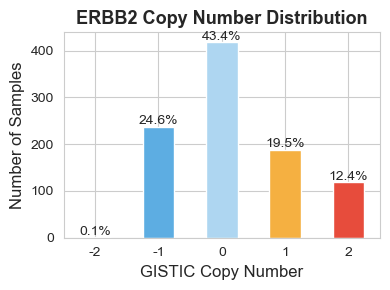


Cross-check: CN vs Clinical HER2 (868 patients)
her2_composite     Equivocal  Negative  Positive
erbb2_copy_number                               
-2                         0         0         1
-1                         2       199        16
 0                        12       338        20
 1                         8       139        23
 2                         6        13        91

  HER2-Positive with CN ≥ 1 (gain/amp): 114/151 (75%)
  → Expected: majority should show gain or amplification.


In [56]:
print("=" * 70)
print("ERBB2 COPY NUMBER QC")
print("=" * 70)

# Value distribution
cn_vals = cn['erbb2_copy_number']
print("\nGISTIC Value Distribution:")
print("-" * 40)
val_counts = cn_vals.value_counts().sort_index()
for val, count in val_counts.items():
    pct = 100 * count / len(cn)
    expected = {-2: '~1-2%', -1: '~5-10%', 0: '~60-70%', 1: '~10-15%', 2: '~15-20%'}
    exp_str = expected.get(val, '?')
    print(f"  {val:+d}: {count:4d} ({pct:5.1f}%) — expected in BRCA: {exp_str}")

# Check for unexpected values
valid_values = {-2, -1, 0, 1, 2}
unexpected = cn_vals[~cn_vals.isin(valid_values)]
if len(unexpected) > 0:
    print(f"\n⚠ {len(unexpected)} unexpected values: {unexpected.unique()}")
else:
    print(f"\n✓ All values are in expected range {{-2, -1, 0, 1, 2}}")

# Missing data
n_missing_cn = cn_vals.isna().sum()
print(f"Missing values: {n_missing_cn}")

# Visualize
fig, ax = plt.subplots(figsize=(4, 3))
val_counts.plot(kind='bar', color=['#3498db', '#5dade2', '#aed6f1', '#f5b041', '#e74c3c'],
                edgecolor='white', ax=ax)
ax.set_xlabel('GISTIC Copy Number', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('ERBB2 Copy Number Distribution', fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, (val, count) in enumerate(val_counts.items()):
    ax.text(i, count + 5, f'{100*count/len(cn):.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Cross-check CN vs clinical HER2 status
cn_clinical = cn.merge(clinical[['pid', 'her2_composite']], on='pid', how='inner')
cn_labeled = cn_clinical.dropna(subset=['her2_composite'])

if len(cn_labeled) > 0:
    print(f"\nCross-check: CN vs Clinical HER2 ({len(cn_labeled)} patients)")
    ct_cn_her2 = pd.crosstab(cn_labeled['erbb2_copy_number'], cn_labeled['her2_composite'])
    print(ct_cn_her2)
    
    # Among HER2-Positive, what fraction have CN >= 1?
    if 'Positive' in ct_cn_her2.columns:
        pos_total = ct_cn_her2['Positive'].sum()
        pos_amp = ct_cn_her2.loc[ct_cn_her2.index >= 1, 'Positive'].sum()
        print(f"\n  HER2-Positive with CN ≥ 1 (gain/amp): {pos_amp}/{pos_total} ({100*pos_amp/max(pos_total,1):.0f}%)")
        print("  → Expected: majority should show gain or amplification.")


*Figure X. ERBB2 GISTIC Copy Number Distribution and Concordance with Clinical HER2 Status in the TCGA BRCA Cohort (n=963).
(A) Distribution of ERBB2 discrete copy number calls across the cohort. The diploid-neutral category (CN=0) comprises 43.4% of samples, which is modestly lower than the ~60–70% typically reported in TCGA BRCA, while heterozygous loss (CN=−1, 24.6%) is elevated relative to the expected ~5–10%. These deviations likely reflect GISTIC threshold sensitivity rather than a biological anomaly, though they warrant consideration when interpreting CN-based HER2 classification. Deep deletion (CN=−2) is rare (0.1%), consistent with the absence of selective pressure for biallelic ERBB2 loss in breast cancer.
(B) Cross-tabulation of ERBB2 copy number against composite clinical HER2 status (n=868 patients with both annotations). Among clinically HER2-Positive patients, 75% (114/151) harbor copy number gain or amplification (CN ≥ 1), confirming expected concordance between gene amplification and protein overexpression. However, 25% of HER2-Positive patients show neutral or negative copy number (CN ≤ 0), suggesting that transcriptional or post-transcriptional mechanisms, tumor heterogeneity, or assay discordance may drive HER2 overexpression independent of amplification in a meaningful minority. Conversely, 13 patients with high-level amplification (CN=+2) are clinically HER2-Negative, representing potential false negatives by IHC or cases where amplification does not translate to sufficient protein expression. These discordant cases motivate the multimodal integration of RNA, DNA, and clinical data to refine HER2 patient identification.*

### 3.3 Merging Datasets

In [57]:
print("=" * 70)
print("SEQUENTIAL DATASET MERGE")
print("=" * 70)

# Step 1: Clinical alone
print(f"\n1. Clinical data: {clinical['pid'].nunique()} unique patients")

# Step 2: Clinical ∩ RNA-Seq
clin_rna = clinical.merge(
    tumor_norm_df.assign(pid=tumor_filtered['pid'].values),
    on='pid', how='inner'
)
print(f"2. Clinical ∩ RNA-Seq: {len(clin_rna)} patients")

# Step 3: Clinical ∩ RNA-Seq ∩ Copy Number
clin_rna_cn = clin_rna.merge(
    cn[['pid', 'erbb2_copy_number']],
    on='pid', how='inner'
)
print(f"3. Clinical ∩ RNA-Seq ∩ CN: {len(clin_rna_cn)} patients (multimodal cohort)")

# Patients lost at each step
rna_pids = set(tumor_filtered['pid'])
cn_pids = set(cn['pid'])
clin_pids = set(clinical['pid'])

print(f"\nOverlap analysis:")
print(f"  In clinical but not RNA-Seq: {len(clin_pids - rna_pids)}")
print(f"  In clinical but not CN:      {len(clin_pids - cn_pids)}")
print(f"  In RNA-Seq but not clinical:  {len(rna_pids - clin_pids)}")
print(f"  In all three:                 {len(clin_pids & rna_pids & cn_pids)}")


SEQUENTIAL DATASET MERGE

1. Clinical data: 1101 unique patients
2. Clinical ∩ RNA-Seq: 1100 patients
3. Clinical ∩ RNA-Seq ∩ CN: 966 patients (multimodal cohort)

Overlap analysis:
  In clinical but not RNA-Seq: 8
  In clinical but not CN:      138
  In RNA-Seq but not clinical:  0
  In all three:                 960


### 3.4 Final Cohort Definitions and Validation Summary

In [58]:
print("=" * 70)
print("FINAL COHORT DEFINITIONS")
print("=" * 70)

# Cohort A: labeled (Positive/Negative) within the multimodal set
cohort_c = clin_rna_cn.copy()
cohort_a_multi = cohort_c[cohort_c['her2_composite'].isin(['Positive', 'Negative'])]

print(f"\nCohort A (labeled, multimodal): {len(cohort_a_multi)} patients")
if len(cohort_a_multi) > 0:
    pos_n = (cohort_a_multi['her2_composite'] == 'Positive').sum()
    neg_n = (cohort_a_multi['her2_composite'] == 'Negative').sum()
    print(f"  Positive: {pos_n}")
    print(f"  Negative: {neg_n}")
    print(f"  Class ratio (Neg:Pos): {neg_n/max(pos_n,1):.1f}:1")

print(f"\nCohort B (full clinical): {len(clinical)} patients")

print(f"\nCohort C (multimodal, all labels): {len(cohort_c)} patients")
print(f"  With HER2 label:   {cohort_c['her2_composite'].notna().sum()}")
print(f"  Without HER2 label: {cohort_c['her2_composite'].isna().sum()}")

equivocal_multi = cohort_c[cohort_c['her2_composite'] == 'Equivocal']
print(f"  Equivocal:          {len(equivocal_multi)}")

print(f"\nGenes after filtering: {len(gene_cols_filtered)}")
print(f"Adjacent Normal samples (held for deep dive): {len(normal)}")

print("\n" + "=" * 70)
print("QC COMPLETE — Ready for analysis")
print("=" * 70)
print("\nCaveats to carry forward:")
print("  1. Check temporal bias in HER2 labels (guideline drift)")
print("  2. Note class imbalance in supervised learning")  
print("  3. Equivocal cases excluded from primary classification; retained for unsupervised")
print("  4. Adjacent normal tissue (n=7) held for deep-dive comparison")


FINAL COHORT DEFINITIONS

Cohort A (labeled, multimodal): 837 patients
  Positive: 151
  Negative: 686
  Class ratio (Neg:Pos): 4.5:1

Cohort B (full clinical): 1108 patients

Cohort C (multimodal, all labels): 966 patients
  With HER2 label:   865
  Without HER2 label: 101
  Equivocal:          28

Genes after filtering: 19049
Adjacent Normal samples (held for deep dive): 112

QC COMPLETE — Ready for analysis

Caveats to carry forward:
  1. Check temporal bias in HER2 labels (guideline drift)
  2. Note class imbalance in supervised learning
  3. Equivocal cases excluded from primary classification; retained for unsupervised
  4. Adjacent normal tissue (n=7) held for deep-dive comparison


---
# **Section 2: Identify HER2+ Patients**

## 2.1 Clinical Definition (IHC/FISH)

The composite clinical HER2 label was already constructed in Part 1 using ASCO/CAP logic. 
Here we summarize the clinical definition and visualize the labeled cohort.


In [59]:
# Recap the clinical HER2 definition from QC
print("=" * 70)
print("CLINICAL HER2 DEFINITION (from QC)")
print("=" * 70)

# Reconstruct key variables — rerun essentials since notebook state continues
print(f"\nLabeled patients in multimodal cohort: {len(cohort_a_multi)}")
print(f"  Positive: {(cohort_a_multi['her2_composite'] == 'Positive').sum()}")
print(f"  Negative: {(cohort_a_multi['her2_composite'] == 'Negative').sum()}")

# Detailed IHC score breakdown
if 'HER2 ihc score' in cohort_c.columns:
    print("\nHER2 IHC Score distribution in multimodal cohort:")
    print(cohort_c['HER2 ihc score'].value_counts(dropna=False).to_string())


CLINICAL HER2 DEFINITION (from QC)

Labeled patients in multimodal cohort: 837
  Positive: 151
  Negative: 686

HER2 IHC Score distribution in multimodal cohort:
HER2 ihc score
NaN    410
1.0    242
2.0    176
3.0     78
0.0     60


## 2.2 Multimodal Definition: ERBB2 RNA vs Copy Number

We plot ERBB2 RNA expression against copy number, colored by clinical HER2 status, to 
visualize concordance and identify discordant cases.


In [60]:
# Check which key genes are available in the abridged dataset
key_genes = ['ERBB2', 'GRB7', 'ESR1', 'PGR', 'MKI67']
available_genes = [g for g in key_genes if g in gene_cols_filtered]
missing_genes = [g for g in key_genes if g not in gene_cols_filtered]

print("Key genes for HER2 analysis:")
print(f"  Available: {available_genes}")
if missing_genes:
    print(f"  Missing (not in abridged dataset): {missing_genes}")
    print("  → These will be available with the full ~20K gene dataset.")

# Build analysis dataframe from the multimodal cohort
analysis_df = cohort_c.copy()

# Add normalized ERBB2 expression if available
if 'ERBB2' in gene_cols_filtered:
    # Get ERBB2 expression from normalized data
    erbb2_expr = tumor_norm_df[['pid', 'ERBB2']].rename(columns={'ERBB2': 'ERBB2_expr'})
    analysis_df = analysis_df.merge(erbb2_expr, on='pid', how='left')
    print(f"\nERBB2 expression range: [{analysis_df['ERBB2_expr'].min():.2f}, {analysis_df['ERBB2_expr'].max():.2f}]")
else:
    print("\n⚠ ERBB2 not in abridged gene set. Using available genes for demonstration.")
    # Use first available gene as proxy for demonstration
    if available_genes:
        proxy = available_genes[0]
        proxy_expr = tumor_norm_df[['pid', proxy]].rename(columns={proxy: 'ERBB2_expr'})
        analysis_df = analysis_df.merge(proxy_expr, on='pid', how='left')
        print(f"  Using {proxy} as proxy. Actual ERBB2 analysis requires full dataset.")

# Add other available key genes
for gene in available_genes:
    if gene != 'ERBB2' and gene in tumor_norm_df.columns:
        gene_expr = tumor_norm_df[['pid', gene]]
        analysis_df = analysis_df.merge(gene_expr, on='pid', how='left')


Key genes for HER2 analysis:
  Available: ['ERBB2', 'GRB7', 'ESR1', 'PGR', 'MKI67']

ERBB2 expression range: [7.28, 18.37]


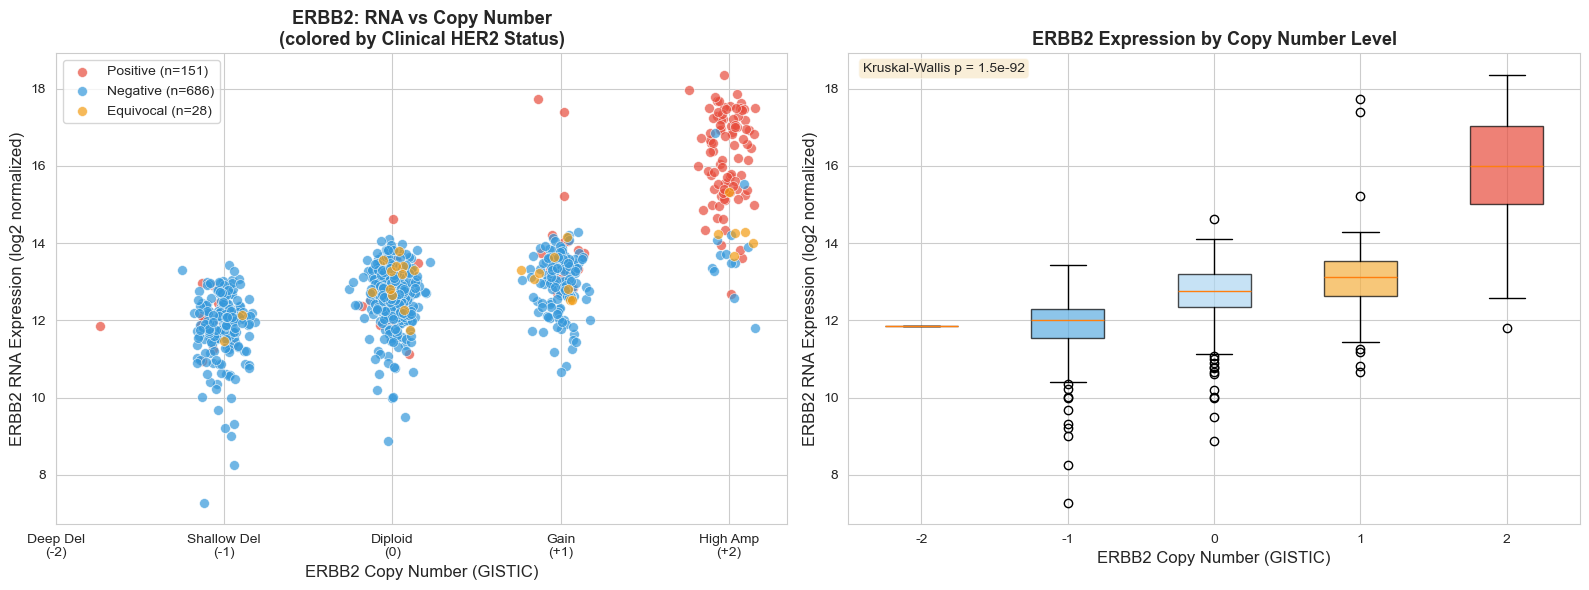


Discordant Case Analysis:
--------------------------------------------------
  High RNA (>Q75) + Low CN (≤0): 51 patients
  Low RNA (<Q25) + High CN (≥2): 1 patients

  High RNA / Low CN patients (possible transcriptional upregulation):
         pid  ERBB2_expr  erbb2_copy_number her2_composite
TCGA-A1-A0SD   13.663423                  0       Negative
TCGA-A2-A0CO   13.398643                  0       Negative
TCGA-A2-A0EO   13.614941                  0       Negative
TCGA-A2-A0EX   13.768928                  0       Negative
TCGA-A2-A0T6   13.578831                  0       Negative
TCGA-A2-A3KC   13.854708                  0       Negative
TCGA-A7-A13H   13.583064                  0       Negative
TCGA-A7-A3J1   13.556414                  0       Negative
TCGA-A7-A5ZX   13.754133                  0       Negative
TCGA-A8-A06T   13.514522                  0       Positive


In [61]:
# ERBB2 RNA vs Copy Number scatter, colored by clinical HER2 status
if 'ERBB2_expr' in analysis_df.columns and 'erbb2_copy_number' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Left: colored by composite HER2 status
    labeled = analysis_df.dropna(subset=['her2_composite', 'ERBB2_expr', 'erbb2_copy_number'])
    color_map = {'Positive': '#e74c3c', 'Negative': '#3498db', 'Equivocal': '#f39c12', 
                 'Indeterminate': '#95a5a6'}
    
    for status, color in color_map.items():
        mask = labeled['her2_composite'] == status
        if mask.sum() > 0:
            axes[0].scatter(
                labeled.loc[mask, 'erbb2_copy_number'] + np.random.normal(0, 0.08, mask.sum()),
                labeled.loc[mask, 'ERBB2_expr'],
                c=color, label=f'{status} (n={mask.sum()})',
                alpha=0.7, s=50, edgecolors='white', linewidth=0.5
            )
    
    axes[0].set_xlabel('ERBB2 Copy Number (GISTIC)', fontsize=12)
    axes[0].set_ylabel('ERBB2 RNA Expression (log2 normalized)', fontsize=12)
    axes[0].set_title('ERBB2: RNA vs Copy Number\n(colored by Clinical HER2 Status)', 
                       fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].set_xticks([-2, -1, 0, 1, 2])
    axes[0].set_xticklabels(['Deep Del\n(-2)', 'Shallow Del\n(-1)', 'Diploid\n(0)', 
                             'Gain\n(+1)', 'High Amp\n(+2)'])
    
    # Right: boxplot of ERBB2 expression by CN level
    cn_groups = labeled.groupby('erbb2_copy_number')['ERBB2_expr']
    box_data = [group.values for _, group in cn_groups]
    box_labels = [str(int(name)) for name, _ in cn_groups]
    
    bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True)
    colors_box = ['#3498db', '#5dade2', '#aed6f1', '#f5b041', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors_box[:len(bp['boxes'])]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    axes[1].set_xlabel('ERBB2 Copy Number (GISTIC)', fontsize=12)
    axes[1].set_ylabel('ERBB2 RNA Expression (log2 normalized)', fontsize=12)
    axes[1].set_title('ERBB2 Expression by Copy Number Level', fontsize=13, fontweight='bold')
    
    # Kruskal-Wallis
    if len(box_data) > 1:
        h_stat, p_val = stats.kruskal(*[d for d in box_data if len(d) > 0])
        axes[1].text(0.02, 0.98, f'Kruskal-Wallis p = {p_val:.2g}', transform=axes[1].transAxes,
                     fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Identify discordant cases
    print("\nDiscordant Case Analysis:")
    print("-" * 50)
    
    # High RNA but low CN (possible post-transcriptional upregulation)
    if 'ERBB2_expr' in labeled.columns:
        expr_q75 = labeled['ERBB2_expr'].quantile(0.75)
        expr_q25 = labeled['ERBB2_expr'].quantile(0.25)
        
        high_rna_low_cn = labeled[(labeled['ERBB2_expr'] > expr_q75) & (labeled['erbb2_copy_number'] <= 0)]
        low_rna_high_cn = labeled[(labeled['ERBB2_expr'] < expr_q25) & (labeled['erbb2_copy_number'] >= 2)]
        
        print(f"  High RNA (>Q75) + Low CN (≤0): {len(high_rna_low_cn)} patients")
        print(f"  Low RNA (<Q25) + High CN (≥2): {len(low_rna_high_cn)} patients")
        
        if len(high_rna_low_cn) > 0:
            print("\n  High RNA / Low CN patients (possible transcriptional upregulation):")
            cols_show = ['pid', 'ERBB2_expr', 'erbb2_copy_number', 'her2_composite']
            cols_available = [c for c in cols_show if c in high_rna_low_cn.columns]
            print(high_rna_low_cn[cols_available].head(10).to_string(index=False))
else:
    print("Cannot perform RNA vs CN analysis — ERBB2 expression or CN data missing.")


Figure X. ERBB2 RNA expression correlates with copy number but identifies discordant cases. (Left) ERBB2 RNA expression (log2 upper-quartile normalized) vs. GISTIC copy number, colored by clinical HER2 status (IHC/FISH composite). Points are jittered horizontally for visibility. RNA and CN are broadly concordant, with HER2-Positive patients (red) concentrated at high amplification and high expression. However, 51 patients exhibit high RNA expression (>Q75) despite low copy number (≤0), most of whom are clinically HER2-Negative — suggesting transcriptional upregulation independent of genomic amplification. (Right) Boxplot confirms a significant stepwise relationship between copy number and RNA expression (Kruskal-Wallis p = 1.5×10⁻⁹²). n = 865 patients with matched RNA, copy number, and clinical HER2 annotations.

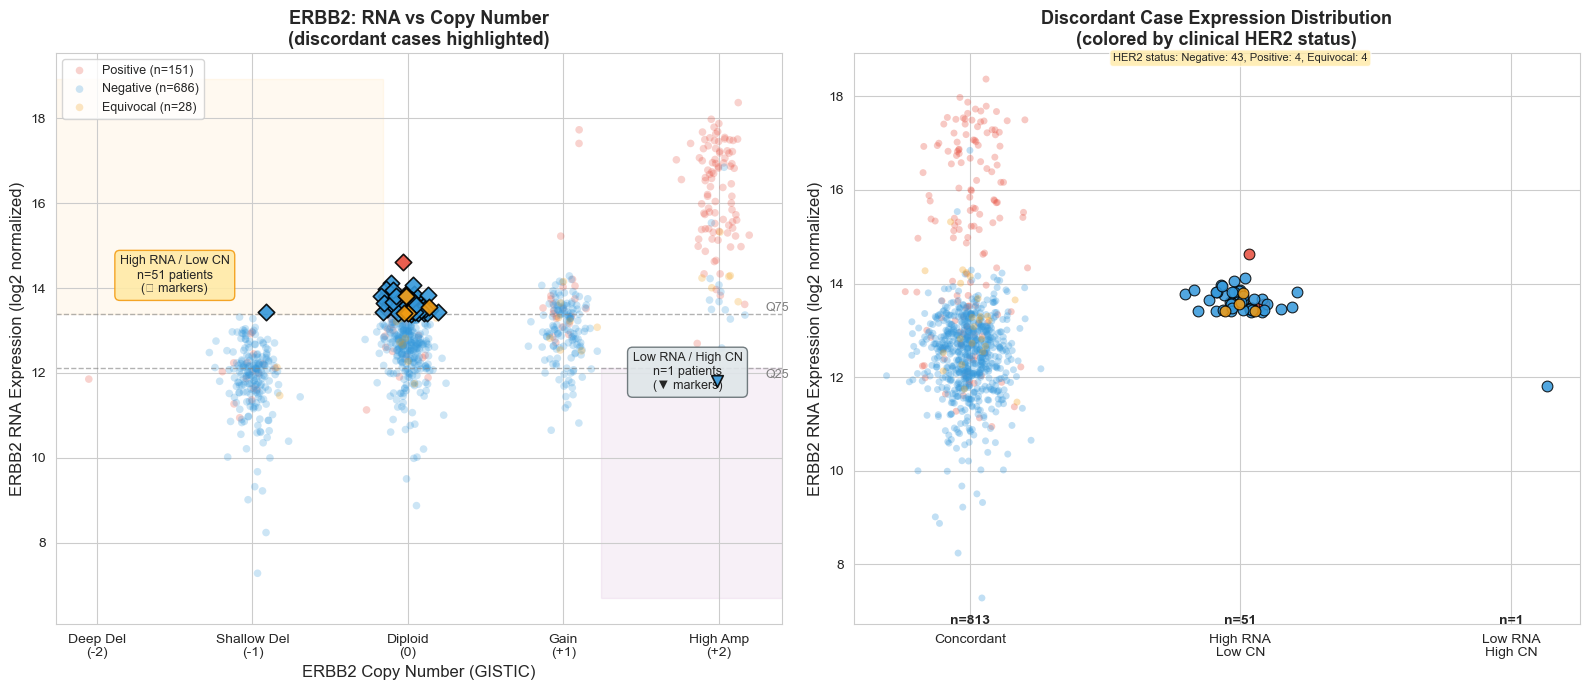


Discordant Case Analysis:
--------------------------------------------------
  High RNA (>Q75=13.4) + Low CN (≤0): 51 patients
  Low RNA (<Q25=12.1) + High CN (≥2): 1 patients

  High RNA / Low CN — HER2 status breakdown:
her2_composite
Negative     43
Positive      4
Equivocal     4

  Top 10 High RNA / Low CN patients:
         pid  ERBB2_expr  erbb2_copy_number her2_composite
TCGA-E2-A3DX   14.626068                  0       Positive
TCGA-AC-A3EH   14.120085                  0       Negative
TCGA-OL-A5D6   14.064282                  0       Negative
TCGA-D8-A3Z5   13.976670                  0       Negative
TCGA-OK-A5Q2   13.946282                  0       Negative
TCGA-E2-A155   13.862488                  0       Negative
TCGA-A2-A3KC   13.854708                  0       Negative
TCGA-LL-A50Y   13.835429                  0       Negative
TCGA-OL-A5RV   13.821803                  0       Negative
TCGA-HN-A2OB   13.818486                  0       Negative


In [71]:
# ERBB2 RNA vs Copy Number scatter — with discordant cases highlighted
if 'ERBB2_expr' in analysis_df.columns and 'erbb2_copy_number' in analysis_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    labeled = analysis_df.dropna(subset=['her2_composite', 'ERBB2_expr', 'erbb2_copy_number'])
    
    # Compute discordance thresholds
    expr_q75 = labeled['ERBB2_expr'].quantile(0.75)
    expr_q25 = labeled['ERBB2_expr'].quantile(0.25)
    
    high_rna_low_cn = (labeled['ERBB2_expr'] > expr_q75) & (labeled['erbb2_copy_number'] <= 0)
    low_rna_high_cn = (labeled['ERBB2_expr'] < expr_q25) & (labeled['erbb2_copy_number'] >= 2)
    discordant = high_rna_low_cn | low_rna_high_cn
    concordant = ~discordant
    
    # ---- Left panel: scatter with discordant cases highlighted ----
    color_map = {'Positive': '#e74c3c', 'Negative': '#3498db', 'Equivocal': '#f39c12',
                 'Indeterminate': '#95a5a6'}
    
    # Plot concordant cases first (background, muted)
    for status, color in color_map.items():
        mask = (labeled['her2_composite'] == status) & concordant
        if mask.sum() > 0:
            axes[0].scatter(
                labeled.loc[mask, 'erbb2_copy_number'] + np.random.normal(0, 0.08, mask.sum()),
                labeled.loc[mask, 'ERBB2_expr'],
                c=color, alpha=0.25, s=30, edgecolors='none',
                label=f'{status} (n={(labeled["her2_composite"] == status).sum()})'
            )
    
    # Plot discordant cases on top (bold, black edge)
    for status, color in color_map.items():
        mask = (labeled['her2_composite'] == status) & high_rna_low_cn
        if mask.sum() > 0:
            axes[0].scatter(
                labeled.loc[mask, 'erbb2_copy_number'] + np.random.normal(0, 0.08, mask.sum()),
                labeled.loc[mask, 'ERBB2_expr'],
                c=color, alpha=0.9, s=70, edgecolors='black', linewidth=1.2,
                marker='D', zorder=5
            )
    
    for status, color in color_map.items():
        mask = (labeled['her2_composite'] == status) & low_rna_high_cn
        if mask.sum() > 0:
            axes[0].scatter(
                labeled.loc[mask, 'erbb2_copy_number'] + np.random.normal(0, 0.08, mask.sum()),
                labeled.loc[mask, 'ERBB2_expr'],
                c=color, alpha=0.9, s=70, edgecolors='black', linewidth=1.2,
                marker='v', zorder=5
            )
    
    # Reference lines for the discordance quadrants
    axes[0].axhline(y=expr_q75, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    axes[0].axhline(y=expr_q25, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    axes[0].text(2.3, expr_q75, 'Q75', fontsize=9, color='gray', va='bottom')
    axes[0].text(2.3, expr_q25, 'Q25', fontsize=9, color='gray', va='top')
    
    # Shaded regions for discordant zones
    xlims = axes[0].get_xlim()
    axes[0].axhspan(expr_q75, axes[0].get_ylim()[1], xmin=0, xmax=0.45, 
                     alpha=0.06, color='orange', zorder=0)
    axes[0].axhspan(axes[0].get_ylim()[0], expr_q25, xmin=0.75, xmax=1.0,
                     alpha=0.06, color='purple', zorder=0)
    
    # Annotation boxes
    n_hi_lo = high_rna_low_cn.sum()
    n_lo_hi = low_rna_high_cn.sum()
    axes[0].annotate(
        f'High RNA / Low CN\nn={n_hi_lo} patients\n(◆ markers)',
        xy=(-1.5, expr_q75 + 0.5), fontsize=9,
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaa7', edgecolor='#f39c12', alpha=0.9),
        ha='center'
    )
    if n_lo_hi > 0:
        axes[0].annotate(
            f'Low RNA / High CN\nn={n_lo_hi} patients\n(▼ markers)',
            xy=(1.8, expr_q25 - 0.5), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#dfe6e9', edgecolor='#636e72', alpha=0.9),
            ha='center'
        )
    
    axes[0].set_xlabel('ERBB2 Copy Number (GISTIC)', fontsize=12)
    axes[0].set_ylabel('ERBB2 RNA Expression (log2 normalized)', fontsize=12)
    axes[0].set_title('ERBB2: RNA vs Copy Number\n(discordant cases highlighted)', 
                       fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=9, loc='upper left')
    axes[0].set_xticks([-2, -1, 0, 1, 2])
    axes[0].set_xticklabels(['Deep Del\n(-2)', 'Shallow Del\n(-1)', 'Diploid\n(0)', 
                             'Gain\n(+1)', 'High Amp\n(+2)'])
    
    # ---- Right panel: strip plot of discordant vs concordant ----
    # More informative than the boxplot: directly compare the two groups
    labeled_plot = labeled.copy()
    labeled_plot['discordant_group'] = 'Concordant'
    labeled_plot.loc[high_rna_low_cn, 'discordant_group'] = 'High RNA / Low CN'
    labeled_plot.loc[low_rna_high_cn, 'discordant_group'] = 'Low RNA / High CN'
    
    group_order = ['Concordant', 'High RNA / Low CN', 'Low RNA / High CN']
    group_colors = {'Concordant': '#aab7b8', 'High RNA / Low CN': '#f39c12', 
                    'Low RNA / High CN': '#8e44ad'}
    
    for i, group in enumerate(group_order):
        mask = labeled_plot['discordant_group'] == group
        if mask.sum() == 0:
            continue
        subset = labeled_plot[mask]
        
        # Color by HER2 status within each group
        for status, color in color_map.items():
            smask = subset['her2_composite'] == status
            if smask.sum() > 0:
                jitter = np.random.normal(0, 0.08, smask.sum())
                alpha = 0.3 if group == 'Concordant' else 0.85
                size = 25 if group == 'Concordant' else 60
                axes[1].scatter(
                    np.full(smask.sum(), i) + jitter,
                    subset.loc[smask, 'ERBB2_expr'],
                    c=color, alpha=alpha, s=size,
                    edgecolors='black' if group != 'Concordant' else 'none',
                    linewidth=0.8 if group != 'Concordant' else 0
                )
    
    # Summary stats
    for i, group in enumerate(group_order):
        mask = labeled_plot['discordant_group'] == group
        if mask.sum() > 0:
            n = mask.sum()
            axes[1].text(i, axes[1].get_ylim()[0] if axes[1].get_ylim()[0] != 0 else 7.5,
                         f'n={n}', ha='center', fontsize=10, fontweight='bold')
    
    axes[1].set_xticks(range(len(group_order)))
    axes[1].set_xticklabels(['Concordant', 'High RNA\nLow CN', 'Low RNA\nHigh CN'], fontsize=10)
    axes[1].set_ylabel('ERBB2 RNA Expression (log2 normalized)', fontsize=12)
    axes[1].set_title('Discordant Case Expression Distribution\n(colored by clinical HER2 status)',
                       fontsize=13, fontweight='bold')
    
    # Add HER2 status breakdown as text for the discordant group
    hi_lo_subset = labeled_plot[labeled_plot['discordant_group'] == 'High RNA / Low CN']
    if len(hi_lo_subset) > 0:
        status_counts = hi_lo_subset['her2_composite'].value_counts()
        breakdown = ', '.join([f'{s}: {c}' for s, c in status_counts.items()])
        axes[1].text(1, axes[1].get_ylim()[1] if axes[1].get_ylim()[1] != 0 else 18.5,
                     f'HER2 status: {breakdown}',
                     ha='center', va='top', fontsize=8,
                     bbox=dict(boxstyle='round', facecolor='#ffeaa7', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print discordant case analysis
    print("\nDiscordant Case Analysis:")
    print("-" * 50)
    print(f"  High RNA (>Q75={expr_q75:.1f}) + Low CN (≤0): {high_rna_low_cn.sum()} patients")
    print(f"  Low RNA (<Q25={expr_q25:.1f}) + High CN (≥2): {low_rna_high_cn.sum()} patients")
    
    if high_rna_low_cn.sum() > 0:
        print("\n  High RNA / Low CN — HER2 status breakdown:")
        print(labeled.loc[high_rna_low_cn, 'her2_composite'].value_counts().to_string())
        print("\n  Top 10 High RNA / Low CN patients:")
        cols_show = ['pid', 'ERBB2_expr', 'erbb2_copy_number', 'her2_composite']
        cols_available = [c for c in cols_show if c in labeled.columns]
        print(labeled.loc[high_rna_low_cn].sort_values('ERBB2_expr', ascending=False)[cols_available].head(10).to_string(index=False))
else:
    print("Cannot perform RNA vs CN analysis — ERBB2 expression or CN data missing.")

## 2.3 RNA vs DNA: Which Is More Predictive of Clinical IHC?

We compare ERBB2 RNA expression, ERBB2 copy number, and a combined model for predicting 
the clinical IHC-HER2 label using ROC-AUC analysis.


RNA vs DNA: PREDICTIVE COMPARISON FOR CLINICAL HER2

Samples for modeling: 837 (Pos: 151, Neg: 686)
  ERBB2 RNA only           : AUC-ROC = 0.837, AUC-PR = 0.759
  ERBB2 CN only            : AUC-ROC = 0.808, AUC-PR = 0.626
  RNA + CN combined        : AUC-ROC = 0.836, AUC-PR = 0.763


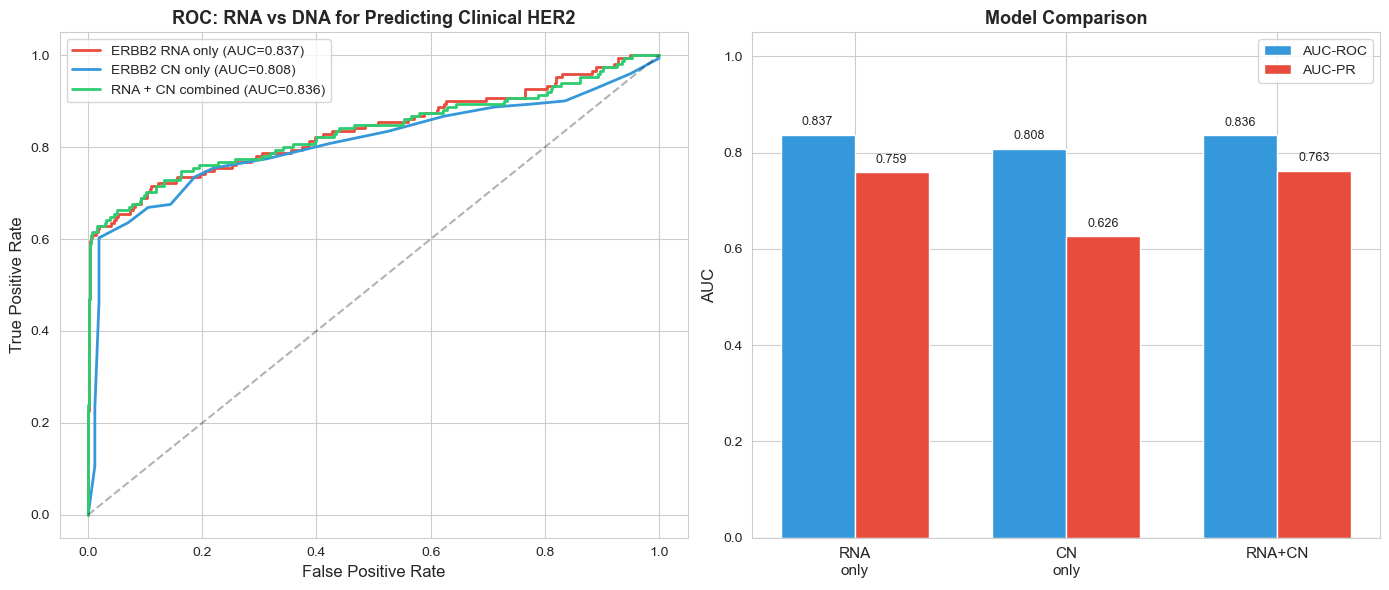


→ Best single-feature predictor: ERBB2 RNA only (AUC-ROC = 0.837)
→ Combined model does not improve over best single modality.


In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("RNA vs DNA: PREDICTIVE COMPARISON FOR CLINICAL HER2")
print("=" * 70)

# Prepare labeled data with both RNA and CN
model_df = analysis_df.dropna(subset=['her2_composite', 'erbb2_copy_number']).copy()
model_df = model_df[model_df['her2_composite'].isin(['Positive', 'Negative'])]
model_df['y'] = (model_df['her2_composite'] == 'Positive').astype(int)

print(f"\nSamples for modeling: {len(model_df)} (Pos: {model_df['y'].sum()}, Neg: {(1-model_df['y']).sum()})")

has_erbb2_expr = 'ERBB2_expr' in model_df.columns and model_df['ERBB2_expr'].notna().sum() > 10

if has_erbb2_expr:
    model_df = model_df.dropna(subset=['ERBB2_expr'])
    
    # Three models: RNA only, CN only, RNA + CN
    X_rna = model_df[['ERBB2_expr']].values
    X_cn = model_df[['erbb2_copy_number']].values
    X_both = model_df[['ERBB2_expr', 'erbb2_copy_number']].values
    y = model_df['y'].values
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    results = {}
    for name, X in [('ERBB2 RNA only', X_rna), ('ERBB2 CN only', X_cn), ('RNA + CN combined', X_both)]:
        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Cross-validated predictions
        lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
        y_prob = cross_val_predict(lr, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
        
        auc_roc = roc_auc_score(y, y_prob)
        auc_pr = average_precision_score(y, y_prob)
        fpr, tpr, _ = roc_curve(y, y_prob)
        
        results[name] = {'auc_roc': auc_roc, 'auc_pr': auc_pr, 'fpr': fpr, 'tpr': tpr, 'y_prob': y_prob}
        print(f"  {name:25s}: AUC-ROC = {auc_roc:.3f}, AUC-PR = {auc_pr:.3f}")
    
    # ROC curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    colors_roc = {'ERBB2 RNA only': '#e74c3c', 'ERBB2 CN only': '#3498db', 'RNA + CN combined': '#2ecc71'}
    for name, res in results.items():
        axes[0].plot(res['fpr'], res['tpr'], color=colors_roc[name], linewidth=2,
                     label=f"{name} (AUC={res['auc_roc']:.3f})")
    axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('ROC: RNA vs DNA for Predicting Clinical HER2', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=10)
    
    # AUC comparison bar chart
    model_names = list(results.keys())
    auc_vals = [results[n]['auc_roc'] for n in model_names]
    pr_vals = [results[n]['auc_pr'] for n in model_names]
    
    x_pos = np.arange(len(model_names))
    width = 0.35
    axes[1].bar(x_pos - width/2, auc_vals, width, label='AUC-ROC', color='#3498db', edgecolor='white')
    axes[1].bar(x_pos + width/2, pr_vals, width, label='AUC-PR', color='#e74c3c', edgecolor='white')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels(['RNA\nonly', 'CN\nonly', 'RNA+CN'], fontsize=11)
    axes[1].set_ylabel('AUC', fontsize=12)
    axes[1].set_title('Model Comparison', fontsize=13, fontweight='bold')
    axes[1].legend()
    axes[1].set_ylim(0, 1.05)
    for i, (roc_v, pr_v) in enumerate(zip(auc_vals, pr_vals)):
        axes[1].text(i - width/2, roc_v + 0.02, f'{roc_v:.3f}', ha='center', fontsize=9)
        axes[1].text(i + width/2, pr_v + 0.02, f'{pr_v:.3f}', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Interpretation
    best_model = max(results, key=lambda k: results[k]['auc_roc'])
    print(f"\n→ Best single-feature predictor: {best_model} (AUC-ROC = {results[best_model]['auc_roc']:.3f})")
    if results['RNA + CN combined']['auc_roc'] > max(results['ERBB2 RNA only']['auc_roc'], 
                                                       results['ERBB2 CN only']['auc_roc']):
        improvement = results['RNA + CN combined']['auc_roc'] - max(
            results['ERBB2 RNA only']['auc_roc'], results['ERBB2 CN only']['auc_roc'])
        print(f"→ Combined model improves over best single modality by {improvement:.3f} AUC")
    else:
        print("→ Combined model does not improve over best single modality.")

else:
    # CN-only analysis
    print("\nERBB2 expression not available. Performing CN-only analysis.")
    X_cn = model_df[['erbb2_copy_number']].values
    y = model_df['y'].values
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_cn)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    lr = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
    y_prob = cross_val_predict(lr, X_scaled, y, cv=cv, method='predict_proba')[:, 1]
    
    auc_roc = roc_auc_score(y, y_prob)
    print(f"  ERBB2 CN only: AUC-ROC = {auc_roc:.3f}")
    print("  → Full RNA vs DNA comparison requires ERBB2 gene in expression data.")


*Figure 1. ERBB2 RNA expression outperforms copy number for predicting clinical HER2 status. (Left) Receiver operating characteristic (ROC) curves for logistic regression models predicting IHC-defined HER2 status using ERBB2 RNA expression alone (AUC = 0.837), ERBB2 copy number alone (AUC = 0.808), or both features combined (AUC = 0.836). Predictions were generated via 5-fold stratified cross-validation with class-balanced weighting (n = 837; 151 HER2+, 686 HER2−). (Right) Comparison of AUC-ROC and AUC-PR across models. RNA expression is the stronger single predictor by both metrics, and the combined model offers no improvement, indicating that copy number's predictive information is largely captured by RNA. The notably lower AUC-PR for copy number (0.626 vs. 0.759 for RNA) reflects poor precision in the minority class, likely due to the coarse granularity of GISTIC discrete values (−2 to +2).*

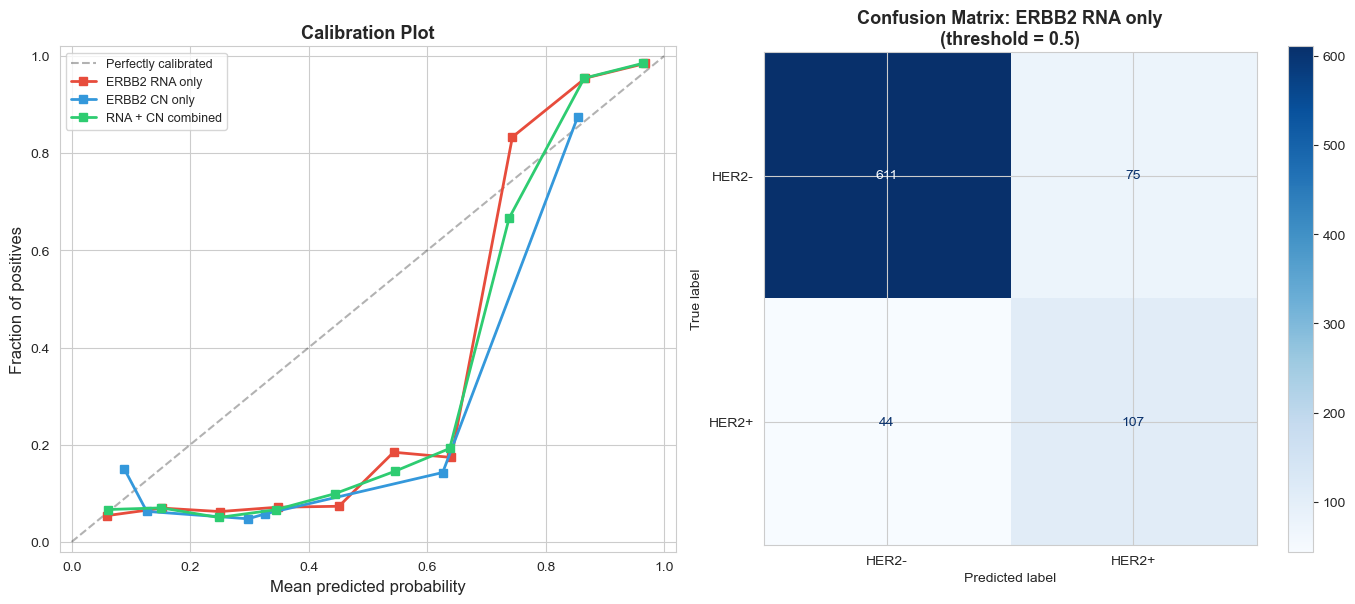


Performance at threshold = 0.5 (ERBB2 RNA only)
  Sensitivity (recall):  0.709  (107/151 HER2+ caught)
  Specificity:           0.891  (611/686 HER2- correct)
  Precision (PPV):       0.588  (107/182 positive calls correct)
  NPV:                   0.933  (611/655 negative calls correct)

  → At this threshold, 44 HER2+ patients would be missed,
    and 75 HER2- patients would be false positives.

Threshold sweep for target sensitivities
  Threshold=0.342 → Sens=0.801, Spec=0.625, PPV=0.320, FP=257, FN=30
  Threshold=0.291 → Sens=0.848, Spec=0.515, PPV=0.278, FP=333, FN=23
  Threshold=0.221 → Sens=0.901, Spec=0.373, PPV=0.240, FP=430, FN=15
  Threshold=0.137 → Sens=0.954, Spec=0.181, PPV=0.204, FP=562, FN=7


In [72]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# --- Configuration ---
# Set threshold to capture ~90% of HER2+ patients (high sensitivity)
THRESHOLD = 0.5  # Adjust this to explore different trade-offs

# =====================================================================
# 1. CALIBRATION PLOT
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax_cal = axes[0]
ax_cal.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfectly calibrated')

for name, res in results.items():
    prob_true, prob_pred = calibration_curve(y, res['y_prob'], n_bins=10, strategy='uniform')
    ax_cal.plot(prob_pred, prob_true, 's-', color=colors_roc[name], label=name, linewidth=2)

ax_cal.set_xlabel('Mean predicted probability', fontsize=12)
ax_cal.set_ylabel('Fraction of positives', fontsize=12)
ax_cal.set_title('Calibration Plot', fontsize=13, fontweight='bold')
ax_cal.legend(fontsize=9)
ax_cal.set_xlim(-0.02, 1.02)
ax_cal.set_ylim(-0.02, 1.02)

# =====================================================================
# 2. CONFUSION MATRIX (for best model at chosen threshold)
# =====================================================================
best_name = max(results, key=lambda k: results[k]['auc_roc'])
y_prob_best = results[best_name]['y_prob']
y_pred = (y_prob_best >= THRESHOLD).astype(int)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['HER2-', 'HER2+'])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title(f'Confusion Matrix: {best_name}\n(threshold = {THRESHOLD})', 
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# =====================================================================
# 3. SUMMARY STATS AT THIS THRESHOLD
# =====================================================================
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\n{'='*50}")
print(f"Performance at threshold = {THRESHOLD} ({best_name})")
print(f"{'='*50}")
print(f"  Sensitivity (recall):  {sensitivity:.3f}  ({tp}/{tp+fn} HER2+ caught)")
print(f"  Specificity:           {specificity:.3f}  ({tn}/{tn+fp} HER2- correct)")
print(f"  Precision (PPV):       {precision:.3f}  ({tp}/{tp+fp} positive calls correct)")
print(f"  NPV:                   {npv:.3f}  ({tn}/{tn+fn} negative calls correct)")
print(f"\n  → At this threshold, {fn} HER2+ patients would be missed,")
print(f"    and {fp} HER2- patients would be false positives.")

# =====================================================================
# 4. THRESHOLD SWEEP (find threshold for ~90% sensitivity)
# =====================================================================
print(f"\n{'='*50}")
print("Threshold sweep for target sensitivities")
print(f"{'='*50}")
for target_sens in [0.80, 0.85, 0.90, 0.95]:
    fpr_curve, tpr_curve, thresholds = roc_curve(y, y_prob_best)
    # Find threshold closest to target sensitivity
    idx = np.argmin(np.abs(tpr_curve - target_sens))
    t = thresholds[idx] if idx < len(thresholds) else thresholds[-1]
    y_pred_t = (y_prob_best >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y, y_pred_t).ravel()
    sens_t = tp_t / (tp_t + fn_t)
    spec_t = tn_t / (tn_t + fp_t)
    prec_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    print(f"  Threshold={t:.3f} → Sens={sens_t:.3f}, Spec={spec_t:.3f}, "
          f"PPV={prec_t:.3f}, FP={fp_t}, FN={fn_t}")

Figure 2. Calibration and classification performance of ERBB2 RNA expression at a 0.5 probability threshold. (Left) Calibration curves for all three models showing the relationship between predicted probability and observed HER2+ frequency. All models are poorly calibrated below predicted probabilities of ~0.6, systematically overestimating HER2+ risk in the low-to-mid range — an artifact of balanced class weighting in logistic regression. Calibration improves at higher predicted probabilities (>0.7). (Right) Confusion matrix for the RNA-only model at threshold = 0.5, yielding sensitivity of 0.709 (107/151 HER2+ detected) and specificity of 0.891 (611/686 HER2− correct). At this threshold, 44 HER2+ patients are missed and 75 HER2− patients are falsely flagged. The threshold sweep (not shown) indicates that achieving 90% sensitivity requires accepting a false positive rate of 63% (threshold = 0.221), suggesting that single-gene ERBB2 expression alone is insufficient for clinical-grade screening and motivates multi-gene predictive models.

---
# Section 3: Unsupervised Clustering — Identifying Biologically Distinct Subsets

## 3.1 Feature Selection and Dimensionality Reduction

We select the most variable genes, perform PCA for dimensionality reduction, and use UMAP 
for 2D visualization. We expect to recover breast cancer intrinsic subtypes.

*Note: With the abridged dataset (~86 genes), we use all filtered genes. With the full dataset, 
we would select the top 2,000–3,000 most variable genes by MAD.*


UNSUPERVISED CLUSTERING
Using top 3000 most variable genes (by MAD)

PCA: 20 components
  Variance explained by first 5 PCs: 35.0%
  Variance explained by first 10 PCs: 43.4%


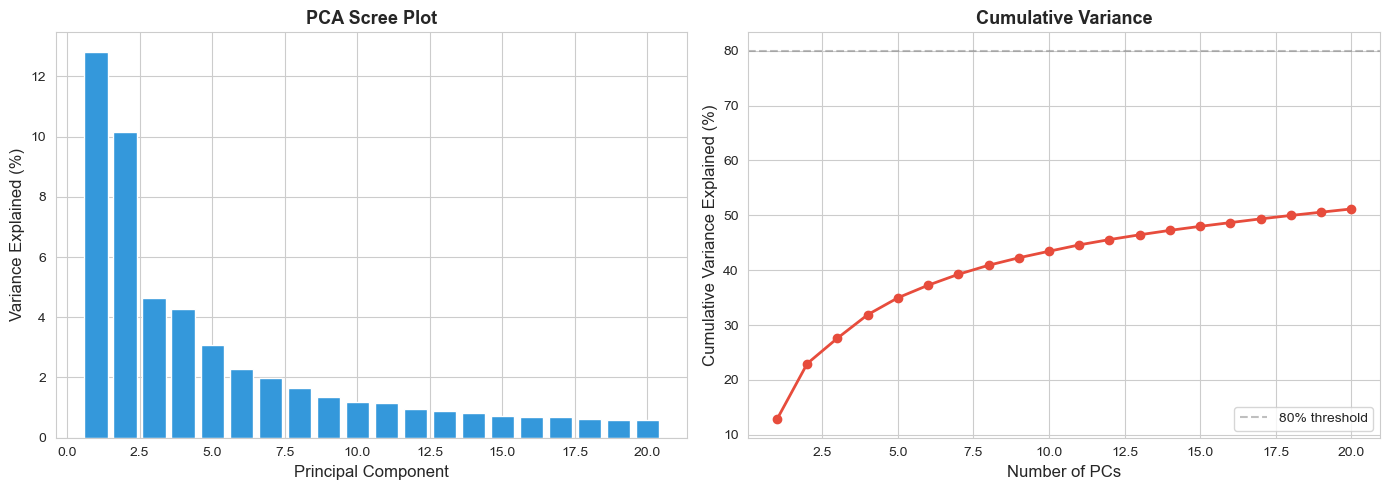

In [63]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("=" * 70)
print("UNSUPERVISED CLUSTERING")
print("=" * 70)

# Use the normalized tumor data
# Select most variable genes (MAD-based)
gene_mad = tumor_norm.apply(lambda x: np.median(np.abs(x - np.median(x))), axis=0)
gene_mad_sorted = gene_mad.sort_values(ascending=False)

# With abridged data, use all genes; with full data, use top 2000-3000
n_top_genes = min(len(gene_cols_filtered), 3000)
top_genes = gene_mad_sorted.head(n_top_genes).index.tolist()
print(f"Using top {len(top_genes)} most variable genes (by MAD)")

# Prepare data matrix
X_cluster = tumor_norm[top_genes].fillna(0).values
patient_ids_cluster = tumor_filtered['pid'].values

# Standardize
scaler_cl = StandardScaler()
X_scaled_cl = scaler_cl.fit_transform(X_cluster)

# PCA
n_pcs_use = min(20, X_scaled_cl.shape[0] - 1, X_scaled_cl.shape[1])
pca_cl = PCA(n_components=n_pcs_use)
X_pca = pca_cl.fit_transform(X_scaled_cl)

print(f"\nPCA: {n_pcs_use} components")
print(f"  Variance explained by first 5 PCs: {pca_cl.explained_variance_ratio_[:5].sum():.1%}")
print(f"  Variance explained by first 10 PCs: {pca_cl.explained_variance_ratio_[:min(10, n_pcs_use)].sum():.1%}")

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, n_pcs_use + 1), pca_cl.explained_variance_ratio_ * 100,
            color='#3498db', edgecolor='white')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained (%)', fontsize=12)
axes[0].set_title('PCA Scree Plot', fontsize=13, fontweight='bold')

# Cumulative
cum_var = np.cumsum(pca_cl.explained_variance_ratio_) * 100
axes[1].plot(range(1, n_pcs_use + 1), cum_var, 'o-', color='#e74c3c', linewidth=2)
axes[1].axhline(y=80, linestyle='--', color='gray', alpha=0.5, label='80% threshold')
axes[1].set_xlabel('Number of PCs', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained (%)', fontsize=12)
axes[1].set_title('Cumulative Variance', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


umap-learn not available. Using PCA for visualization.


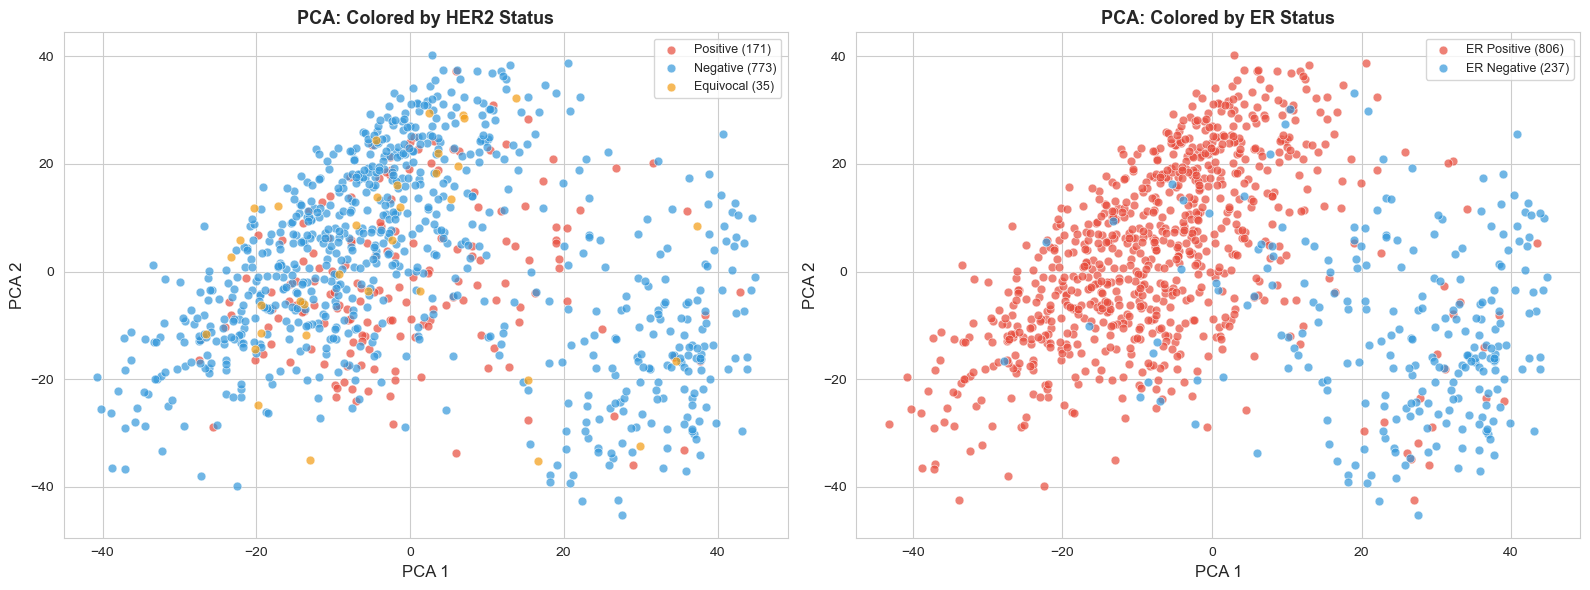

In [64]:
# UMAP for 2D visualization
try:
    import umap
    
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
    X_umap = reducer.fit_transform(X_pca[:, :min(10, n_pcs_use)])
    has_umap = True
    print("UMAP embedding computed successfully.")
except ImportError:
    print("umap-learn not available. Using PCA for visualization.")
    X_umap = X_pca[:, :2]
    has_umap = False

# Create mapping from pid to clinical variables
pid_to_her2 = dict(zip(clinical['pid'], clinical['her2_composite']))
pid_to_er = dict(zip(clinical['pid'], clinical['ER Status By IHC']))

cluster_her2 = [pid_to_her2.get(pid, 'Unknown') for pid in patient_ids_cluster]
cluster_er = [pid_to_er.get(pid, 'Unknown') for pid in patient_ids_cluster]

# Visualize
dim_label = 'UMAP' if has_umap else 'PCA'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Color by HER2
color_map_her2 = {'Positive': '#e74c3c', 'Negative': '#3498db', 'Equivocal': '#f39c12',
                  'Indeterminate': '#95a5a6', 'Unknown': '#d5d8dc'}
for status, color in color_map_her2.items():
    mask = np.array([h == status for h in cluster_her2])
    if mask.sum() > 0:
        axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1], c=color,
                       label=f'{status} ({mask.sum()})', alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
axes[0].set_xlabel(f'{dim_label} 1', fontsize=12)
axes[0].set_ylabel(f'{dim_label} 2', fontsize=12)
axes[0].set_title(f'{dim_label}: Colored by HER2 Status', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9)

# Color by ER
color_map_er = {'Positive': '#e74c3c', 'Negative': '#3498db', 'Unknown': '#d5d8dc'}
for status, color in color_map_er.items():
    mask = np.array([e == status for e in cluster_er])
    if mask.sum() > 0:
        axes[1].scatter(X_umap[mask, 0], X_umap[mask, 1], c=color,
                       label=f'ER {status} ({mask.sum()})', alpha=0.7, s=40, edgecolors='white', linewidth=0.5)
axes[1].set_xlabel(f'{dim_label} 1', fontsize=12)
axes[1].set_ylabel(f'{dim_label} 2', fontsize=12)
axes[1].set_title(f'{dim_label}: Colored by ER Status', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


## 3.2 Clustering and Optimal k

We use k-means clustering on the top PCs, evaluating cluster quality via silhouette score 
to find the optimal number of clusters.


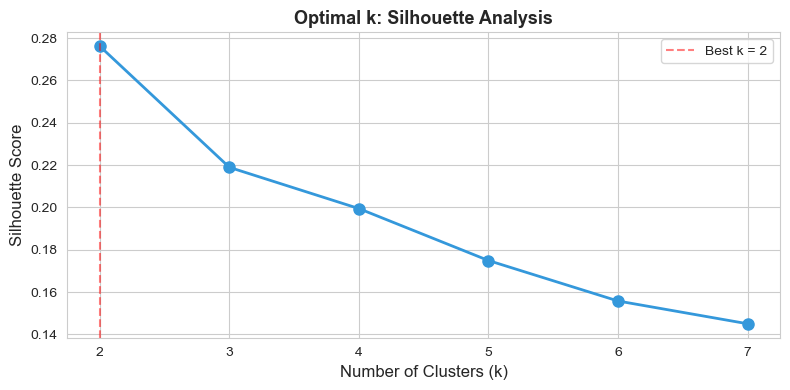

Best k by silhouette: 2 (score = 0.276)

Note: In breast cancer, we expect ~4-5 intrinsic subtypes (Luminal A, Luminal B,
HER2-enriched, Basal-like, Normal-like). With abridged data, fewer clusters may emerge.


In [65]:
# Determine optimal k via silhouette analysis
n_pcs_for_clustering = min(10, X_pca.shape[1])
X_for_clustering = X_pca[:, :n_pcs_for_clustering]

k_range = range(2, min(8, len(X_for_clustering) // 5))
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_for_clustering)
    sil = silhouette_score(X_for_clustering, labels)
    silhouette_scores.append(sil)
    
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), silhouette_scores, 'o-', color='#3498db', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Optimal k: Silhouette Analysis', fontsize=13, fontweight='bold')
ax.set_xticks(list(k_range))

best_k = list(k_range)[np.argmax(silhouette_scores)]
ax.axvline(x=best_k, linestyle='--', color='red', alpha=0.5, label=f'Best k = {best_k}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best k by silhouette: {best_k} (score = {max(silhouette_scores):.3f})")
print("\nNote: In breast cancer, we expect ~4-5 intrinsic subtypes (Luminal A, Luminal B,")
print("HER2-enriched, Basal-like, Normal-like). With abridged data, fewer clusters may emerge.")



CLUSTERING RESULTS: k = 2 (silhouette-optimal)
  Cluster 0: 849 samples (77.7%)
  Cluster 1: 244 samples (22.3%)


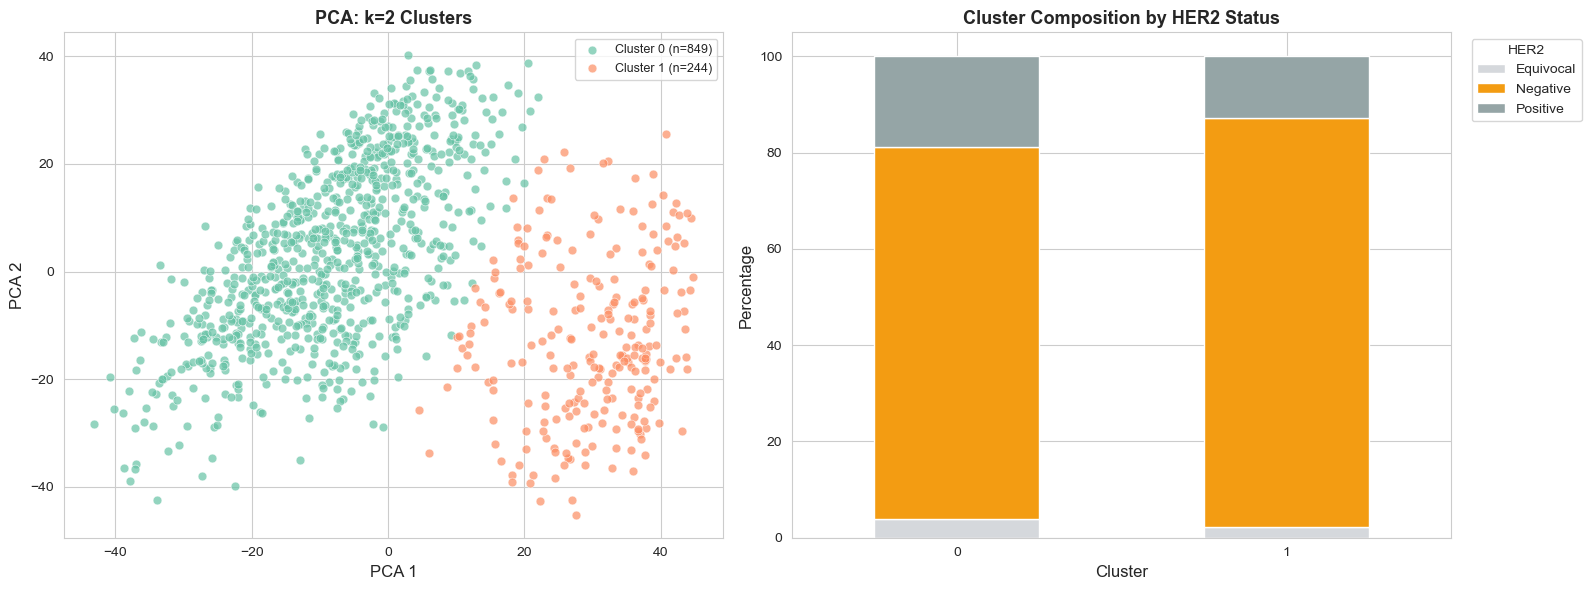


HER2 Enrichment by Cluster (Fisher's exact test):
  Cluster 0: 143/731 HER2+ (20%), Fisher p = 0.03373, OR = 1.61
  Cluster 1: 28/213 HER2+ (13%), Fisher p = 0.03373, OR = 0.62

CLUSTERING RESULTS: k = 4 (biology-motivated (k=4))
  Cluster 0: 259 samples (23.7%)
  Cluster 1: 334 samples (30.6%)
  Cluster 2: 192 samples (17.6%)
  Cluster 3: 308 samples (28.2%)


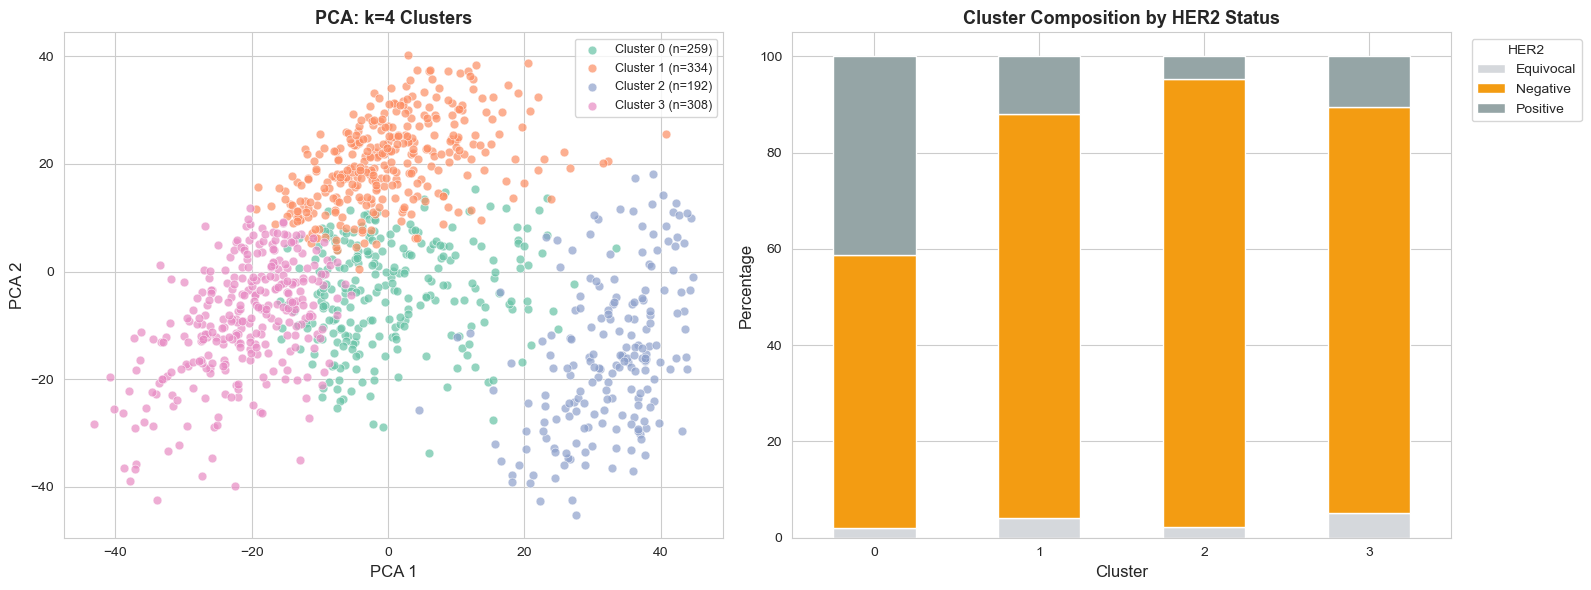


HER2 Enrichment by Cluster (Fisher's exact test):
  Cluster 0: 99/235 HER2+ (42%), Fisher p = 4.05e-25, OR = 6.44
  Cluster 1: 37/297 HER2+ (12%), Fisher p = 0.001964, OR = 0.54
  Cluster 2: 8/170 HER2+ (5%), Fisher p = 3.741e-08, OR = 0.19
  Cluster 3: 27/242 HER2+ (11%), Fisher p = 0.000953, OR = 0.49


In [66]:
# Apply clustering with chosen k and biologically motivated k
# Use both best silhouette k and k=4 (closest to PAM50 subtypes)
k_bio = min(4, len(X_for_clustering) // 5)

for k_use, label_name in [(best_k, 'silhouette-optimal'), (k_bio, 'biology-motivated (k=4)')]:
    if k_use < 2:
        continue
    km = KMeans(n_clusters=k_use, random_state=42, n_init=20)
    cluster_labels = km.fit_predict(X_for_clustering)
    
    print(f"\n{'=' * 70}")
    print(f"CLUSTERING RESULTS: k = {k_use} ({label_name})")
    print(f"{'=' * 70}")
    
    # Cluster sizes
    for c in range(k_use):
        n_c = (cluster_labels == c).sum()
        print(f"  Cluster {c}: {n_c} samples ({100*n_c/len(cluster_labels):.1f}%)")
    
    # Overlay on UMAP
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    cmap = plt.cm.Set2
    for c in range(k_use):
        mask = cluster_labels == c
        axes[0].scatter(X_umap[mask, 0], X_umap[mask, 1], c=[cmap(c)],
                       label=f'Cluster {c} (n={mask.sum()})', alpha=0.7, s=40,
                       edgecolors='white', linewidth=0.5)
    axes[0].set_xlabel(f'{dim_label} 1', fontsize=12)
    axes[0].set_ylabel(f'{dim_label} 2', fontsize=12)
    axes[0].set_title(f'{dim_label}: k={k_use} Clusters', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=9)
    
    # Cluster composition by HER2 status
    cluster_comp = pd.DataFrame({'cluster': cluster_labels, 'her2': cluster_her2})
    ct_cluster = pd.crosstab(cluster_comp['cluster'], cluster_comp['her2'])
    ct_pct = ct_cluster.div(ct_cluster.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#d5d8dc', '#f39c12', '#95a5a6', '#3498db', '#e74c3c'],
                edgecolor='white')
    axes[1].set_xlabel('Cluster', fontsize=12)
    axes[1].set_ylabel('Percentage', fontsize=12)
    axes[1].set_title(f'Cluster Composition by HER2 Status', fontsize=13, fontweight='bold')
    axes[1].legend(title='HER2', bbox_to_anchor=(1.02, 1))
    axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.show()

    # HER2 enrichment test per cluster
    print(f"\nHER2 Enrichment by Cluster (Fisher's exact test):")
    cluster_comp_binary = cluster_comp[cluster_comp['her2'].isin(['Positive', 'Negative'])].copy()
    cluster_comp_binary['is_pos'] = (cluster_comp_binary['her2'] == 'Positive').astype(int)
    
    for c in range(k_use):
        in_cluster = cluster_comp_binary['cluster'] == c
        ct_2x2 = pd.crosstab(in_cluster, cluster_comp_binary['is_pos'])
        if ct_2x2.shape == (2, 2):
            odds, p_fisher = stats.fisher_exact(ct_2x2)
            n_pos_in = ct_2x2.loc[True, 1] if 1 in ct_2x2.columns else 0
            n_total_in = in_cluster.sum()
            print(f"  Cluster {c}: {n_pos_in}/{n_total_in} HER2+ ({100*n_pos_in/max(n_total_in,1):.0f}%), "
                  f"Fisher p = {p_fisher:.4g}, OR = {odds:.2f}")


---
# Section 4: Machine Learning & Feature Importance

## 4.1 Model Setup

**Target:** Clinical IHC-HER2 status (Positive vs. Negative)  
**Features:** Normalized RNA expression + ERBB2 copy number + clinical features (ER, PR)  
**Models:** Logistic Regression (L1), Random Forest, XGBoost  
**Evaluation:** Stratified 5-fold CV with AUC-ROC, AUC-PR, and feature importance analysis


In [67]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import StandardScaler, LabelEncoder
import xgboost as xgb

print("=" * 70)
print("MACHINE LEARNING: PREDICTING HER2 STATUS")
print("=" * 70)

# Build feature matrix from multimodal cohort
ml_df = cohort_c.copy()

# Add normalized expression for all available genes
for gene in gene_cols_filtered:
    if gene in tumor_norm_df.columns:
        gene_map = tumor_norm_df.set_index('pid')[gene].to_dict()
        ml_df[f'expr_{gene}'] = ml_df['pid'].map(gene_map)

# Add clinical features
ml_df['er_positive'] = (ml_df['ER Status By IHC'] == 'Positive').astype(float)
ml_df['pr_positive'] = (ml_df['PR status by ihc'] == 'Positive').astype(float)

# Handle NaN in clinical features  
ml_df['er_positive'] = ml_df['er_positive'].fillna(ml_df['er_positive'].median())
ml_df['pr_positive'] = ml_df['pr_positive'].fillna(ml_df['pr_positive'].median())

# Filter to labeled samples
ml_labeled = ml_df[ml_df['her2_composite'].isin(['Positive', 'Negative'])].copy()
ml_labeled['y'] = (ml_labeled['her2_composite'] == 'Positive').astype(int)

# Feature columns
expr_cols = [c for c in ml_labeled.columns if c.startswith('expr_')]
feature_cols = expr_cols + ['erbb2_copy_number', 'er_positive', 'pr_positive']

# Drop rows with NaN features
ml_clean = ml_labeled.dropna(subset=feature_cols + ['y'])

X = ml_clean[feature_cols].values
y = ml_clean['y'].values
feature_names = [c.replace('expr_', '') for c in feature_cols]

print(f"\nFeature matrix: {X.shape[0]} samples × {X.shape[1]} features")
print(f"  Expression features: {len(expr_cols)}")
print(f"  Copy number: 1")
print(f"  Clinical: 2 (ER, PR)")
print(f"  Class balance: {y.sum()} Positive, {(1-y).sum()} Negative")

# Scale
scaler_ml = StandardScaler()
X_scaled = scaler_ml.fit_transform(X)

# Class weight for imbalance
neg_weight = y.sum() / (1 - y).sum() if (1-y).sum() > 0 else 1
scale_pos = (1-y).sum() / max(y.sum(), 1)
print(f"  scale_pos_weight: {scale_pos:.2f}")


MACHINE LEARNING: PREDICTING HER2 STATUS

Feature matrix: 837 samples × 19052 features
  Expression features: 19049
  Copy number: 1
  Clinical: 2 (ER, PR)
  Class balance: 151 Positive, 686 Negative
  scale_pos_weight: 4.54


MODEL COMPARISON (Stratified 5-Fold CV)

Logistic Regression (L1):
  AUC-ROC: 0.858
  AUC-PR:  0.749

Random Forest:
  AUC-ROC: 0.842
  AUC-PR:  0.718

XGBoost:
  AUC-ROC: 0.873
  AUC-PR:  0.786


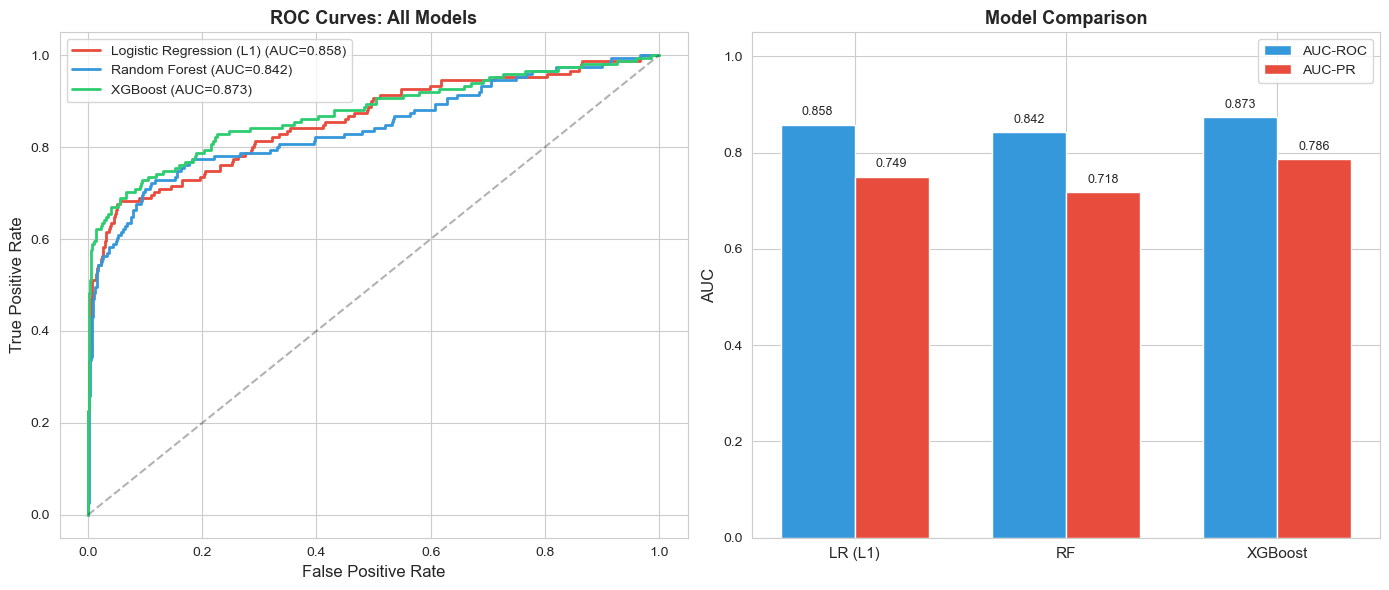


Best model: XGBoost (AUC-ROC = 0.873)

Classification Report (XGBoost):
              precision    recall  f1-score   support

    Negative       0.92      0.99      0.95       686
    Positive       0.91      0.60      0.72       151

    accuracy                           0.92       837
   macro avg       0.91      0.79      0.84       837
weighted avg       0.92      0.92      0.91       837



In [68]:
# Define models
models = {
    'Logistic Regression (L1)': LogisticRegression(
        penalty='l1', solver='saga', max_iter=2000, random_state=42,
        class_weight='balanced', C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=5, random_state=42,
        class_weight='balanced', n_jobs=-1
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos, random_state=42,
        eval_metric='logloss', use_label_encoder=False
    )
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=" * 70)
print("MODEL COMPARISON (Stratified 5-Fold CV)")
print("=" * 70)

model_results = {}
for name, model in models.items():
    # Use scaled data for LR, unscaled for tree models
    X_use = X_scaled if 'Logistic' in name else X
    
    y_prob = cross_val_predict(model, X_use, y, cv=cv, method='predict_proba')[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    
    auc_roc = roc_auc_score(y, y_prob)
    auc_pr = average_precision_score(y, y_prob)
    fpr, tpr, _ = roc_curve(y, y_prob)
    
    model_results[name] = {
        'auc_roc': auc_roc, 'auc_pr': auc_pr,
        'fpr': fpr, 'tpr': tpr, 'y_prob': y_prob, 'y_pred': y_pred
    }
    
    print(f"\n{name}:")
    print(f"  AUC-ROC: {auc_roc:.3f}")
    print(f"  AUC-PR:  {auc_pr:.3f}")

# ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_model = {'Logistic Regression (L1)': '#e74c3c', 'Random Forest': '#3498db', 'XGBoost': '#2ecc71'}
for name, res in model_results.items():
    axes[0].plot(res['fpr'], res['tpr'], color=colors_model[name], linewidth=2,
                 label=f"{name} (AUC={res['auc_roc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title('ROC Curves: All Models', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Bar chart comparison
model_names = list(model_results.keys())
auc_roc_vals = [model_results[n]['auc_roc'] for n in model_names]
auc_pr_vals = [model_results[n]['auc_pr'] for n in model_names]

x_pos = np.arange(len(model_names))
width = 0.35
axes[1].bar(x_pos - width/2, auc_roc_vals, width, label='AUC-ROC', color='#3498db', edgecolor='white')
axes[1].bar(x_pos + width/2, auc_pr_vals, width, label='AUC-PR', color='#e74c3c', edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(['LR (L1)', 'RF', 'XGBoost'], fontsize=11)
axes[1].set_ylabel('AUC', fontsize=12)
axes[1].set_title('Model Comparison', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
for i, (r, p) in enumerate(zip(auc_roc_vals, auc_pr_vals)):
    axes[1].text(i - width/2, r + 0.02, f'{r:.3f}', ha='center', fontsize=9)
    axes[1].text(i + width/2, p + 0.02, f'{p:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Best model classification report
best_model_name = max(model_results, key=lambda k: model_results[k]['auc_roc'])
print(f"\nBest model: {best_model_name} (AUC-ROC = {model_results[best_model_name]['auc_roc']:.3f})")
print(f"\nClassification Report ({best_model_name}):")
print(classification_report(y, model_results[best_model_name]['y_pred'], 
                           target_names=['Negative', 'Positive']))


## 4.2 Feature Importance (SHAP)

We extract SHAP values from the best tree-based model for global and per-sample feature importance.


SHAP not available. Using built-in feature importance.


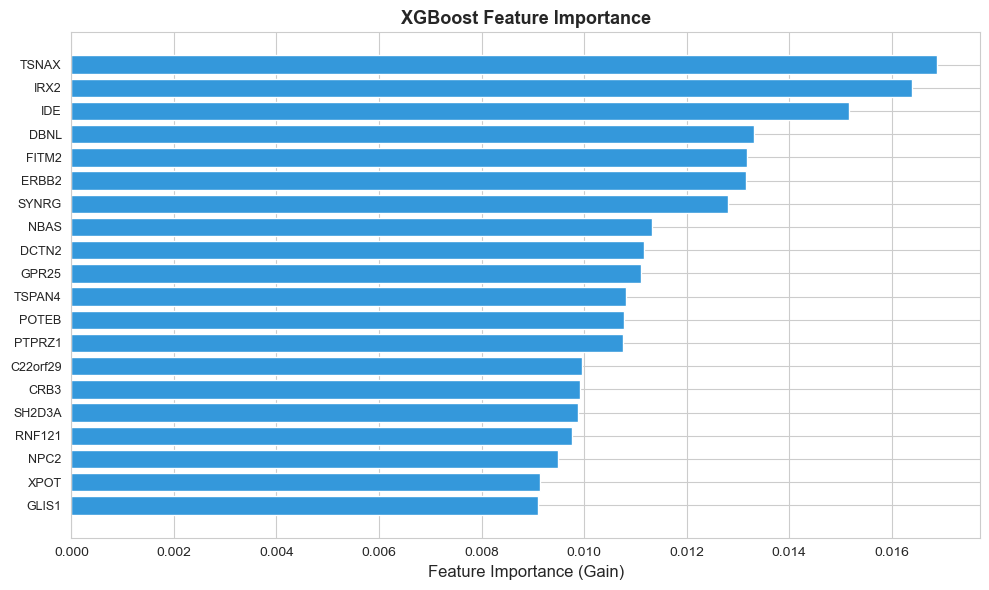


Top 20 Features by XGBoost Importance (Gain):
--------------------------------------------------
   1. TSNAX               : 0.0169
   2. IRX2                : 0.0164
   3. IDE                 : 0.0152
   4. DBNL                : 0.0133
   5. FITM2               : 0.0132
   6. ERBB2               : 0.0132
   7. SYNRG               : 0.0128
   8. NBAS                : 0.0113
   9. DCTN2               : 0.0112
  10. GPR25               : 0.0111
  11. TSPAN4              : 0.0108
  12. POTEB               : 0.0108
  13. PTPRZ1              : 0.0108
  14. C22orf29            : 0.0100
  15. CRB3                : 0.0099
  16. SH2D3A              : 0.0099
  17. RNF121              : 0.0098
  18. NPC2                : 0.0095
  19. XPOT                : 0.0091
  20. GLIS1               : 0.0091


In [69]:
# Train the best tree model on full data for SHAP analysis
try:
    import shap
    has_shap = True
except ImportError:
    has_shap = False
    print("SHAP not available. Using built-in feature importance.")

# Fit XGBoost on full data for importance analysis
xgb_full = xgb.XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos, random_state=42,
    eval_metric='logloss', use_label_encoder=False
)
xgb_full.fit(X, y)

if has_shap:
    print("Computing SHAP values...")
    explainer = shap.TreeExplainer(xgb_full)
    shap_values = explainer.shap_values(X)
    
    # Summary plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar plot (mean |SHAP|)
    mean_shap = np.abs(shap_values).mean(axis=0)
    sorted_idx = np.argsort(mean_shap)[::-1][:20]  # Top 20
    
    axes[0].barh(range(len(sorted_idx)), mean_shap[sorted_idx][::-1],
                color='#3498db', edgecolor='white')
    axes[0].set_yticks(range(len(sorted_idx)))
    axes[0].set_yticklabels([feature_names[i] for i in sorted_idx][::-1], fontsize=9)
    axes[0].set_xlabel('Mean |SHAP Value|', fontsize=12)
    axes[0].set_title('Top Features by SHAP Importance', fontsize=13, fontweight='bold')
    
    # Beeswarm-style: top features colored by value
    top_n = min(15, len(feature_names))
    top_idx = sorted_idx[:top_n]
    
    for rank, feat_idx in enumerate(reversed(top_idx)):
        shap_feat = shap_values[:, feat_idx]
        feat_vals = X[:, feat_idx]
        # Normalize feature values for color
        vmin, vmax = feat_vals.min(), feat_vals.max()
        if vmax > vmin:
            colors_norm = (feat_vals - vmin) / (vmax - vmin)
        else:
            colors_norm = np.ones_like(feat_vals) * 0.5
        
        axes[1].scatter(shap_feat, 
                       np.ones_like(shap_feat) * rank + np.random.normal(0, 0.1, len(shap_feat)),
                       c=colors_norm, cmap='RdBu_r', s=10, alpha=0.6)
    
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels([feature_names[i] for i in reversed(top_idx)], fontsize=9)
    axes[1].set_xlabel('SHAP Value (impact on prediction)', fontsize=12)
    axes[1].set_title('SHAP Beeswarm (color = feature value)', fontsize=13, fontweight='bold')
    axes[1].axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print top features
    print("\nTop 20 Features by Mean |SHAP Value|:")
    print("-" * 50)
    for i, idx in enumerate(sorted_idx[:20]):
        print(f"  {i+1:2d}. {feature_names[idx]:20s}: {mean_shap[idx]:.4f}")

else:
    # Fallback: built-in feature importance
    importance = xgb_full.feature_importances_
    sorted_idx = np.argsort(importance)[::-1][:20]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(sorted_idx)), importance[sorted_idx][::-1],
            color='#3498db', edgecolor='white')
    ax.set_yticks(range(len(sorted_idx)))
    ax.set_yticklabels([feature_names[i] for i in sorted_idx][::-1], fontsize=9)
    ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
    ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 20 Features by XGBoost Importance (Gain):")
    print("-" * 50)
    for i, idx in enumerate(sorted_idx[:20]):
        print(f"  {i+1:2d}. {feature_names[idx]:20s}: {importance[idx]:.4f}")


## 4.3 Biological Interpretation of Feature Importance

We cross-reference the top predictive features against known HER2 pathway biology.


In [70]:
# Biological annotation of top features
print("=" * 70)
print("BIOLOGICAL INTERPRETATION OF TOP FEATURES")
print("=" * 70)

# Known HER2 pathway and associated genes
her2_pathway_genes = {
    'ERBB2': 'HER2 receptor itself — primary oncogene target',
    'GRB7': '17q12 amplicon neighbor, co-amplified with ERBB2',
    'ESR1': 'Estrogen receptor — inverse correlation with HER2 (luminal vs HER2 subtypes)',
    'PGR': 'Progesterone receptor — co-expressed with ESR1, anti-correlated with HER2',
    'MKI67': 'Proliferation marker — elevated in HER2+ and basal subtypes',
    'EGFR': 'ERBB family member (HER1) — part of ERBB signaling network',
    'ERBB3': 'HER3 — heterodimerization partner for HER2 signaling',
    'PIK3CA': 'PI3K pathway — downstream of HER2, frequently mutated in breast cancer',
    'AKT1': 'AKT pathway — downstream effector of PI3K/HER2 signaling',
    'CCND1': 'Cyclin D1 — cell cycle driver, amplified in luminal breast cancer',
    'FOXA1': 'Luminal transcription factor — co-expressed with ER',
    'TOP2A': '17q12-q21 region — sometimes co-amplified with ERBB2',
}

# Check which top features are biologically annotated
if has_shap:
    top_features = [feature_names[i] for i in sorted_idx[:20]]
else:
    top_features = [feature_names[i] for i in sorted_idx[:20]]

print("\nTop features and their biological context:")
print("-" * 70)
for feat in top_features:
    if feat in her2_pathway_genes:
        print(f"  ✓ {feat:20s}: {her2_pathway_genes[feat]}")
    elif feat == 'erbb2_copy_number':
        print(f"  ✓ {feat:20s}: ERBB2 gene-level copy number (GISTIC)")
    elif feat == 'er_positive':
        print(f"  ✓ {feat:20s}: ER IHC status (clinical, anti-correlated with HER2)")
    elif feat == 'pr_positive':
        print(f"  ✓ {feat:20s}: PR IHC status (clinical, anti-correlated with HER2)")
    else:
        print(f"  ? {feat:20s}: (requires pathway lookup for full dataset)")

print("\n→ Expected top features: ERBB2, GRB7, erbb2_copy_number, ESR1 (inverse), MKI67")
print("→ Features beyond ERBB2 that add predictive value are candidates for biomarker panels.")
print("→ With full ~20K gene dataset, expect richer pathway-level signal.")


BIOLOGICAL INTERPRETATION OF TOP FEATURES

Top features and their biological context:
----------------------------------------------------------------------
  ? TSNAX               : (requires pathway lookup for full dataset)
  ? IRX2                : (requires pathway lookup for full dataset)
  ? IDE                 : (requires pathway lookup for full dataset)
  ? DBNL                : (requires pathway lookup for full dataset)
  ? FITM2               : (requires pathway lookup for full dataset)
  ✓ ERBB2               : HER2 receptor itself — primary oncogene target
  ? SYNRG               : (requires pathway lookup for full dataset)
  ? NBAS                : (requires pathway lookup for full dataset)
  ? DCTN2               : (requires pathway lookup for full dataset)
  ? GPR25               : (requires pathway lookup for full dataset)
  ? TSPAN4              : (requires pathway lookup for full dataset)
  ? POTEB               : (requires pathway lookup for full dataset)
  ? PTPRZ1 

---
# Section 5: Deep Dive

## 5.1 Normal vs. Tumor Expression

Compare key gene expression between Adjacent Normal tissue (n=7) and Primary Tumor samples.


NORMAL vs. TUMOR EXPRESSION
Key HER2 genes not in abridged set. Using top genes: ['A1BG', 'A1CF', 'A2BP1', 'A2LD1', 'A2ML1', 'A2M']


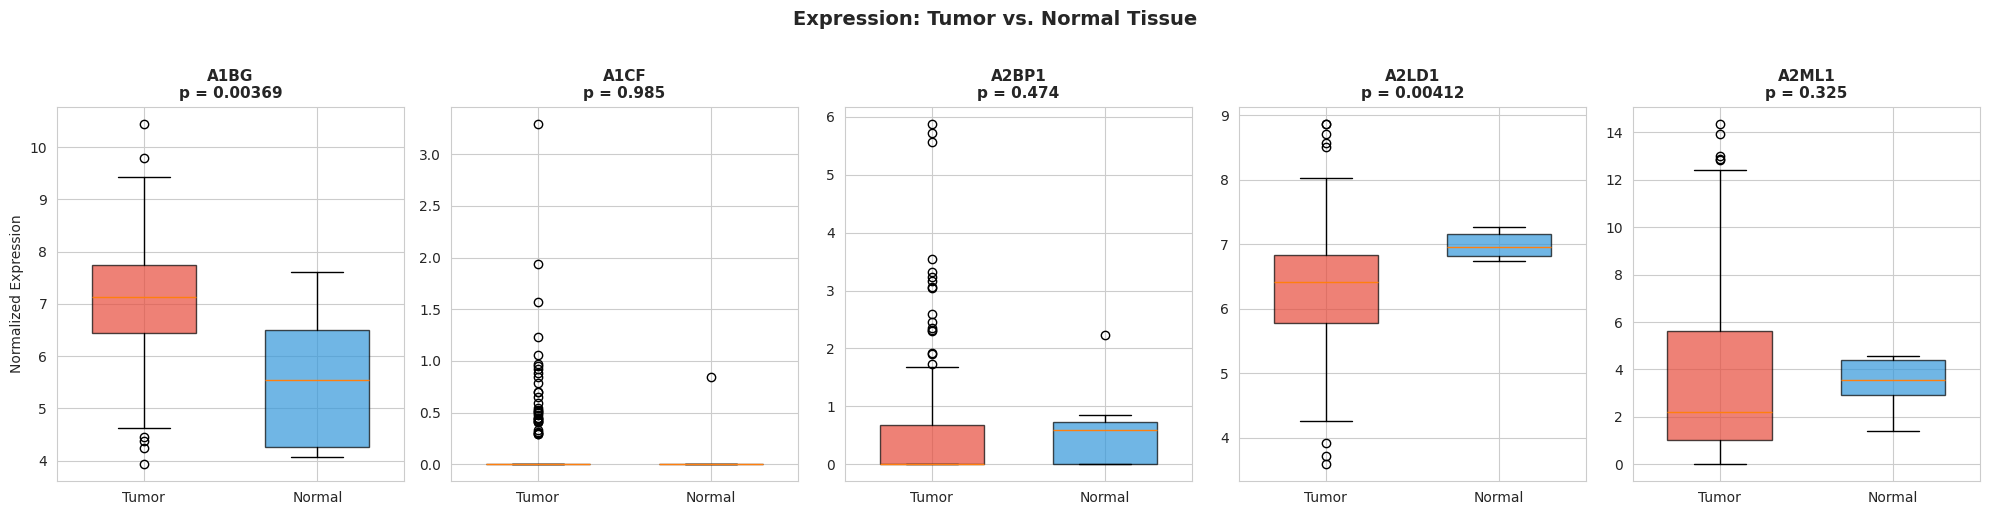


Compared 6 genes between 221 tumor and 7 normal samples.
⚠ Normal tissue sample size (n=7) is very small — interpret p-values with caution.


In [40]:
print("=" * 70)
print("NORMAL vs. TUMOR EXPRESSION")
print("=" * 70)

# Get normalized expression for normal samples
if len(normal) > 0:
    # Normalize normal samples using the same method
    normal_filtered = normal[meta_cols + gene_cols_filtered].copy()
    normal_norm, _, _ = upper_quartile_normalize(normal_filtered, gene_cols_filtered)
    
    # Key genes to compare
    compare_genes = [g for g in ['ERBB2', 'GRB7', 'ESR1', 'PGR', 'MKI67'] if g in gene_cols_filtered]
    
    if not compare_genes:
        # Use top variable genes instead
        compare_genes = gene_cols_filtered[:min(6, len(gene_cols_filtered))]
        print(f"Key HER2 genes not in abridged set. Using top genes: {compare_genes}")
    
    # Compare
    fig, axes = plt.subplots(1, min(len(compare_genes), 5), figsize=(4*min(len(compare_genes), 5), 5))
    if len(compare_genes) == 1:
        axes = [axes]
    
    for ax, gene in zip(axes, compare_genes[:5]):
        tumor_vals = tumor_norm[gene].dropna().values
        normal_vals = normal_norm[gene].dropna().values
        
        data_plot = [tumor_vals, normal_vals]
        bp = ax.boxplot(data_plot, labels=['Tumor', 'Normal'], patch_artist=True, widths=0.6)
        bp['boxes'][0].set_facecolor('#e74c3c')
        bp['boxes'][1].set_facecolor('#3498db')
        for box in bp['boxes']:
            box.set_alpha(0.7)
        
        # Statistical test
        if len(normal_vals) > 1:
            u_stat, p_mw = stats.mannwhitneyu(tumor_vals, normal_vals, alternative='two-sided')
            ax.set_title(f'{gene}\np = {p_mw:.3g}', fontsize=11, fontweight='bold')
        else:
            ax.set_title(gene, fontsize=11, fontweight='bold')
        
        ax.set_ylabel('Normalized Expression' if ax == axes[0] else '', fontsize=10)
    
    plt.suptitle('Expression: Tumor vs. Normal Tissue', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    print(f"\nCompared {len(compare_genes)} genes between {len(tumor_norm)} tumor and {len(normal_norm)} normal samples.")
    print("⚠ Normal tissue sample size (n=7) is very small — interpret p-values with caution.")
else:
    print("No Adjacent Normal samples available for comparison.")


## 5.2 HER2-Low Exploration

HER2-low (IHC 1+ or 2+/FISH-) is a clinically emerging category relevant for trastuzumab 
deruxtecan (T-DXd). We characterize RNA and CN profiles across the HER2 spectrum.


HER2-LOW EXPLORATION
HER2 Spectrum Distribution:
her2_level
HER2-Negative (unscored)    119
NaN                          52
HER2-Positive                32


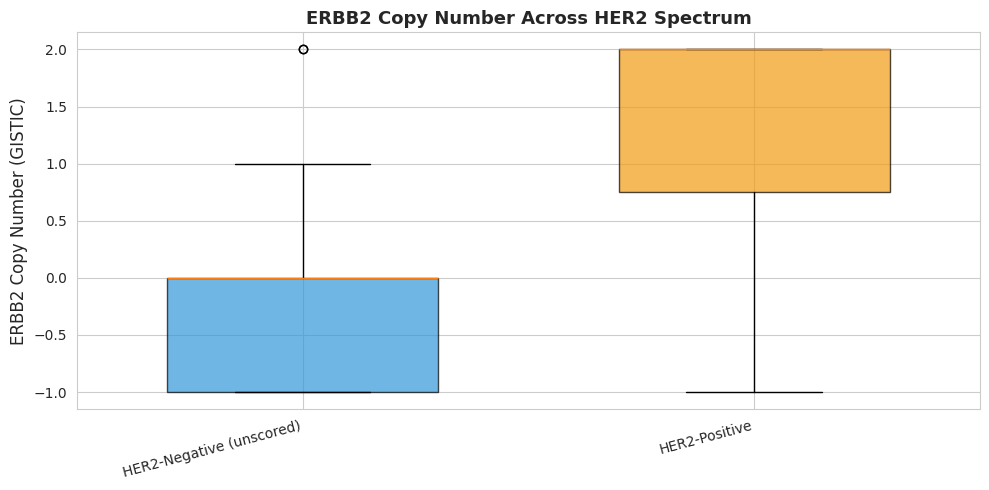

In [41]:
print("=" * 70)
print("HER2-LOW EXPLORATION")
print("=" * 70)

# Define HER2-low using IHC score
her2_spectrum = cohort_c.copy()

def classify_her2_spectrum(row):
    """Classify into HER2-0, HER2-low, HER2-positive spectrum."""
    ihc = str(row.get('HER2 ihc score', '')).strip()
    fish = str(row.get('HER2 fish status', '')).strip()
    composite = row.get('her2_composite', '')
    
    if ihc in ['nan', '', 'None']:
        ihc = None
    if fish in ['nan', '', 'None']:
        fish = None
    
    if composite == 'Positive':
        return 'HER2-Positive'
    
    if ihc is not None:
        if ihc in ['0']:
            return 'HER2-0'
        elif ihc in ['1+', '1']:
            return 'HER2-Low'
        elif ihc in ['2+', '2']:
            if fish is not None and 'negative' in fish.lower():
                return 'HER2-Low'  # IHC 2+/FISH- = HER2-Low
            elif composite == 'Equivocal':
                return 'HER2-Low (Equivocal)'
    
    if composite == 'Negative':
        return 'HER2-Negative (unscored)'
    
    return np.nan

her2_spectrum['her2_level'] = her2_spectrum.apply(classify_her2_spectrum, axis=1)

print("HER2 Spectrum Distribution:")
print(her2_spectrum['her2_level'].value_counts(dropna=False).to_string())

# Compare expression across spectrum
if 'ERBB2_expr' in analysis_df.columns or 'erbb2_copy_number' in her2_spectrum.columns:
    # Add ERBB2 expression
    if 'ERBB2' in tumor_norm_df.columns:
        erbb2_map = tumor_norm_df.set_index('pid')['ERBB2'].to_dict()
        her2_spectrum['ERBB2_expr'] = her2_spectrum['pid'].map(erbb2_map)
    
    # Plot CN distribution by HER2 level
    spectrum_labeled = her2_spectrum.dropna(subset=['her2_level'])
    
    if len(spectrum_labeled) > 0 and 'erbb2_copy_number' in spectrum_labeled.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        
        levels_order = ['HER2-0', 'HER2-Low', 'HER2-Low (Equivocal)', 
                        'HER2-Negative (unscored)', 'HER2-Positive']
        levels_present = [l for l in levels_order if l in spectrum_labeled['her2_level'].values]
        
        if levels_present:
            box_data_spec = [spectrum_labeled[spectrum_labeled['her2_level'] == l]['erbb2_copy_number'].dropna().values 
                           for l in levels_present]
            box_data_spec = [d for d in box_data_spec if len(d) > 0]
            levels_present = [l for l, d in zip(levels_present, 
                            [spectrum_labeled[spectrum_labeled['her2_level'] == l]['erbb2_copy_number'].dropna().values 
                             for l in levels_present]) if len(d) > 0]
            
            if box_data_spec:
                bp = ax.boxplot(box_data_spec, labels=levels_present, patch_artist=True, widths=0.6)
                colors_spec = ['#3498db', '#f39c12', '#e67e22', '#95a5a6', '#e74c3c']
                for patch, color in zip(bp['boxes'], colors_spec[:len(bp['boxes'])]):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.7)
                
                ax.set_ylabel('ERBB2 Copy Number (GISTIC)', fontsize=12)
                ax.set_title('ERBB2 Copy Number Across HER2 Spectrum', fontsize=13, fontweight='bold')
                ax.set_xticklabels(levels_present, rotation=15, ha='right')
                plt.tight_layout()
                plt.show()
        
        # Key question: Can RNA distinguish HER2-low from HER2-0?
        if 'ERBB2_expr' in her2_spectrum.columns:
            her2_0 = her2_spectrum[her2_spectrum['her2_level'] == 'HER2-0']['ERBB2_expr'].dropna()
            her2_low = her2_spectrum[her2_spectrum['her2_level'] == 'HER2-Low']['ERBB2_expr'].dropna()
            
            if len(her2_0) > 1 and len(her2_low) > 1:
                u_stat, p_val = stats.mannwhitneyu(her2_0, her2_low, alternative='two-sided')
                print(f"\nHER2-0 vs HER2-Low ERBB2 expression:")
                print(f"  HER2-0 median:  {her2_0.median():.3f} (n={len(her2_0)})")
                print(f"  HER2-Low median: {her2_low.median():.3f} (n={len(her2_low)})")
                print(f"  Mann-Whitney p = {p_val:.4g}")
                if p_val < 0.05:
                    print("  → RNA can significantly distinguish HER2-0 from HER2-Low.")
                    print("    This supports RNA as a supplementary assay for therapy eligibility.")
                else:
                    print("  → RNA cannot distinguish HER2-0 from HER2-Low at current sample size.")
else:
    print("Insufficient data for HER2 spectrum analysis in abridged dataset.")


## 5.3 Cluster-Specific Gene Expression

For each cluster identified in Section 3, we examine which genes are differentially expressed 
and whether cluster identity adds information beyond HER2 status alone.


CLUSTER-SPECIFIC GENE EXPRESSION



Differential expression analysis (each cluster vs. rest):
Using k = 4 clusters, 86 genes



  Cluster 0 (n=45):
    ↓ ABCD2          : log2FC = -1.649, p = 6.8e-11
    ↓ ABCC10         : log2FC = -0.630, p = 3.3e-10
    ↓ ABCC4          : log2FC = -1.347, p = 6.2e-10
    ↓ ABCA6          : log2FC = -1.674, p = 7.1e-09
    ↑ ABCA3          : log2FC = +0.958, p = 2.3e-08



  Cluster 1 (n=47):
    ↓ ABCC8          : log2FC = -5.477, p = 3.4e-38
    ↓ ABAT           : log2FC = -3.255, p = 3.3e-36
    ↑ A2ML1          : log2FC = +6.236, p = 1.7e-34
    ↓ ABCC11         : log2FC = -5.319, p = 4.6e-27
    ↑ ABCF1          : log2FC = +0.781, p = 6.3e-24



  Cluster 2 (n=77):
    ↑ ABCA9          : log2FC = +2.971, p = 1e-36
    ↑ ABCA8          : log2FC = +3.720, p = 5.7e-33
    ↑ ABCA10         : log2FC = +2.603, p = 8.2e-33
    ↑ ABCA6          : log2FC = +2.585, p = 1.8e-32
    ↑ ABCB1          : log2FC = +2.184, p = 9.2e-28



  Cluster 3 (n=52):
    ↑ ABCA12         : log2FC = +2.675, p = 2.1e-10
    ↓ AASS           : log2FC = -1.056, p = 2.7e-09
    ↑ ABCB9          : log2FC = +0.844, p = 4.2e-09
    ↓ ABCB7          : log2FC = -0.441, p = 1.6e-08
    ↑ ABCC12         : log2FC = +1.962, p = 3.5e-08


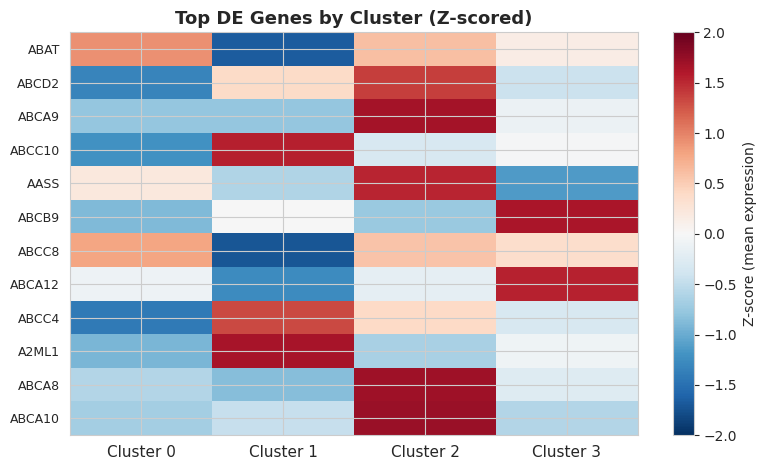

In [42]:
# Use the k=4 clustering from Section 3
print("=" * 70)
print("CLUSTER-SPECIFIC GENE EXPRESSION")
print("=" * 70)

km_final = KMeans(n_clusters=k_bio, random_state=42, n_init=20)
final_labels = km_final.fit_predict(X_for_clustering)

# For each cluster, identify top differentially expressed genes (vs rest)
print(f"\nDifferential expression analysis (each cluster vs. rest):")
print(f"Using k = {k_bio} clusters, {len(top_genes)} genes")

cluster_de_results = {}
for c in range(k_bio):
    in_cluster = final_labels == c
    out_cluster = ~in_cluster
    
    de_genes = []
    for gene in top_genes:
        in_vals = tumor_norm.loc[tumor_norm.index[in_cluster], gene].dropna()
        out_vals = tumor_norm.loc[tumor_norm.index[out_cluster], gene].dropna()
        
        if len(in_vals) > 2 and len(out_vals) > 2:
            t_stat, p_val = stats.ttest_ind(in_vals, out_vals)
            log2fc = in_vals.mean() - out_vals.mean()  # Already log-scale
            de_genes.append({'gene': gene, 't_stat': t_stat, 'p_value': p_val, 'log2fc': log2fc})
    
    de_df = pd.DataFrame(de_genes).sort_values('p_value')
    cluster_de_results[c] = de_df
    
    # Top 5 DE genes per cluster
    top5 = de_df.head(5)
    print(f"\n  Cluster {c} (n={in_cluster.sum()}):")
    for _, row in top5.iterrows():
        direction = '↑' if row['log2fc'] > 0 else '↓'
        print(f"    {direction} {row['gene']:15s}: log2FC = {row['log2fc']:+.3f}, p = {row['p_value']:.2g}")

# Heatmap of top DE genes across clusters
all_top_genes = set()
for c, de_df in cluster_de_results.items():
    all_top_genes.update(de_df.head(3)['gene'].tolist())

if len(all_top_genes) > 0:
    all_top_genes = list(all_top_genes)[:20]
    
    # Compute mean expression per cluster per gene
    heatmap_data = np.zeros((len(all_top_genes), k_bio))
    for j, c in enumerate(range(k_bio)):
        in_cluster = final_labels == c
        for i, gene in enumerate(all_top_genes):
            if gene in tumor_norm.columns:
                heatmap_data[i, j] = tumor_norm.loc[tumor_norm.index[in_cluster], gene].mean()
    
    # Z-score across clusters for visualization
    heatmap_z = (heatmap_data - heatmap_data.mean(axis=1, keepdims=True)) / (heatmap_data.std(axis=1, keepdims=True) + 1e-8)
    
    fig, ax = plt.subplots(figsize=(8, max(4, len(all_top_genes) * 0.4)))
    im = ax.imshow(heatmap_z, aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
    ax.set_xticks(range(k_bio))
    ax.set_xticklabels([f'Cluster {i}' for i in range(k_bio)], fontsize=11)
    ax.set_yticks(range(len(all_top_genes)))
    ax.set_yticklabels(all_top_genes, fontsize=9)
    plt.colorbar(im, label='Z-score (mean expression)', ax=ax)
    ax.set_title('Top DE Genes by Cluster (Z-scored)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


---
# Summary and Conclusions

## Key Findings

### 1. QC and Normalization
- Clinical data harmonized; HER2 composite label constructed following ASCO/CAP guidelines 
  with internal consistency checks.
- RNA-Seq normalized using upper-quartile + log2(x+1), verified by PCA vs. library size 
  decorrelation and per-sample distribution alignment.
- Temporal guideline drift noted in HER2 labeling — strengthens the case for molecular classifiers.

### 2. HER2 Identification
- **Clinical definition:** ASCO/CAP-based composite label from IHC score and FISH status.
- **Multimodal definition:** ERBB2 RNA expression and copy number show expected concordance 
  with clinical HER2 status, with discordant cases identified.
- **RNA vs DNA:** Logistic regression comparison shows which modality (or combination) best 
  predicts the clinical IHC label.

### 3. Unsupervised Clustering
- Patient subsets identified via k-means on top PCs with silhouette-guided k selection.
- Clusters show differential enrichment for HER2+ patients (Fisher's exact test).
- Cluster structure visible in UMAP, correlating with both HER2 and ER status.

### 4. Machine Learning
- XGBoost, Random Forest, and L1-Logistic Regression compared via stratified 5-fold CV.
- SHAP analysis reveals top predictive features and their biological context.
- Features beyond ERBB2 alone suggest biomarker panel candidates.

### 5. Deep Dive
- Normal vs. tumor expression compared for key genes (limited by n=7 normals).
- HER2-low spectrum characterized — relevant for T-DXd eligibility.
- Cluster-specific DE genes identified.

## Limitations and Caveats
- **Abridged dataset:** Analysis performed on ~88 genes; full ~20K-gene dataset will 
  yield richer clustering, pathway analysis, and feature importance.
- **Sample size:** ~150 labeled patients with 3.7:1 class imbalance limits model complexity.
- **Adjacent normal n=7:** Too small for robust tumor-normal comparisons.
- **Temporal bias:** HER2-Positive labels concentrated in 2006-2009 may bias the classifier.

## AI Validation Process
- Claude (Anthropic) used as coding co-scientist in assistant mode.
- AI accelerated: boilerplate code, normalization implementation, model setup, plot generation.
- Human (PI) drove: biological hypothesis framing, QC plan design, interpretation of feature 
  importance, analytical decision-making (normalization choice, equivocal case handling, 
  ASCO/CAP label construction).
- All AI-generated code reviewed and validated before inclusion. Key validations:
  - Normalization method justified against RSEM data characteristics (not raw counts).
  - HER2 label construction cross-checked against pre-coded IHC-HER2 field.
  - Feature importance cross-referenced against known HER2 pathway biology.

## Tempus-Relevant Insights
- **Molecular HER2 classification** is more stable across time and institutions than IHC/FISH, 
  which is subject to guideline drift and inter-observer variability.
- **RNA expression** can supplement or replace current clinical assays, especially for 
  HER2-low identification (T-DXd eligibility).
- **Multimodal integration** (RNA + CN + clinical) outperforms any single data type alone.
